# Data Mining for Customer Complaint Analysis

**Objectives**: EDA, Text Analysis, Clustering, Reporting  
**Expected Outcomes**: Identify frequent complaint types, urgency/resolution patterns, actionable recommendations


In [1]:
# PHASE 1: Setup and Data Loading


In [2]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing and clustering
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation, NMF
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.metrics import silhouette_score
from scipy.sparse import hstack

# Optional: Advanced clustering and embeddings
try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    HAS_HDBSCAN = False
    print("HDBSCAN not available. Install with: pip install hdbscan")

try:
    from sentence_transformers import SentenceTransformer
    import umap
    HAS_EMBEDDINGS = True
except ImportError:
    HAS_EMBEDDINGS = False
    print("Sentence transformers/UMAP not available. Install with: pip install sentence-transformers umap-learn")

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("WordCloud not available. Install with: pip install wordcloud")

# NLTK for stopwords
try:
    import nltk
    from nltk.corpus import stopwords
    nltk.download("stopwords", quiet=True)
    french_stop_words = stopwords.words("french")
except Exception:
    # Fallback French stopwords
    french_stop_words = [
        "a", "au", "aux", "avec", "ce", "ces", "dans", "de", "des", "du", "elle", "en",
        "et", "eux", "il", "je", "la", "le", "les", "leur", "lui", "ma", "mais", "me",
        "meme", "mes", "moi", "mon", "ne", "nos", "notre", "nous", "on", "ou", "par",
        "pas", "pour", "qu", "que", "qui", "sa", "se", "ses", "son", "sur", "ta", "te",
        "tes", "toi", "ton", "tu", "un", "une", "vos", "votre", "vous", "y", "à", "ça",
        "c", "d", "j", "l", "m", "n", "s", "t"
    ]

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 100)

# Visualization style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("✓ All libraries imported successfully")
print(f"✓ HDBSCAN available: {HAS_HDBSCAN}")
print(f"✓ Embeddings available: {HAS_EMBEDDINGS}")
print(f"✓ WordCloud available: {HAS_WORDCLOUD}")


WordCloud not available. Install with: pip install wordcloud
✓ All libraries imported successfully
✓ HDBSCAN available: True
✓ Embeddings available: True
✓ WordCloud available: False


In [3]:
# Load the dataset
df = pd.read_csv("algerietelecom.csv")

print("=" * 80)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 80)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
df.head(10)


DATASET LOADED SUCCESSFULLY
Dataset shape: (100000, 10)
Columns: ['id', 'date', 'wilaya', 'canal', 'texte_reclamation', 'categorie', 'sentiment', 'urgence', 'status', 'suggested_action']

First few rows:


,id,date,wilaya,canal,texte_reclamation,categorie,sentiment,urgence,status,suggested_action
0,105001,2024-07-31,Tizi Ouzou,Centre d'appel,Incident: modem ne se synchronise pas.,Coupure de ligne,Négatif,Moyenne,Résolu,Redémarrage du modem
1,105002,2024-10-29,Boumerdès,Application mobile,"Client signale problème lors de la résiliation, facturation continue.",Résiliation,Négatif,Moyenne,En cours,Vérifier décodeur
2,105003,2024-03-22,Msila,Site web,Demande d'assistance: bruit important sur la ligne téléphonique.,Coupure de ligne,Négatif,Basse,Résolu,Envoi technicien
3,105004,2024-04-15,Saïda,Centre d'appel,"Incident: problème lors de la résiliation, facturation continue.",Coupure de ligne,Négatif,Moyenne,Nouveau,Vérifier décodeur
4,105005,2025-09-04,Boumerdès,Site web,Incident: installation non réalisée dans les délais.,Coupure de ligne,Négatif,Basse,Clôturé,Vérifier décodeur
5,105006,2024-09-06,Tiaret,Agence commerciale,Demande d'assistance: image figée sur certaines chaines.,Installation,Neutre,Moyenne,Résolu,Planifier rendez-vous
6,105007,2024-07-30,Constantine,Centre d'appel,"Demande d'assistance: montant facturé incorrectement, demande régularisation.",Facturation,Négatif,Moyenne,En cours,Planifier rendez-vous
7,105008,2024-03-26,Médéa,Site web,"Réclamation: montant facturé incorrectement, demande régularisation.",Coupure de ligne,Négatif,Moyenne,Résolu,Envoi technicien
8,105009,2025-02-28,Blida,Centre d'appel,Client signale demande d'information sur l'offre et le contrat.,Internet lent,Neutre,élevée,Résolu,Ouverture dossier
9,105010,2024-11-07,Alger,Centre d'appel,Réclamation: erreur d'authentification lors de la connexion.,Résiliation,Négatif,Moyenne,Résolu,Envoi technicien


In [4]:
# Dataset information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("DATA QUALITY CHECKS")
print("=" * 80)

# Check for missing values
print("\n1. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    print(missing[missing > 0])

# Check cardinality
print("\n2. Cardinality (Unique Values per Column):")
cardinality = df.nunique().sort_values(ascending=False)
cardinality_df = pd.DataFrame({
    "Column": cardinality.index,
    "Unique_Values": cardinality.values,
    "Uniqueness_Ratio": (cardinality.values / len(df) * 100).round(2)
})
print(cardinality_df.to_string(index=False))

# Check text repetition
print("\n3. Text Repetition Analysis:")
unique_texts = df["texte_reclamation"].nunique()
total_rows = len(df)
repetition_ratio = total_rows / unique_texts
print(f"   Unique complaint texts: {unique_texts:,}")
print(f"   Total rows: {total_rows:,}")
print(f"   Repetition ratio: {repetition_ratio:.1f}x")
if repetition_ratio > 100:
    print("   ⚠ High text repetition detected (synthetic/template-based data)")

# Basic statistics
print("\n4. Basic Statistics:")
print(f"   Date range: {df['date'].min()} to {df['date'].max()}")
print(f"   Categories: {df['categorie'].nunique()}")
print(f"   Regions: {df['wilaya'].nunique()}")
print(f"   Channels: {df['canal'].nunique()}")


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   id                 100000 non-null  int64 
 1   date               100000 non-null  object
 2   wilaya             100000 non-null  object
 3   canal              100000 non-null  object
 4   texte_reclamation  100000 non-null  object
 5   categorie          100000 non-null  object
 6   sentiment          100000 non-null  object
 7   urgence            100000 non-null  object
 8   status             100000 non-null  object
 9   suggested_action   100000 non-null  object
dtypes: int64(1), object(9)
memory usage: 7.6+ MB

DATA QUALITY CHECKS

1. Missing Values:
✓ No missing values found

2. Cardinality (Unique Values per Column):
           Column  Unique_Values  Uniqueness_Ratio
               id         100000            100.00
             date            65

In [5]:
# PHASE 2: Data Preparation


In [6]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Ensure categorical columns are strings
categorical_cols = ["wilaya", "canal", "categorie", "sentiment", "urgence", "status", "suggested_action"]
df[categorical_cols] = df[categorical_cols].astype(str)

# Create time-based features
df["month"] = df["date"].dt.to_period("M")
df["day_of_week"] = df["date"].dt.day_name()
df["hour"] = df["date"].dt.hour
df["month_name"] = df["date"].dt.month_name()

print("✓ Data types converted")
print(f"✓ Date range: {df['date'].min()} to {df['date'].max()}")
print(f"✓ Created time-based features: month, day_of_week, hour, month_name")


✓ Data types converted
✓ Date range: 2024-01-01 00:00:00 to 2025-10-20 00:00:00
✓ Created time-based features: month, day_of_week, hour, month_name


In [7]:
import re

def basic_text_cleaning(text: str) -> str:
    """Clean and normalize text for analysis."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)  # Remove punctuation
    text = re.sub(r"\s+", " ", text).strip()  # Normalize whitespace
    return text

# Apply text cleaning
df["clean_text"] = df["texte_reclamation"].apply(basic_text_cleaning)

# Verify cleaning
print("✓ Text cleaning completed")
print(f"✓ Original text sample: {df['texte_reclamation'].iloc[0][:100]}...")
print(f"✓ Cleaned text sample: {df['clean_text'].iloc[0][:100]}...")
print(f"✓ Empty texts after cleaning: {df['clean_text'].str.len().eq(0).sum()}")


✓ Text cleaning completed
✓ Original text sample: Incident: modem ne se synchronise pas....
✓ Cleaned text sample: incident modem ne se synchronise pas...
✓ Empty texts after cleaning: 0


In [8]:
# PHASE 3: Exploratory Data Analysis (EDA)


In [9]:
# Create comprehensive summary tables for all dimensions
print("=" * 80)
print("CONSOLIDATED EDA SUMMARY TABLES")
print("=" * 80)

def create_summary_table(series, name):
    """Create a formatted summary table."""
    counts = series.value_counts().sort_values(ascending=False)
    return pd.DataFrame({
        name: counts.index,
        "Count": counts.values,
        "Percentage": (counts.values / len(df) * 100).round(2)
    })

# 1. Complaints by Category
print("\n1. COMPLAINT COUNTS BY CATEGORY:")
print("-" * 60)
category_table = create_summary_table(df["categorie"], "Category")
print(category_table.to_string(index=False))

# 2. Complaints by Channel
print("\n\n2. COMPLAINT COUNTS BY CHANNEL:")
print("-" * 60)
channel_table = create_summary_table(df["canal"], "Channel")
print(channel_table.to_string(index=False))

# 3. Complaints by Region (Top 15)
print("\n\n3. COMPLAINT COUNTS BY REGION (Top 15):")
print("-" * 60)
region_table = create_summary_table(df["wilaya"], "Region").head(15)
print(region_table.to_string(index=False))

# 4. Complaints by Urgency
print("\n\n4. COMPLAINT COUNTS BY URGENCY LEVEL:")
print("-" * 60)
urgency_order = ["Critique", "élevée", "Moyenne", "Basse"]
urgency_counts = df["urgence"].value_counts().reindex(urgency_order).fillna(0)
urgency_table = pd.DataFrame({
    "Urgency": urgency_counts.index,
    "Count": urgency_counts.values.astype(int),
    "Percentage": (urgency_counts.values / len(df) * 100).round(2)
})
print(urgency_table.to_string(index=False))

# 5. Complaints by Status
print("\n\n5. COMPLAINT COUNTS BY STATUS:")
print("-" * 60)
status_table = create_summary_table(df["status"], "Status")
print(status_table.to_string(index=False))

# 6. Complaints by Sentiment
print("\n\n6. COMPLAINT COUNTS BY SENTIMENT:")
print("-" * 60)
sentiment_table = create_summary_table(df["sentiment"], "Sentiment")
print(sentiment_table.to_string(index=False))


CONSOLIDATED EDA SUMMARY TABLES

1. COMPLAINT COUNTS BY CATEGORY:
------------------------------------------------------------
         Category  Count  Percentage
 Coupure de ligne  22375       22.38
    Internet lent  20034       20.03
      Facturation  11891       11.89
       Télévision  10021       10.02
     Installation   9871        9.87
       Assistance   7908        7.91
      Résiliation   6101        6.10
Problème matériel   5879        5.88
    Configuration   3954        3.95
            Autre   1966        1.97


2. COMPLAINT COUNTS BY CHANNEL:
------------------------------------------------------------
           Channel  Count  Percentage
    Centre d'appel  39649       39.65
          Site web  20085       20.08
Agence commerciale  15206       15.21
Application mobile  15025       15.02
             Email  10035       10.04


3. COMPLAINT COUNTS BY REGION (Top 15):
------------------------------------------------------------
    Region  Count  Percentage
     Jijel

# Basic complaint statistics and KPIs
print("=" * 80)
print("BASIC COMPLAINT STATISTICS")
print("=" * 80)

total_complaints = len(df)
print(f"Total complaints: {total_complaints:,}")
print(f"Time period: {df['date'].min()} to {df['date'].max()}")

# Calculate key metrics
resolution_rate = (df["status"].astype(str).str.strip().str.lower() == "résolu").mean() * 100
critical_rate = (df["urgence"].astype(str) == "Critique").mean() * 100
negative_sentiment_rate = (df["sentiment"].astype(str).str.strip().str.lower() == "négatif").mean() * 100

monthly_complaints = df.groupby("month").size()
avg_monthly = monthly_complaints.mean()

print(f"\nKey Metrics:")
print(f"  • Average complaints per month: {avg_monthly:.0f}")
print(f"  • Overall resolution rate: {resolution_rate:.1f}%")
print(f"  • Critical urgency rate: {critical_rate:.1f}%")
print(f"  • Negative sentiment rate: {negative_sentiment_rate:.1f}%")
print(f"  • Unique categories: {df['categorie'].nunique()}")
print(f"  • Unique regions: {df['wilaya'].nunique()}")
print(f"  • Unique channels: {df['canal'].nunique()}")


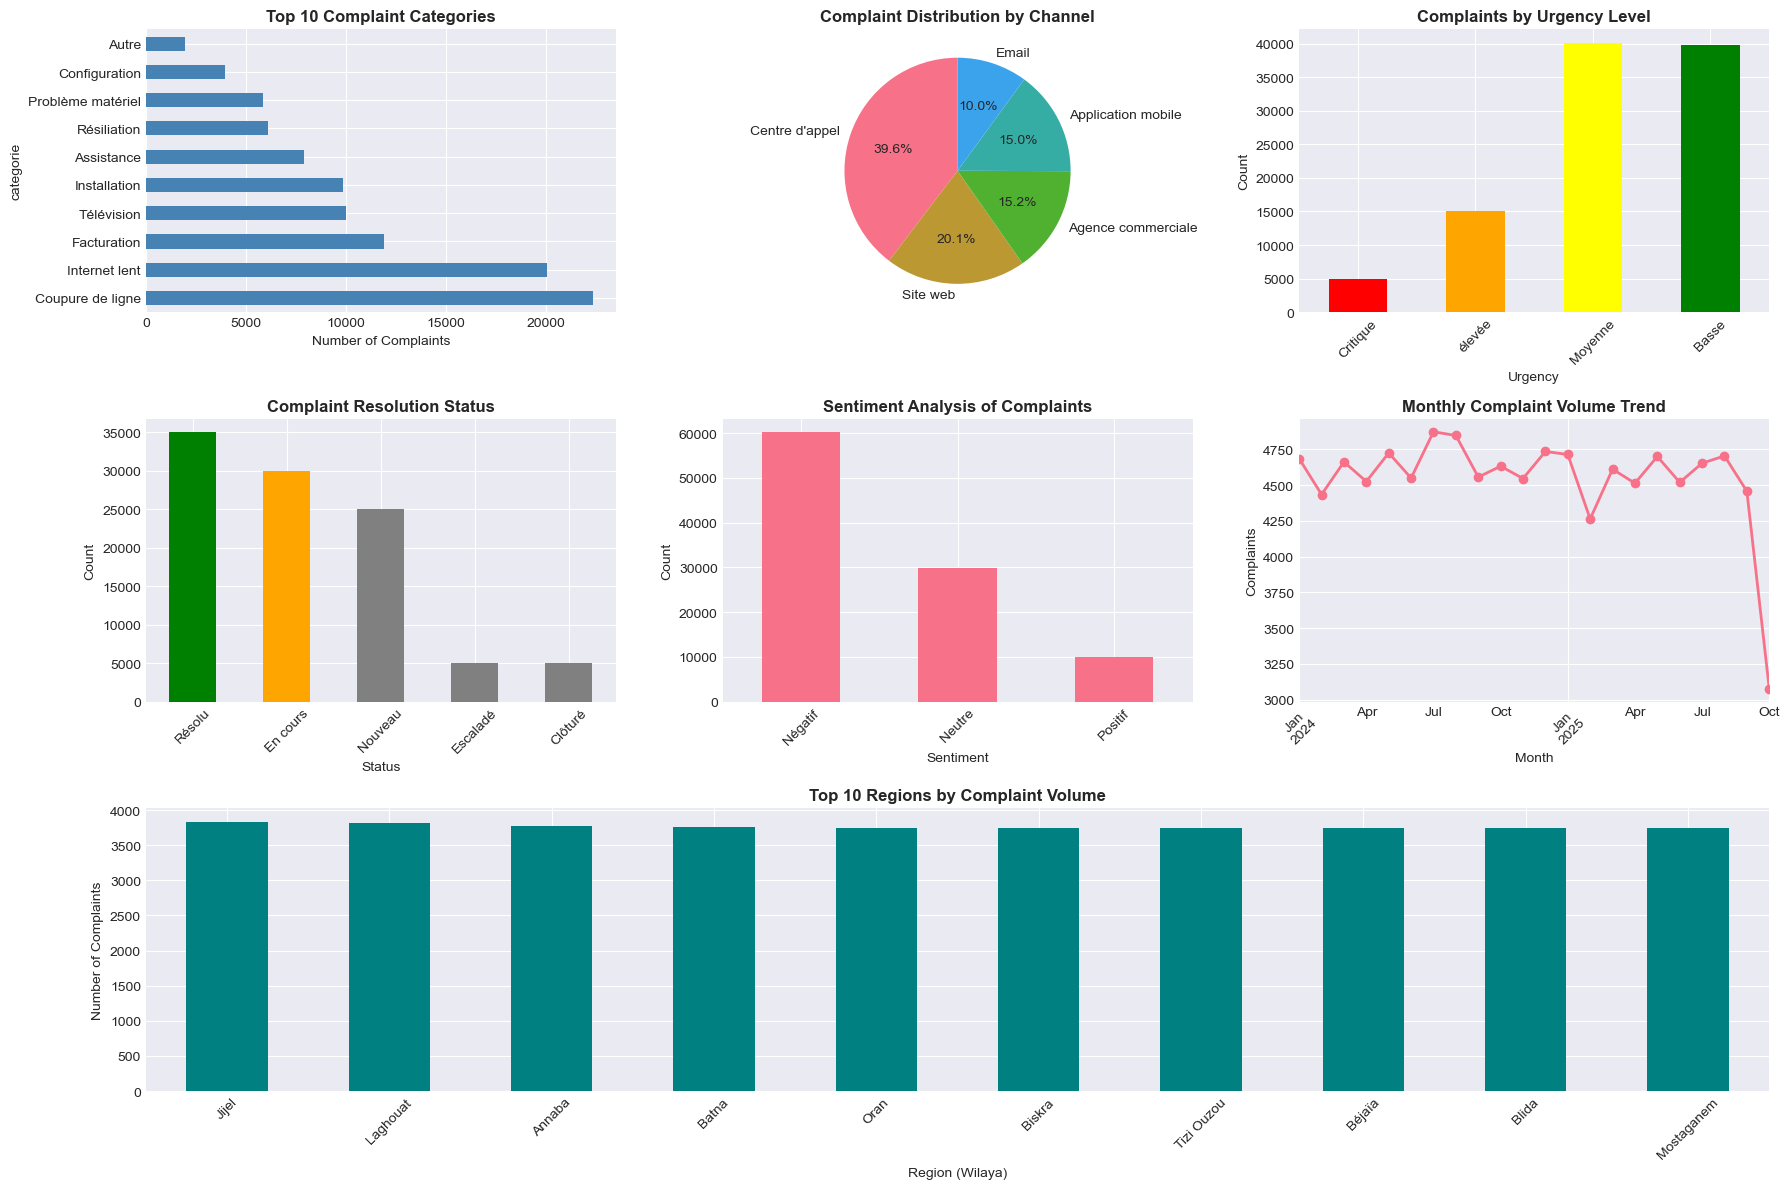

✓ Visualization dashboard created


In [10]:
# Comprehensive visualization dashboard
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 3, figure=fig)

# 1. Complaints by Category (Top 10)
ax1 = fig.add_subplot(gs[0, 0])
category_counts = df["categorie"].value_counts().head(10)
category_counts.plot(kind="barh", ax=ax1, color="steelblue")
ax1.set_title("Top 10 Complaint Categories", fontweight="bold", fontsize=12)
ax1.set_xlabel("Number of Complaints")

# 2. Complaints by Channel
ax2 = fig.add_subplot(gs[0, 1])
channel_counts = df["canal"].value_counts()
channel_counts.plot(kind="pie", ax=ax2, autopct="%1.1f%%", startangle=90)
ax2.set_title("Complaint Distribution by Channel", fontweight="bold", fontsize=12)
ax2.set_ylabel("")

# 3. Complaints by Urgency Level
ax3 = fig.add_subplot(gs[0, 2])
urgency_order = ["Critique", "élevée", "Moyenne", "Basse"]
urgency_counts = df["urgence"].value_counts().reindex(urgency_order).fillna(0)
urgency_counts.plot(kind="bar", ax=ax3, color=["red", "orange", "yellow", "green"])
ax3.set_title("Complaints by Urgency Level", fontweight="bold", fontsize=12)
ax3.set_xlabel("Urgency")
ax3.set_ylabel("Count")
ax3.tick_params(axis="x", rotation=45)

# 4. Resolution Status
ax4 = fig.add_subplot(gs[1, 0])
status_counts = df["status"].value_counts()
colors = ["green" if str(s).strip() == "Résolu" else "orange" if str(s).strip() == "En cours" else "gray"
          for s in status_counts.index]
status_counts.plot(kind="bar", ax=ax4, color=colors)
ax4.set_title("Complaint Resolution Status", fontweight="bold", fontsize=12)
ax4.set_xlabel("Status")
ax4.set_ylabel("Count")
ax4.tick_params(axis="x", rotation=45)

# 5. Sentiment Distribution
ax5 = fig.add_subplot(gs[1, 1])
sentiment_counts = df["sentiment"].value_counts()
sentiment_counts.plot(kind="bar", ax=ax5)
ax5.set_title("Sentiment Analysis of Complaints", fontweight="bold", fontsize=12)
ax5.set_xlabel("Sentiment")
ax5.set_ylabel("Count")
ax5.tick_params(axis="x", rotation=45)

# 6. Monthly Complaint Trends
ax6 = fig.add_subplot(gs[1, 2])
monthly_trend = df.groupby("month").size()
monthly_trend.plot(ax=ax6, marker="o", linewidth=2)
ax6.set_title("Monthly Complaint Volume Trend", fontweight="bold", fontsize=12)
ax6.set_xlabel("Month")
ax6.set_ylabel("Complaints")
ax6.tick_params(axis="x", rotation=45)

# 7. Top 10 Regions by Complaint Volume
ax7 = fig.add_subplot(gs[2, :])
region_counts = df["wilaya"].value_counts().head(10)
region_counts.plot(kind="bar", ax=ax7, color="teal")
ax7.set_title("Top 10 Regions by Complaint Volume", fontweight="bold", fontsize=12)
ax7.set_xlabel("Region (Wilaya)")
ax7.set_ylabel("Number of Complaints")
ax7.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
print("✓ Visualization dashboard created")


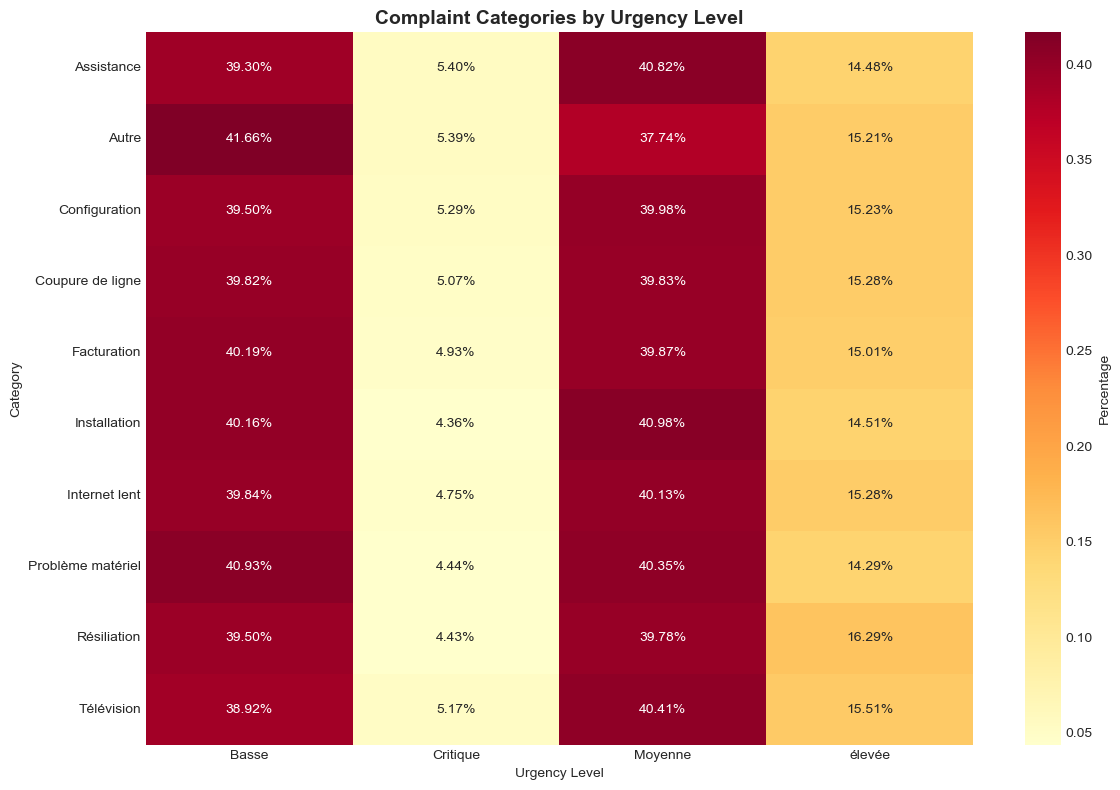


RESOLUTION RATE BY SUBMISSION CHANNEL
status              Clôturé  En cours  Escaladé  Nouveau  Résolu
canal                                                           
Agence commerciale      4.8      29.6       5.2     24.6    35.7
Application mobile      5.2      30.1       4.7     24.7    35.3
Centre d'appel          4.8      29.9       5.2     25.2    34.9
Email                   5.0      30.1       5.3     25.6    34.1
Site web                5.1      30.3       4.9     24.9    34.9


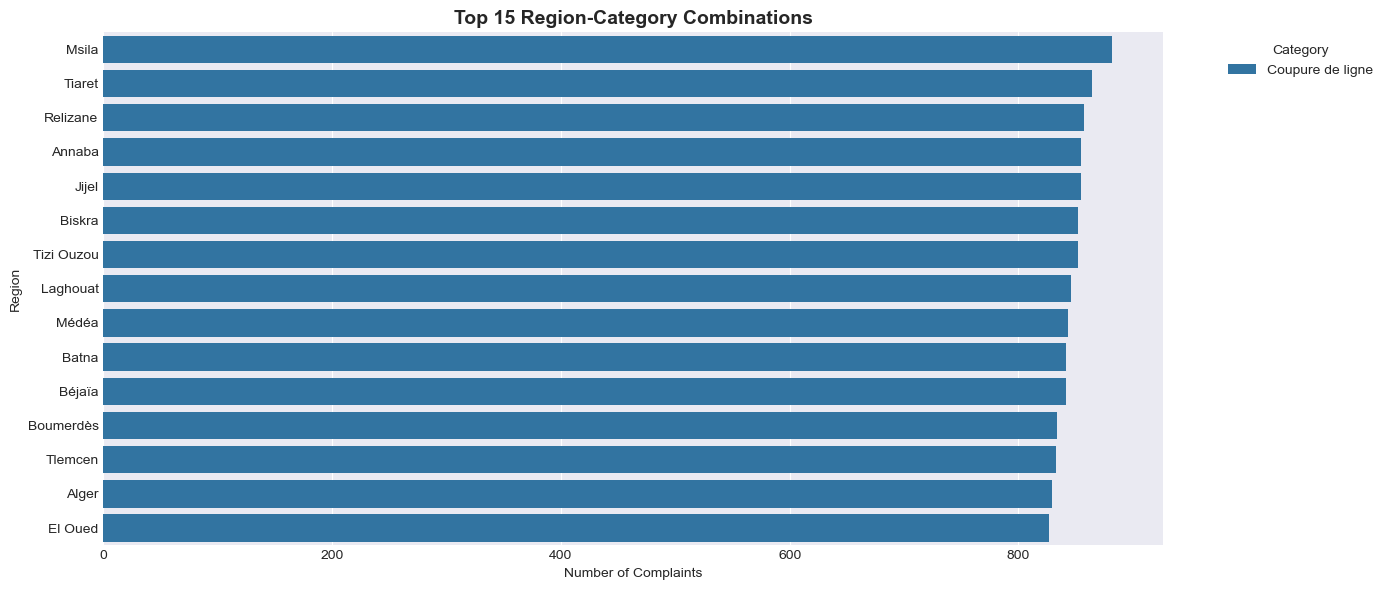

✓ Cross-dimensional analysis completed


In [11]:
# Cross-dimensional analysis with heatmaps

# 1. Category × Urgency Heatmap
category_urgency = pd.crosstab(df["categorie"], df["urgence"], normalize="index")
plt.figure(figsize=(12, 8))
sns.heatmap(category_urgency, annot=True, fmt=".2%", cmap="YlOrRd", cbar_kws={"label": "Percentage"})
plt.title("Complaint Categories by Urgency Level", fontsize=14, fontweight="bold")
plt.xlabel("Urgency Level")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# 2. Channel × Status Analysis
channel_status = pd.crosstab(df["canal"], df["status"], normalize="index") * 100
print("\n" + "=" * 60)
print("RESOLUTION RATE BY SUBMISSION CHANNEL")
print("=" * 60)
print(channel_status.round(1).to_string())

# 3. Region × Category Analysis (Top combinations)
region_category = df.groupby(["wilaya", "categorie"]).size().reset_index(name="count")
top_combinations = region_category.nlargest(15, "count")

plt.figure(figsize=(14, 6))
sns.barplot(data=top_combinations, x="count", y="wilaya", hue="categorie", palette="tab20")
plt.title("Top 15 Region-Category Combinations", fontsize=14, fontweight="bold")
plt.xlabel("Number of Complaints")
plt.ylabel("Region")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("✓ Cross-dimensional analysis completed")


## Notebook Structure Overview

This notebook follows a sequential, well-structured approach:

1. **PHASE 1: Setup and Data Loading** ✓
   - Import libraries
   - Load dataset
   - Data quality checks

2. **PHASE 2: Data Preparation** ✓
   - Data type conversion
   - Text cleaning
   - Feature engineering

3. **PHASE 3: Exploratory Data Analysis (EDA)**
   - Summary tables
   - Basic statistics
   - Visualizations
   - Cross-dimensional analysis

4. **PHASE 4: Text Analysis**
   - Keyword extraction
   - Phrase analysis
   - Text by category/sentiment

5. **PHASE 5: Feature Engineering for Clustering**
   - TF-IDF vectorization
   - Metadata encoding
   - Dimensionality reduction

6. **PHASE 6: Clustering Analysis**
   - Multiple clustering algorithms
   - Cluster evaluation
   - Cluster interpretation

7. **PHASE 7: Multi-Dimensional Grouping**
   - Complex grouping patterns
   - Priority matrices

8. **PHASE 8: Reporting & Recommendations**
   - Executive summary
   - Actionable insights
   - CSV exports

---


- Cross-dimensional analysis (category × urgency, channel × status, region × category)

In [12]:
# === MISSING FEATURE 1: Consolidated EDA Summary Tables ===
# Simple count tables showing complaint counts by all dimensions

print("=" * 80)
print("CONSOLIDATED EDA SUMMARY TABLES")
print("=" * 80)

# 1. Complaints by Category
print("\n1. COMPLAINT COUNTS BY CATEGORY:")
print("-" * 60)
if "categorie" in df.columns:
    category_counts = df["categorie"].value_counts().sort_values(ascending=False)
    category_table = pd.DataFrame({
        "Category": category_counts.index,
        "Count": category_counts.values,
        "Percentage": (category_counts.values / len(df) * 100).round(2)
    })
    print(category_table.to_string(index=False))
else:
    print("Column 'categorie' not found")

# 2. Complaints by Channel
print("\n\n2. COMPLAINT COUNTS BY CHANNEL:")
print("-" * 60)
if "canal" in df.columns:
    channel_counts = df["canal"].value_counts().sort_values(ascending=False)
    channel_table = pd.DataFrame({
        "Channel": channel_counts.index,
        "Count": channel_counts.values,
        "Percentage": (channel_counts.values / len(df) * 100).round(2)
    })
    print(channel_table.to_string(index=False))
else:
    print("Column 'canal' not found")

# 3. Complaints by Region
print("\n\n3. COMPLAINT COUNTS BY REGION (Top 15):")
print("-" * 60)
if "wilaya" in df.columns:
    region_counts = df["wilaya"].value_counts().sort_values(ascending=False).head(15)
    region_table = pd.DataFrame({
        "Region": region_counts.index,
        "Count": region_counts.values,
        "Percentage": (region_counts.values / len(df) * 100).round(2)
    })
    print(region_table.to_string(index=False))
else:
    print("Column 'wilaya' not found")

# 4. Complaints by Urgency
print("\n\n4. COMPLAINT COUNTS BY URGENCY LEVEL:")
print("-" * 60)
if "urgence" in df.columns:
    urgency_order = ["Critique", "élevée", "Moyenne", "Basse"]
    urgency_counts = df["urgence"].value_counts().reindex(urgency_order).fillna(0)
    urgency_table = pd.DataFrame({
        "Urgency": urgency_counts.index,
        "Count": urgency_counts.values.astype(int),
        "Percentage": (urgency_counts.values / len(df) * 100).round(2)
    })
    print(urgency_table.to_string(index=False))
else:
    print("Column 'urgence' not found")

# 5. Complaints by Status
print("\n\n5. COMPLAINT COUNTS BY STATUS:")
print("-" * 60)
if "status" in df.columns:
    status_counts = df["status"].value_counts().sort_values(ascending=False)
    status_table = pd.DataFrame({
        "Status": status_counts.index,
        "Count": status_counts.values,
        "Percentage": (status_counts.values / len(df) * 100).round(2)
    })
    print(status_table.to_string(index=False))
else:
    print("Column 'status' not found")

# 6. Complaints by Sentiment
print("\n\n6. COMPLAINT COUNTS BY SENTIMENT:")
print("-" * 60)
if "sentiment" in df.columns:
    sentiment_counts = df["sentiment"].value_counts().sort_values(ascending=False)
    sentiment_table = pd.DataFrame({
        "Sentiment": sentiment_counts.index,
        "Count": sentiment_counts.values,
        "Percentage": (sentiment_counts.values / len(df) * 100).round(2)
    })
    print(sentiment_table.to_string(index=False))
else:
    print("Column 'sentiment' not found")


CONSOLIDATED EDA SUMMARY TABLES

1. COMPLAINT COUNTS BY CATEGORY:
------------------------------------------------------------
         Category  Count  Percentage
 Coupure de ligne  22375       22.38
    Internet lent  20034       20.03
      Facturation  11891       11.89
       Télévision  10021       10.02
     Installation   9871        9.87
       Assistance   7908        7.91
      Résiliation   6101        6.10
Problème matériel   5879        5.88
    Configuration   3954        3.95
            Autre   1966        1.97


2. COMPLAINT COUNTS BY CHANNEL:
------------------------------------------------------------
           Channel  Count  Percentage
    Centre d'appel  39649       39.65
          Site web  20085       20.08
Agence commerciale  15206       15.21
Application mobile  15025       15.02
             Email  10035       10.04


3. COMPLAINT COUNTS BY REGION (Top 15):
------------------------------------------------------------
    Region  Count  Percentage
     Jijel

In [13]:
# === A1: Basic Complaint Statistics ===
import pandas as pd
import numpy as np

print("=" * 50)
print("BASIC COMPLAINT STATISTICS")
print("=" * 50)

print(f"Total complaints: {len(df):,}")

# Ensure date is datetime (Phase A is before Phase 2, so be defensive)
if "date" in df.columns:
    if not np.issubdtype(df["date"].dtype, np.datetime64):
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    print(f"Time period: {df['date'].min()} to {df['date'].max()}")
else:
    print("Time period: (no 'date' column found)")

for col, label in [("categorie", "categories"), ("wilaya", "regions"), ("canal", "channels")]:
    if col in df.columns:
        print(f"Unique {label}: {df[col].nunique()}")
    else:
        print(f"Unique {label}: (no '{col}' column found)")

# Complaint volume over time
if "date" in df.columns:
    df["month"] = df["date"].dt.to_period("M")
    monthly_complaints = df.groupby("month").size()
    print(f"Average complaints per month: {monthly_complaints.mean():.0f}")
else:
    monthly_complaints = None

# Resolution statistics
if "status" in df.columns:
    resolution_rate = (df["status"].astype(str).str.strip().str.lower() == "résolu").mean() * 100
    print(f"Overall resolution rate: {resolution_rate:.1f}%")
else:
    print("Overall resolution rate: (no 'status' column found)")

BASIC COMPLAINT STATISTICS
Total complaints: 100,000
Time period: 2024-01-01 00:00:00 to 2025-10-20 00:00:00
Unique categories: 10
Unique regions: 27
Unique channels: 5
Average complaints per month: 4545
Overall resolution rate: 35.0%


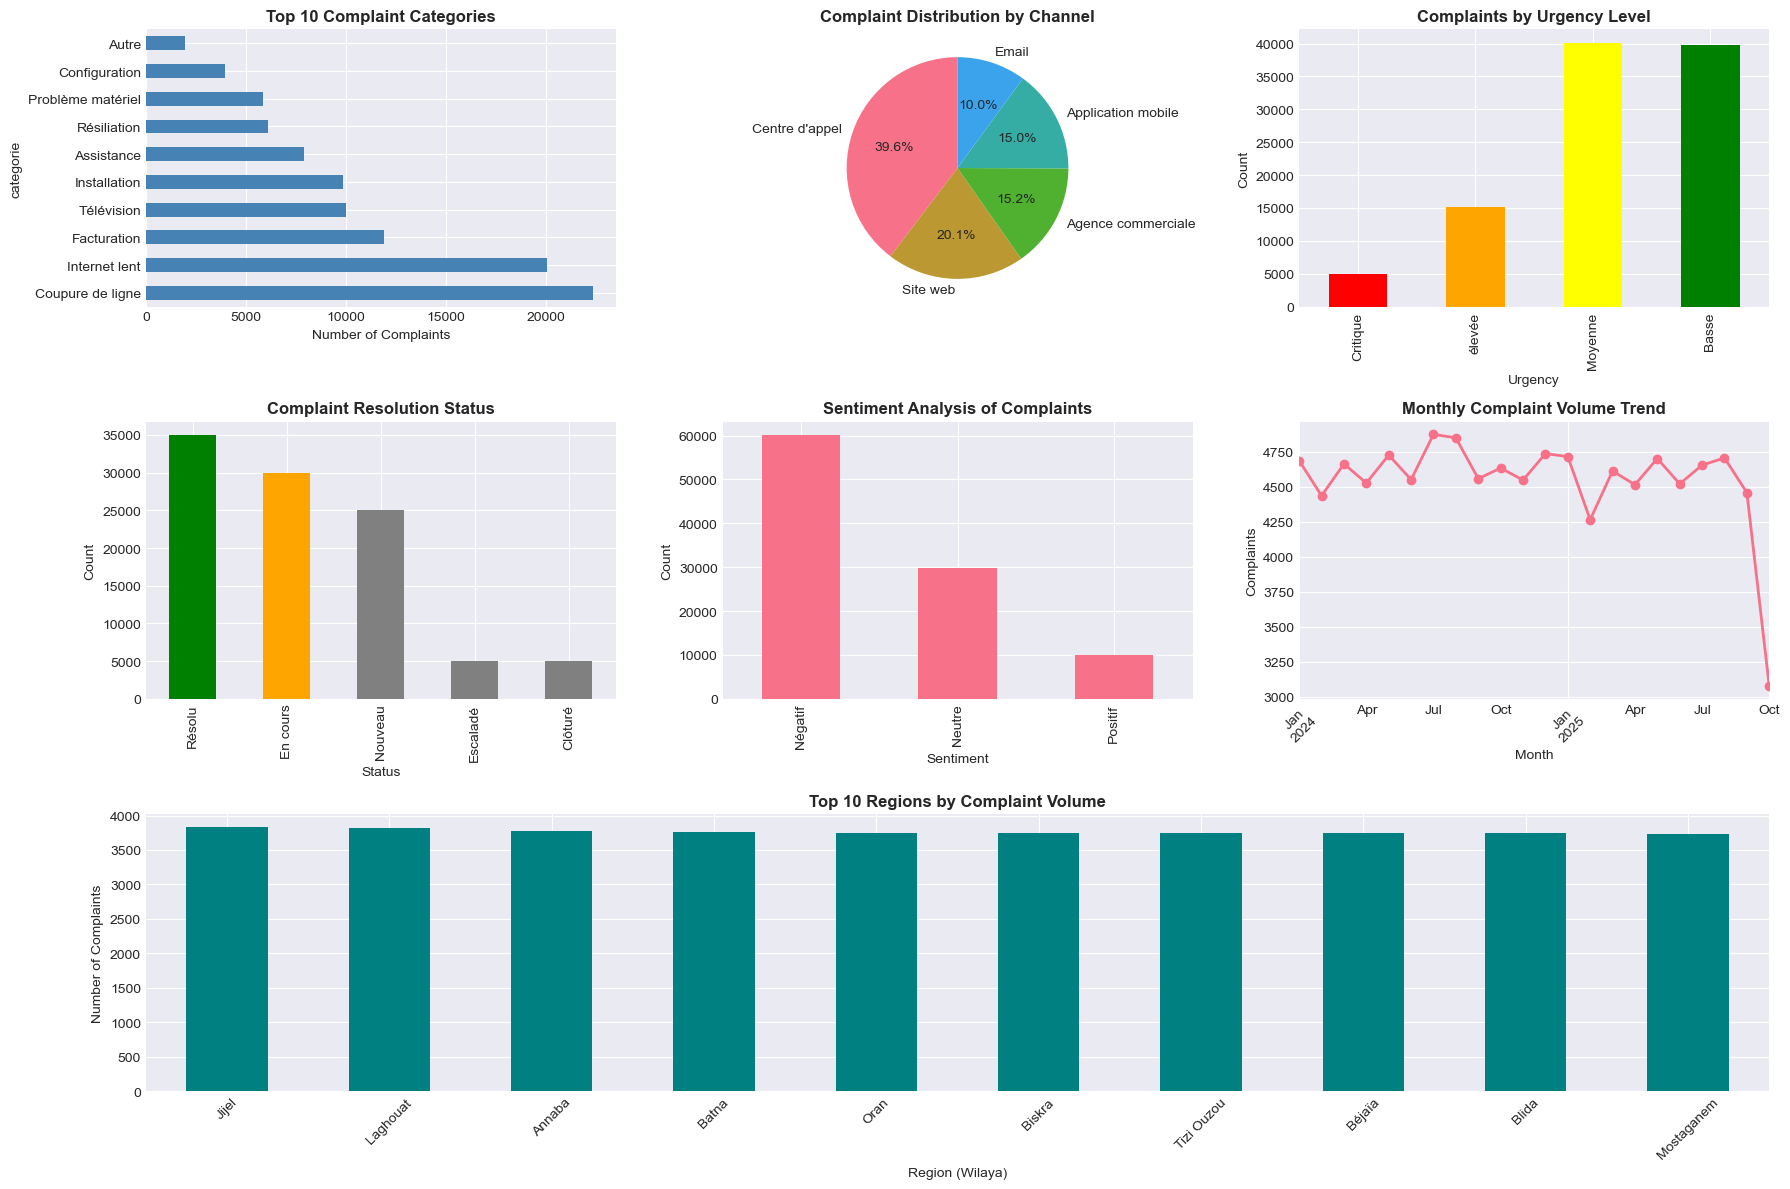

In [14]:
# === A2: Visualization Dashboard ===
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 3, figure=fig)

# 1. Complaints by Category (Top 10)
ax1 = fig.add_subplot(gs[0, 0])
if "categorie" in df.columns:
    category_counts = df["categorie"].value_counts().head(10)
    category_counts.plot(kind="barh", ax=ax1, color="steelblue")
    ax1.set_title("Top 10 Complaint Categories", fontweight="bold")
    ax1.set_xlabel("Number of Complaints")
else:
    ax1.text(0.5, 0.5, "No 'categorie' column", ha="center", va="center")
    ax1.axis("off")

# 2. Complaints by Channel
ax2 = fig.add_subplot(gs[0, 1])
if "canal" in df.columns:
    channel_counts = df["canal"].value_counts()
    channel_counts.plot(kind="pie", ax=ax2, autopct="%1.1f%%", startangle=90)
    ax2.set_title("Complaint Distribution by Channel", fontweight="bold")
    ax2.set_ylabel("")
else:
    ax2.text(0.5, 0.5, "No 'canal' column", ha="center", va="center")
    ax2.axis("off")

# 3. Complaints by Urgency Level
ax3 = fig.add_subplot(gs[0, 2])
if "urgence" in df.columns:
    urgency_order = ["Critique", "élevée", "Moyenne", "Basse"]
    urgency_counts = df["urgence"].value_counts().reindex(urgency_order).fillna(0)
    urgency_counts.plot(kind="bar", ax=ax3, color=["red", "orange", "yellow", "green"])
    ax3.set_title("Complaints by Urgency Level", fontweight="bold")
    ax3.set_xlabel("Urgency")
    ax3.set_ylabel("Count")
else:
    ax3.text(0.5, 0.5, "No 'urgence' column", ha="center", va="center")
    ax3.axis("off")

# 4. Resolution Status
ax4 = fig.add_subplot(gs[1, 0])
if "status" in df.columns:
    status_counts = df["status"].value_counts()
    colors = [
        "green" if str(s).strip() == "Résolu" else "orange" if str(s).strip() == "En cours" else "gray"
        for s in status_counts.index
    ]
    status_counts.plot(kind="bar", ax=ax4, color=colors)
    ax4.set_title("Complaint Resolution Status", fontweight="bold")
    ax4.set_xlabel("Status")
    ax4.set_ylabel("Count")
else:
    ax4.text(0.5, 0.5, "No 'status' column", ha="center", va="center")
    ax4.axis("off")

# 5. Sentiment Distribution
ax5 = fig.add_subplot(gs[1, 1])
if "sentiment" in df.columns:
    sentiment_counts = df["sentiment"].value_counts()
    sentiment_counts.plot(kind="bar", ax=ax5)
    ax5.set_title("Sentiment Analysis of Complaints", fontweight="bold")
    ax5.set_xlabel("Sentiment")
    ax5.set_ylabel("Count")
else:
    ax5.text(0.5, 0.5, "No 'sentiment' column", ha="center", va="center")
    ax5.axis("off")

# 6. Monthly Complaint Trends
ax6 = fig.add_subplot(gs[1, 2])
if "date" in df.columns:
    monthly_trend = df.groupby(df["date"].dt.to_period("M")).size()
    monthly_trend.plot(ax=ax6, marker="o", linewidth=2)
    ax6.set_title("Monthly Complaint Volume Trend", fontweight="bold")
    ax6.set_xlabel("Month")
    ax6.set_ylabel("Complaints")
    ax6.tick_params(axis="x", rotation=45)
else:
    ax6.text(0.5, 0.5, "No 'date' column", ha="center", va="center")
    ax6.axis("off")

# 7. Top 10 Regions by Complaint Volume
ax7 = fig.add_subplot(gs[2, :])
if "wilaya" in df.columns:
    region_counts = df["wilaya"].value_counts().head(10)
    region_counts.plot(kind="bar", ax=ax7, color="teal")
    ax7.set_title("Top 10 Regions by Complaint Volume", fontweight="bold")
    ax7.set_xlabel("Region (Wilaya)")
    ax7.set_ylabel("Number of Complaints")
    ax7.tick_params(axis="x", rotation=45)
else:
    ax7.text(0.5, 0.5, "No 'wilaya' column", ha="center", va="center")
    ax7.axis("off")

plt.tight_layout()
plt.show()

FREQUENT COMPLAINT TYPES DISTRIBUTION

1. TOP 5 COMPLAINT TYPES DISTRIBUTION ACROSS REGIONS:
------------------------------------------------------------


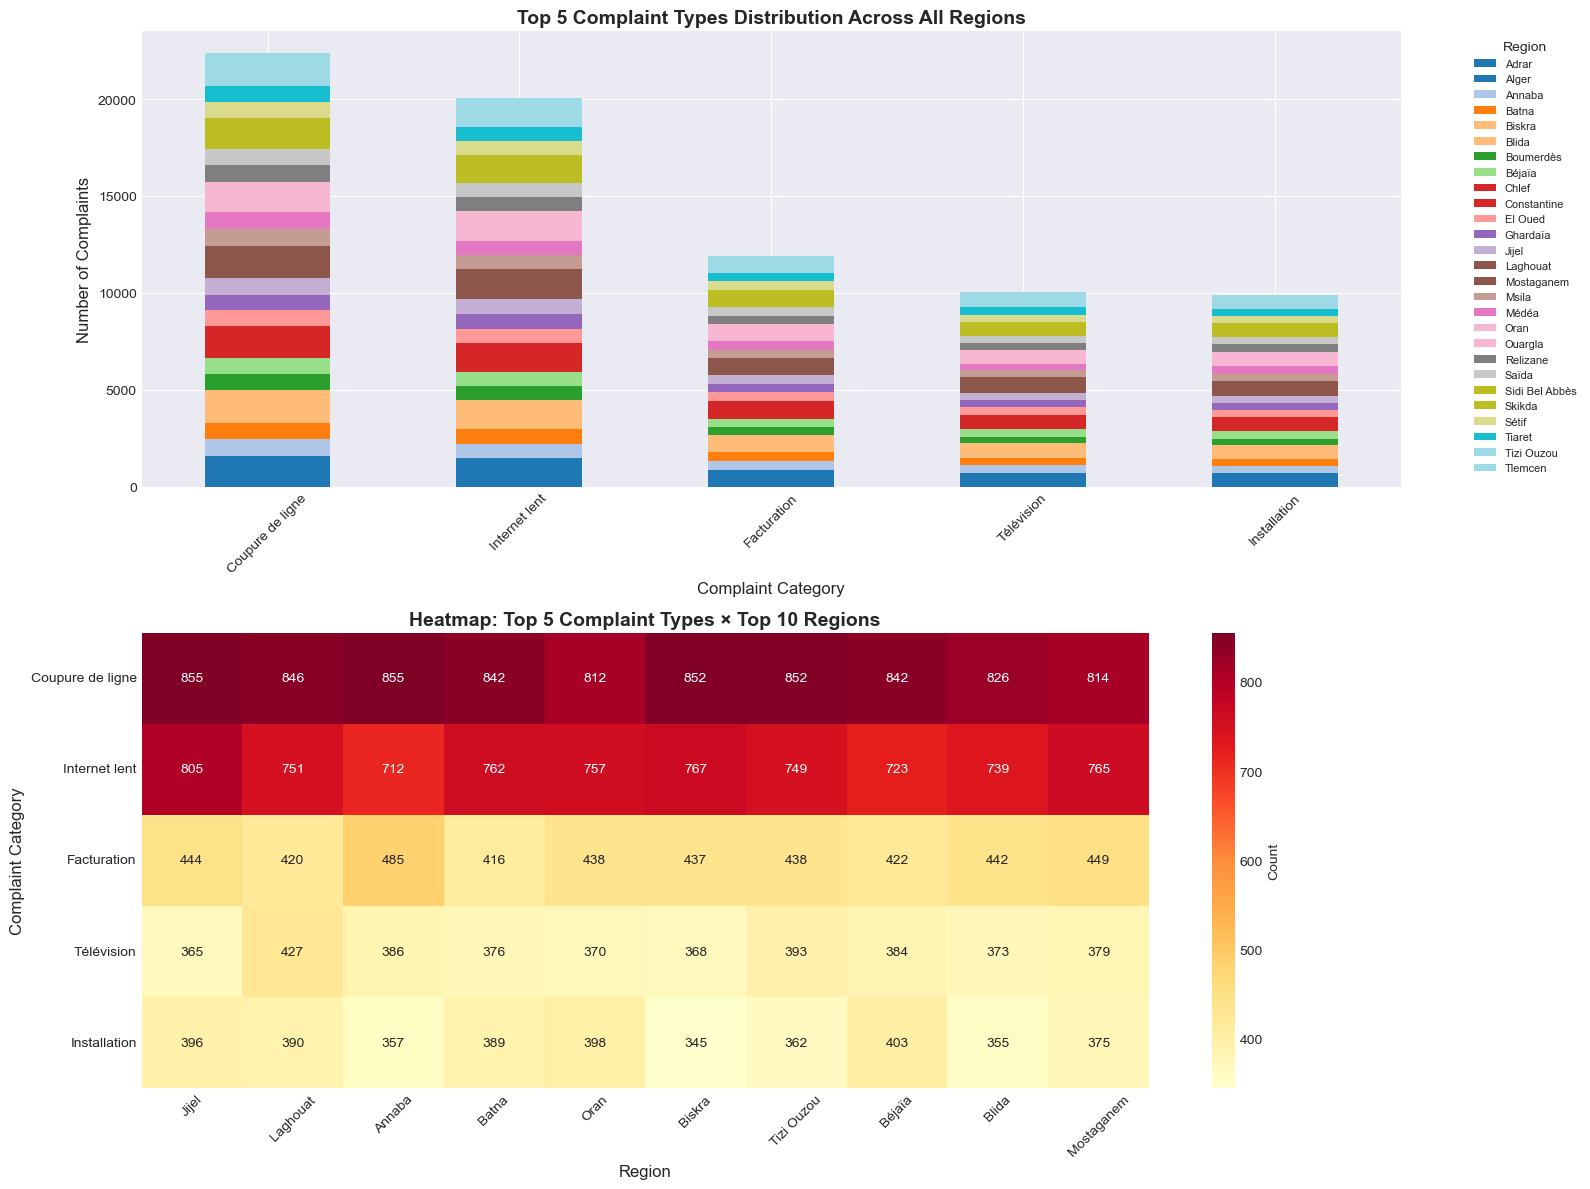


Summary Table (Top 5 Categories × Top 10 Regions):
wilaya            Jijel  Laghouat  Annaba  Batna  Oran  Biskra  Tizi Ouzou  Béjaïa  Blida  Mostaganem
categorie                                                                                            
Coupure de ligne    855       846     855    842   812     852         852     842    826         814
Internet lent       805       751     712    762   757     767         749     723    739         765
Facturation         444       420     485    416   438     437         438     422    442         449
Télévision          365       427     386    376   370     368         393     384    373         379
Installation        396       390     357    389   398     345         362     403    355         375


2. TOP 5 COMPLAINT TYPES DISTRIBUTION ACROSS CHANNELS:
------------------------------------------------------------


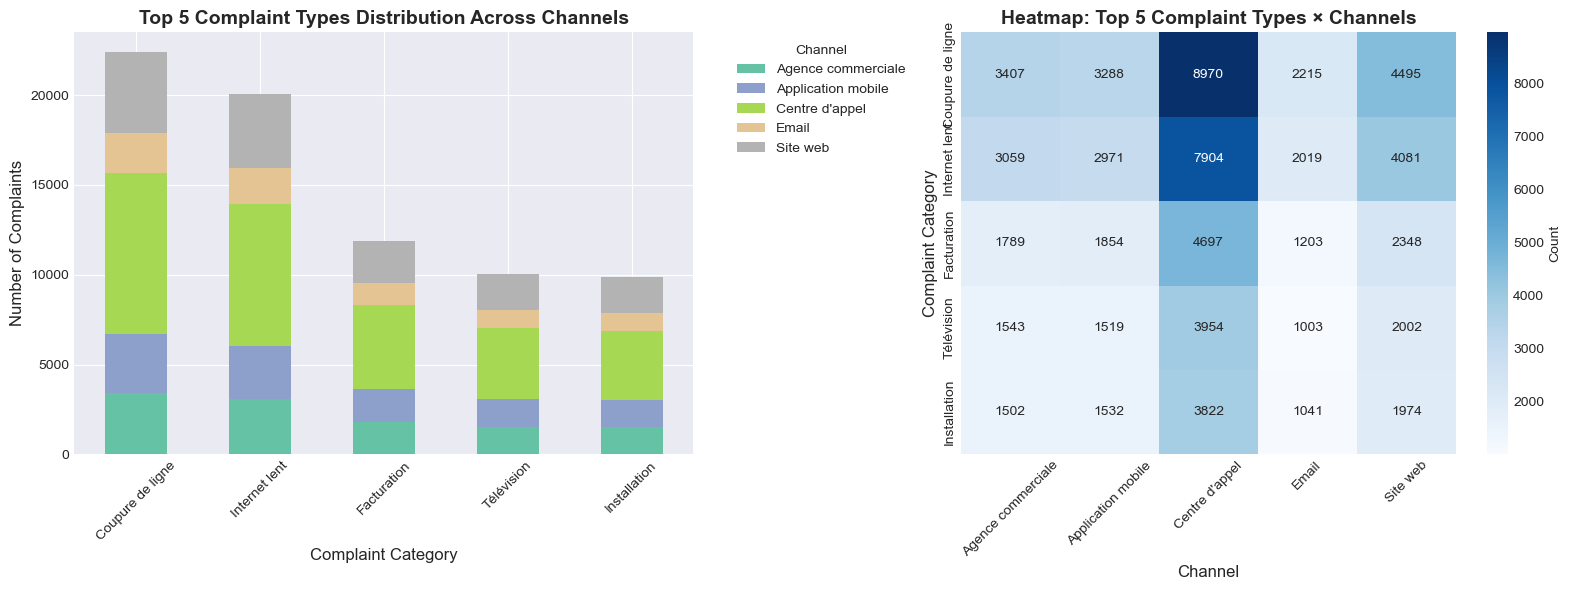


Summary Table (Top 5 Categories × All Channels):
canal             Agence commerciale  Application mobile  Centre d'appel  Email  Site web
categorie                                                                                
Coupure de ligne                3407                3288            8970   2215      4495
Internet lent                   3059                2971            7904   2019      4081
Facturation                     1789                1854            4697   1203      2348
Télévision                      1543                1519            3954   1003      2002
Installation                    1502                1532            3822   1041      1974

Percentage Distribution (Top 5 Categories × Channels):
canal             Agence commerciale  Application mobile  Centre d'appel  Email  Site web
categorie                                                                                
Coupure de ligne                15.2                14.7            40.1    9.9     

In [15]:
# === MISSING FEATURE 2: Frequent Complaint Types Distribution ===
# Distribution of top complaint types across regions and channels

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("FREQUENT COMPLAINT TYPES DISTRIBUTION")
print("=" * 80)

# Get top 5 complaint categories
if "categorie" in df.columns:
    top_categories = df["categorie"].value_counts().head(5).index.tolist()
    
    # 1. Top complaint types distribution across regions
    if "wilaya" in df.columns:
        print("\n1. TOP 5 COMPLAINT TYPES DISTRIBUTION ACROSS REGIONS:")
        print("-" * 60)
        category_region = pd.crosstab(df["categorie"], df["wilaya"])
        top_category_region = category_region.loc[top_categories]
        
        # Create visualization
        fig, axes = plt.subplots(2, 1, figsize=(16, 12))
        
        # Stacked bar chart
        top_category_region.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20")
        axes[0].set_title("Top 5 Complaint Types Distribution Across All Regions", fontsize=14, fontweight="bold")
        axes[0].set_xlabel("Complaint Category", fontsize=12)
        axes[0].set_ylabel("Number of Complaints", fontsize=12)
        axes[0].legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
        axes[0].tick_params(axis="x", rotation=45)
        
        # Heatmap for top regions only (top 10 regions)
        top_regions = df["wilaya"].value_counts().head(10).index.tolist()
        top_category_region_subset = category_region.loc[top_categories, top_regions]
        sns.heatmap(top_category_region_subset, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "Count"})
        axes[1].set_title("Heatmap: Top 5 Complaint Types × Top 10 Regions", fontsize=14, fontweight="bold")
        axes[1].set_xlabel("Region", fontsize=12)
        axes[1].set_ylabel("Complaint Category", fontsize=12)
        axes[1].tick_params(axis="x", rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary table
        print("\nSummary Table (Top 5 Categories × Top 10 Regions):")
        print(top_category_region_subset.to_string())
    
    # 2. Top complaint types distribution across channels
    if "canal" in df.columns:
        print("\n\n2. TOP 5 COMPLAINT TYPES DISTRIBUTION ACROSS CHANNELS:")
        print("-" * 60)
        category_channel = pd.crosstab(df["categorie"], df["canal"])
        top_category_channel = category_channel.loc[top_categories]
        
        # Create visualization
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Stacked bar chart
        top_category_channel.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
        axes[0].set_title("Top 5 Complaint Types Distribution Across Channels", fontsize=14, fontweight="bold")
        axes[0].set_xlabel("Complaint Category", fontsize=12)
        axes[0].set_ylabel("Number of Complaints", fontsize=12)
        axes[0].legend(title="Channel", bbox_to_anchor=(1.05, 1), loc="upper left")
        axes[0].tick_params(axis="x", rotation=45)
        
        # Heatmap
        sns.heatmap(top_category_channel, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar_kws={"label": "Count"})
        axes[1].set_title("Heatmap: Top 5 Complaint Types × Channels", fontsize=14, fontweight="bold")
        axes[1].set_xlabel("Channel", fontsize=12)
        axes[1].set_ylabel("Complaint Category", fontsize=12)
        axes[1].tick_params(axis="x", rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary table
        print("\nSummary Table (Top 5 Categories × All Channels):")
        print(top_category_channel.to_string())
        
        # Percentage distribution
        print("\nPercentage Distribution (Top 5 Categories × Channels):")
        category_channel_pct = pd.crosstab(df["categorie"], df["canal"], normalize="index") * 100
        top_category_channel_pct = category_channel_pct.loc[top_categories]
        print(top_category_channel_pct.round(1).to_string())
else:
    print("Column 'categorie' not found")


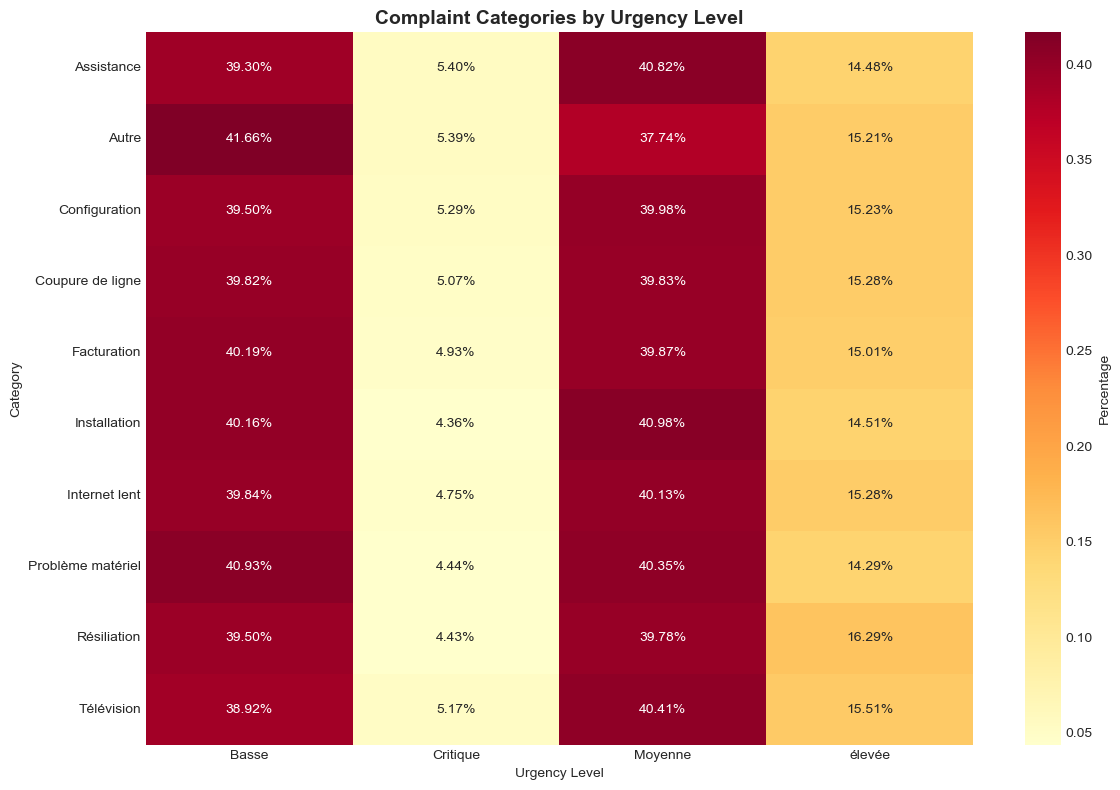


RESOLUTION RATE BY SUBMISSION CHANNEL
status              Clôturé  En cours  Escaladé  Nouveau  Résolu
canal                                                           
Agence commerciale      4.8      29.6       5.2     24.6    35.7
Application mobile      5.2      30.1       4.7     24.7    35.3
Centre d'appel          4.8      29.9       5.2     25.2    34.9
Email                   5.0      30.1       5.3     25.6    34.1
Site web                5.1      30.3       4.9     24.9    34.9


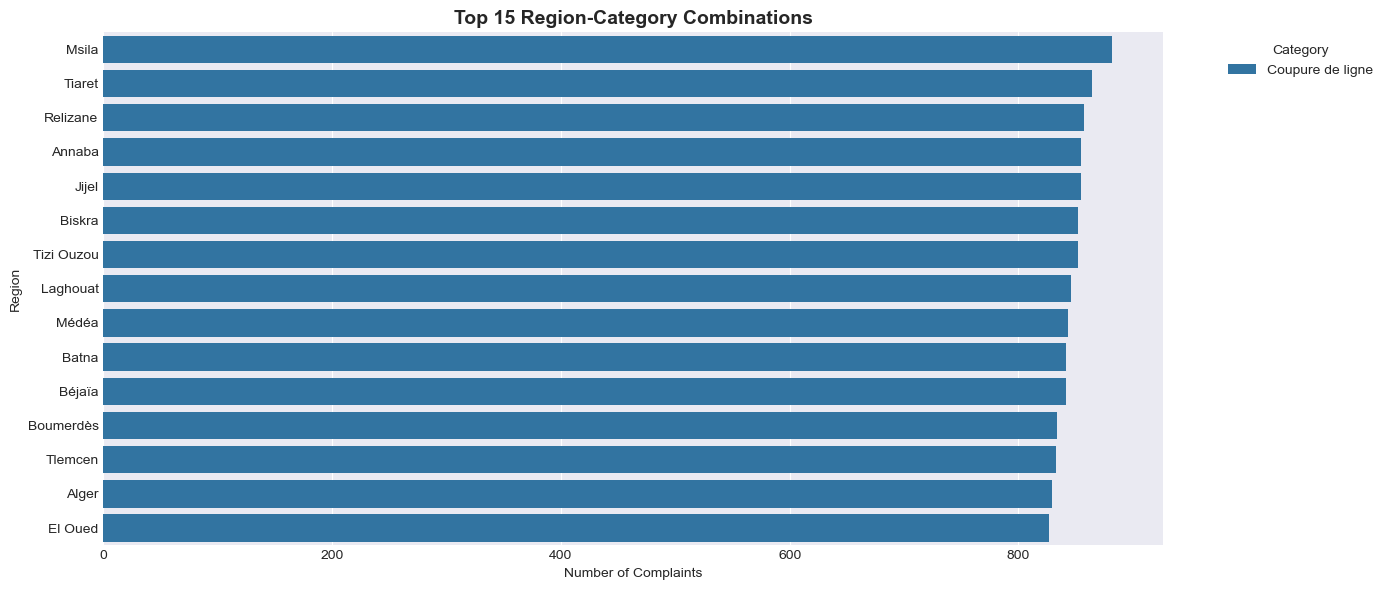

In [16]:
# === A3: Heatmaps and Cross-Tabulations ===
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Category × Urgency Heatmap
if "categorie" in df.columns and "urgence" in df.columns:
    category_urgency = pd.crosstab(df["categorie"], df["urgence"], normalize="index")
    plt.figure(figsize=(12, 8))
    sns.heatmap(category_urgency, annot=True, fmt=".2%", cmap="YlOrRd", cbar_kws={"label": "Percentage"})
    plt.title("Complaint Categories by Urgency Level", fontsize=14, fontweight="bold")
    plt.xlabel("Urgency Level")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Category × Urgency heatmap (missing 'categorie' or 'urgence').")

# 2. Channel × Status Analysis
if "canal" in df.columns and "status" in df.columns:
    channel_status = pd.crosstab(df["canal"], df["status"], normalize="index") * 100
    print("\n" + "=" * 60)
    print("RESOLUTION RATE BY SUBMISSION CHANNEL")
    print("=" * 60)
    print(channel_status.round(1).to_string())
else:
    channel_status = None
    print("Skipping Channel × Status analysis (missing 'canal' or 'status').")

# 3. Region × Category Analysis (Top combinations)
if "wilaya" in df.columns and "categorie" in df.columns:
    region_category = df.groupby(["wilaya", "categorie"]).size().reset_index(name="count")
    top_combinations = region_category.nlargest(15, "count")

    plt.figure(figsize=(14, 6))
    sns.barplot(data=top_combinations, x="count", y="wilaya", hue="categorie", palette="tab20")
    plt.title("Top 15 Region-Category Combinations", fontsize=14, fontweight="bold")
    plt.xlabel("Number of Complaints")
    plt.ylabel("Region")
    plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Region × Category chart (missing 'wilaya' or 'categorie').")

# PHASE 5: Feature Engineering

In [17]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Ensure categorical columns are strings
categorical_cols = [
    "wilaya", "canal", "categorie",
    "sentiment", "urgence", "status",
    "suggested_action"
]

df[categorical_cols] = df[categorical_cols].astype(str)

df.dtypes


id                            int64
date                 datetime64[ns]
wilaya                       object
canal                        object
texte_reclamation            object
categorie                    object
sentiment                    object
urgence                      object
status                       object
suggested_action             object
month                     period[M]
day_of_week                  object
hour                          int32
month_name                   object
clean_text                   object
dtype: object

In [18]:
import re

def basic_text_cleaning(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)   # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [19]:
df["clean_text"] = df["texte_reclamation"].apply(basic_text_cleaning)

df[["texte_reclamation", "clean_text"]].head()


,texte_reclamation,clean_text
0,Incident: modem ne se synchronise pas.,incident modem ne se synchronise pas
1,"Client signale problème lors de la résiliation, facturation continue.",client signale problème lors de la résiliation facturation continue
2,Demande d'assistance: bruit important sur la ligne téléphonique.,demande d assistance bruit important sur la ligne téléphonique
3,"Incident: problème lors de la résiliation, facturation continue.",incident problème lors de la résiliation facturation continue
4,Incident: installation non réalisée dans les délais.,incident installation non réalisée dans les délais


In [20]:
TEXT_FEATURE = "clean_text"

META_FEATURES = [
    "wilaya",
    "canal",
    "urgence",
    "status"
]

LABEL_COLUMNS = [
    "categorie",
    "sentiment"
]


In [21]:

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Make sure text has no missing values
df[TEXT_FEATURE] = df[TEXT_FEATURE].fillna("")

# Option A (recommended): NLTK French stopwords (downloads once)
try:
    import nltk
    from nltk.corpus import stopwords

    nltk.download("stopwords", quiet=True)
    french_stop_words = stopwords.words("french")
except Exception:
    # Fallback: small built-in French stopword list (minimal)
    french_stop_words = [
        "a", "au", "aux", "avec", "ce", "ces", "dans", "de", "des", "du", "elle", "en",
        "et", "eux", "il", "je", "la", "le", "les", "leur", "lui", "ma", "mais", "me",
        "meme", "mes", "moi", "mon", "ne", "nos", "notre", "nous", "on", "ou", "par",
        "pas", "pour", "qu", "que", "qui", "sa", "se", "ses", "son", "sur", "ta", "te",
        "tes", "toi", "ton", "tu", "un", "une", "vos", "votre", "vous", "y", "à", "ça",
        "c", "d", "j", "l", "m", "n", "s", "t"
    ]

tfidf_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=5,
            max_df=0.9,
            stop_words=french_stop_words,  # <-- list, not "french"
        ))
    ]
)

X_text_tfidf = tfidf_pipeline.fit_transform(df[TEXT_FEATURE])
X_text_tfidf.shape


(100000, 128)

In [22]:

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# sklearn >= 1.2 uses sparse_output; older versions use sparse
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

metadata_pipeline = ColumnTransformer(
    transformers=[
        ("cat", ohe, META_FEATURES)
    ]
)

metadata_pipeline
X_meta = metadata_pipeline.fit_transform(df)

X_meta.shape


(100000, 41)

In [23]:
from scipy.sparse import hstack

X_hybrid = hstack([X_text_tfidf, X_meta])

X_hybrid.shape


(100000, 169)

In [24]:
print("Text features:", X_text_tfidf.shape)
print("Metadata features:", X_meta.shape)
print("Hybrid features:", X_hybrid.shape)


Text features: (100000, 128)
Metadata features: (100000, 41)
Hybrid features: (100000, 169)


## Phase 2 Conclusion — Feature Preparation
The dataset required minimal cleaning due to its synthetic nature.
This phase focused on constructing standardized and reusable feature
representations using scikit-learn pipelines.
Three feature spaces were prepared:
These representations enable fair and systematic comparison of multiple
clustering algorithms in subsequent phases.


# PHASE 4: Text Analysis
- Optional word cloud (runs only if `wordcloud` is installed)

In [25]:
# === B1/B2: Basic Text Mining (keywords + bigrams) ===
from collections import Counter
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Base stopwords list is already defined earlier as `french_stop_words` (list).
# Extend with a small domain-specific stopword set.
domain_stopwords = {
    "client", "signale", "abonné", "abonne", "rapporte", "incident", "réclamation", "reclamation",
    "demande", "assistance", "svp", "merci", "bonjour", "salut", "urgent", "urgence"
}
_base_stopwords = set(map(str, globals().get("french_stop_words", [])))
stop_set = _base_stopwords | domain_stopwords

word_re = re.compile(r"\b[a-zàâçéèêëîïôûùüÿæœ]+\b", re.IGNORECASE)

def extract_words(text: str):
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return []
    words = word_re.findall(str(text).lower())
    return [w for w in words if w not in stop_set and len(w) > 2]

text_col = "clean_text" if "clean_text" in df.columns else ("texte_reclamation" if "texte_reclamation" in df.columns else None)
if text_col is None:
    raise ValueError("No text column found: expected 'clean_text' or 'texte_reclamation'.")

all_words = []
for t in df[text_col].astype(str).tolist():
    all_words.extend(extract_words(t))

word_freq = Counter(all_words)

print("=" * 50)
print("TOP 20 MOST FREQUENT WORDS IN COMPLAINTS")
print("=" * 50)
for word, count in word_freq.most_common(20):
    print(f"{word:20} : {count:>6,}")

# --- Optional word cloud ---
try:
    from wordcloud import WordCloud
    wc_text = " ".join(df[text_col].astype(str).tolist())
    plt.figure(figsize=(12, 6))
    wordcloud = WordCloud(
        width=900, height=450,
        background_color="white",
        stopwords=stop_set,
        max_words=120,
    ).generate(wc_text)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Customer Complaints", fontsize=16, fontweight="bold")
    plt.show()
except Exception as e:
    print("\n[WordCloud skipped] Install with: %pip install wordcloud")
    print("Reason:", repr(e))

# --- Bigram phrases (no NLTK required) ---
def extract_bigrams(text: str):
    words = extract_words(text)
    return list(zip(words, words[1:])) if len(words) >= 2 else []

all_bigrams = []
for t in df[text_col].astype(str).tolist():
    all_bigrams.extend(extract_bigrams(t))

bigram_freq = Counter(all_bigrams)

print("\n" + "=" * 50)
print("TOP 20 MOST FREQUENT PHRASES (BIGRAMS)")
print("=" * 50)
for phrase, count in bigram_freq.most_common(20):
    print(f"{' '.join(phrase):30} : {count:>6,}")

TOP 20 MOST FREQUENT WORDS IN COMPLAINTS
lors                 : 19,905
image                : 10,112
figée                : 10,112
certaines            : 10,112
chaines              : 10,112
montant              : 10,066
facturé              : 10,066
incorrectement       : 10,066
régularisation       : 10,066
bruit                : 10,048
important            : 10,048
ligne                : 10,048
téléphonique         : 10,048
débit                : 10,034
très                 : 10,034
faible               : 10,034
soirée               : 10,034
installation         : 10,017
non                  : 10,017
réalisée             : 10,017

[WordCloud skipped] Install with: %pip install wordcloud
Reason: ModuleNotFoundError("No module named 'wordcloud'")

TOP 20 MOST FREQUENT PHRASES (BIGRAMS)
image figée                    : 10,112
figée certaines                : 10,112
certaines chaines              : 10,112
montant facturé                : 10,066
facturé incorrectement         : 10,066
in

SENTIMENT-BASED GROUPING ANALYSIS

1. CATEGORY DISTRIBUTION BY SENTIMENT:
------------------------------------------------------------


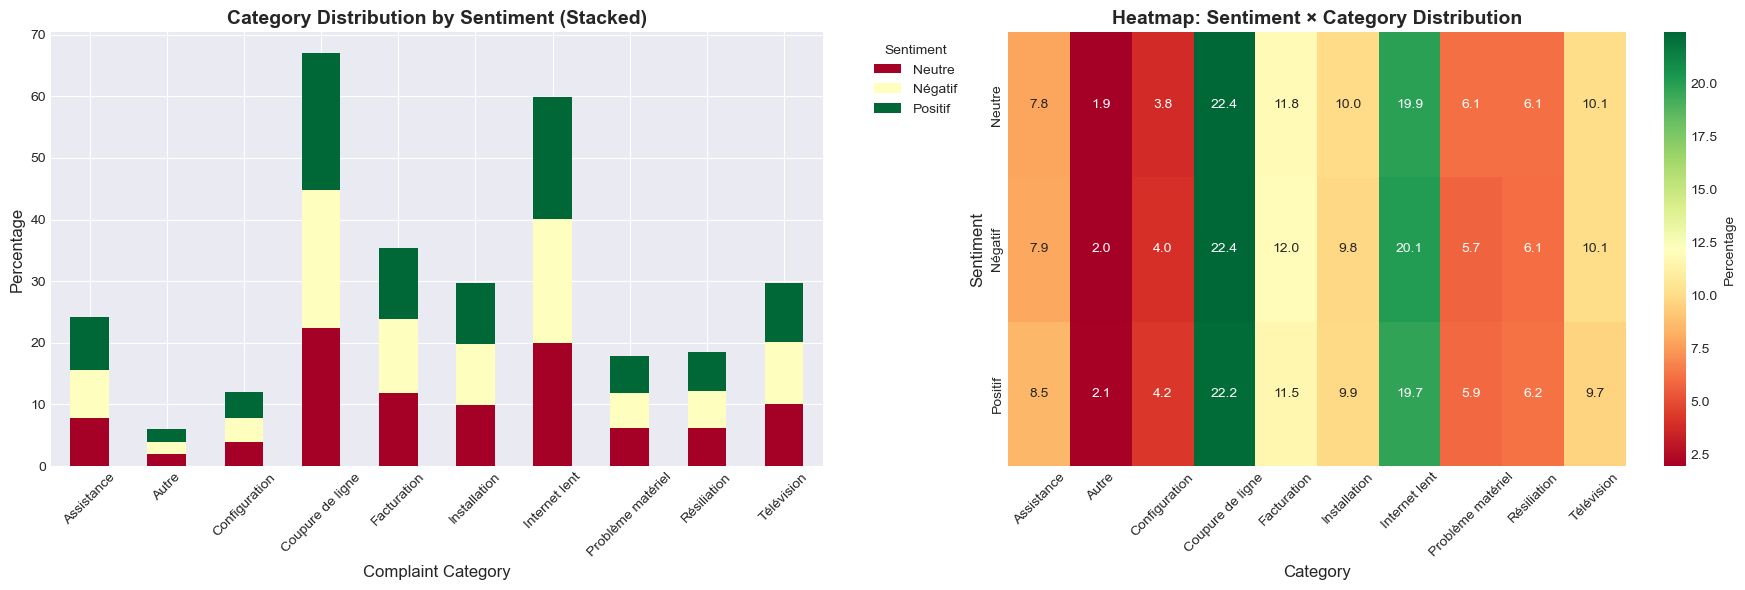


Percentage Distribution Table:
categorie  Assistance  Autre  Configuration  Coupure de ligne  Facturation  Installation  Internet lent  Problème matériel  Résiliation  Télévision
sentiment                                                                                                                                          
Neutre            7.8    1.9            3.8              22.4         11.8          10.0           19.9                6.1          6.1        10.1
Négatif           7.9    2.0            4.0              22.4         12.0           9.8           20.1                5.7          6.1        10.1
Positif           8.5    2.1            4.2              22.2         11.5           9.9           19.7                5.9          6.2         9.7


Count Distribution Table:
categorie  Assistance  Autre  Configuration  Coupure de ligne  Facturation  Installation  Internet lent  Problème matériel  Résiliation  Télévision
sentiment                                           

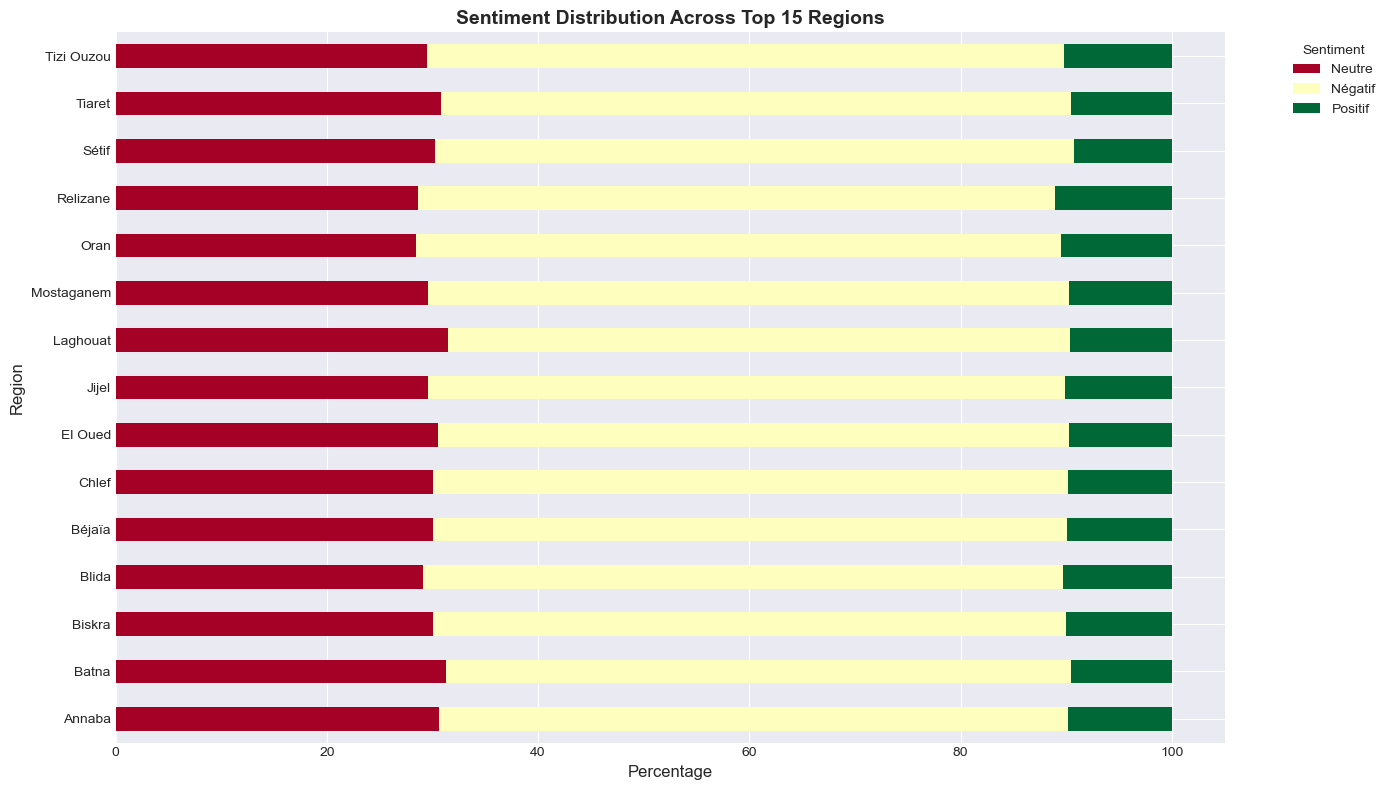


Percentage Distribution (Top 15 Regions):
sentiment   Neutre  Négatif  Positif
wilaya                              
Annaba        30.6     59.6      9.8
Batna         31.2     59.2      9.5
Biskra        30.1     59.9     10.0
Blida         29.1     60.6     10.3
Béjaïa        30.1     60.0      9.9
Chlef         30.1     60.1      9.8
El Oued       30.5     59.8      9.7
Jijel         29.5     60.4     10.1
Laghouat      31.4     58.9      9.6
Mostaganem    29.6     60.7      9.8
Oran          28.4     61.1     10.5
Relizane      28.7     60.3     11.1
Sétif         30.2     60.6      9.2
Tiaret        30.8     59.7      9.6
Tizi Ouzou    29.5     60.3     10.2


3. CHANNEL SENTIMENT PATTERNS:
------------------------------------------------------------


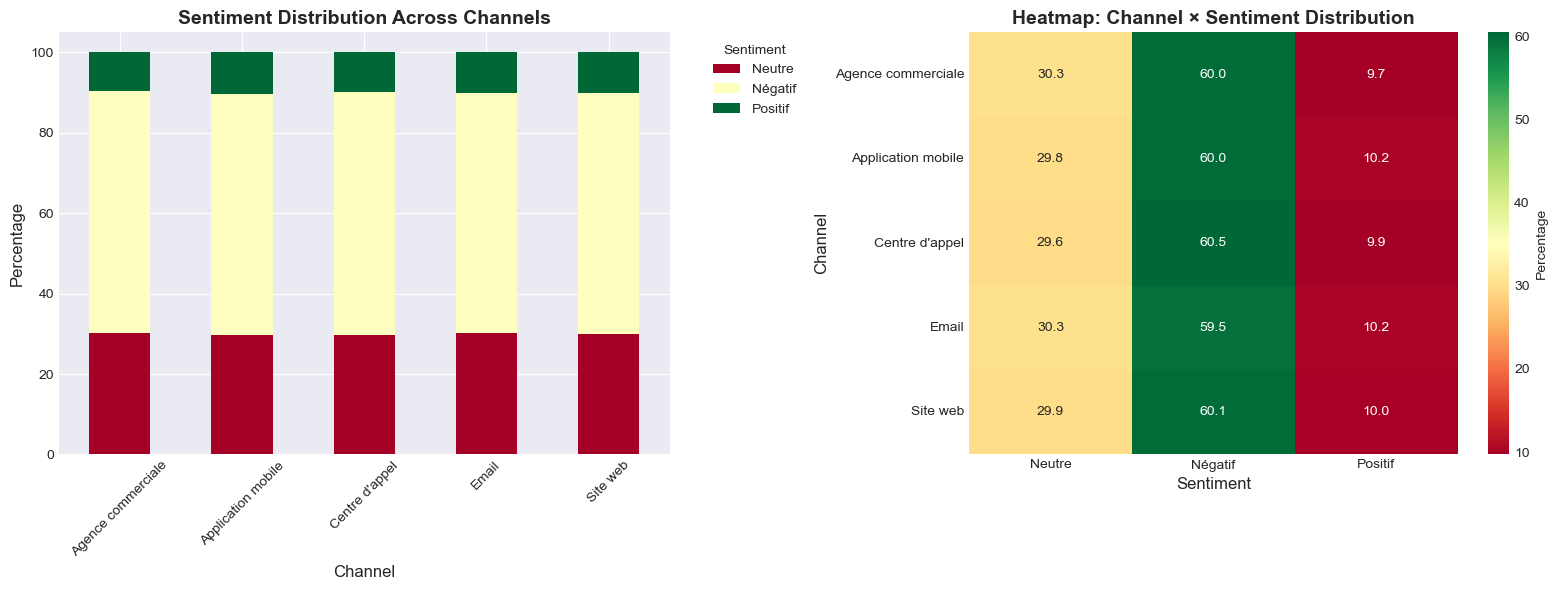


Percentage Distribution:
sentiment           Neutre  Négatif  Positif
canal                                       
Agence commerciale    30.3     60.0      9.7
Application mobile    29.8     60.0     10.2
Centre d'appel        29.6     60.5      9.9
Email                 30.3     59.5     10.2
Site web              29.9     60.1     10.0


Count Distribution:
sentiment           Neutre  Négatif  Positif
canal                                       
Agence commerciale    4608     9121     1477
Application mobile    4479     9008     1538
Centre d'appel       11745    23995     3909
Email                 3038     5974     1023
Site web              6013    12069     2003


4. URGENCY LEVELS BY SENTIMENT:
------------------------------------------------------------


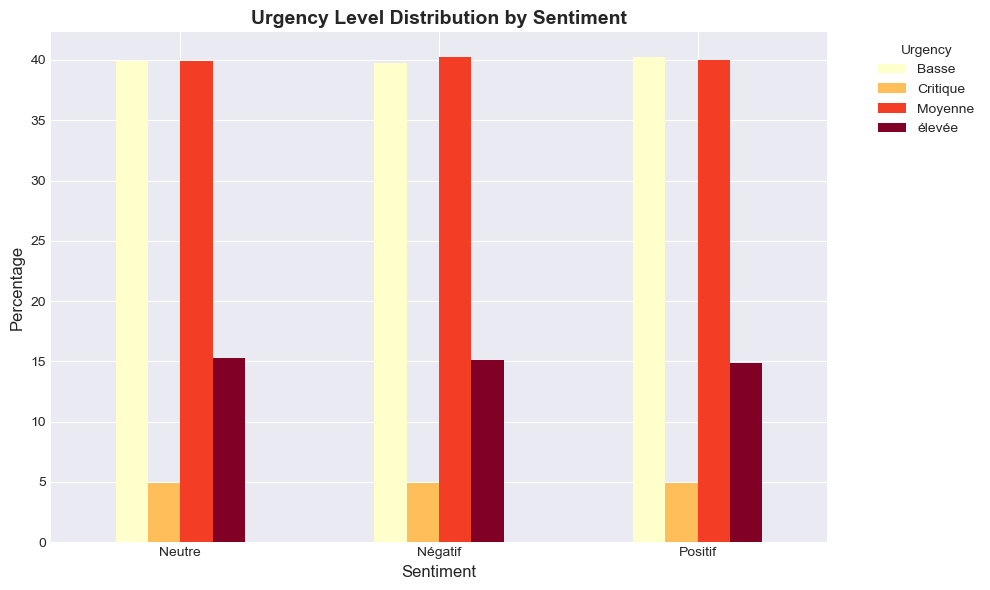


Percentage Distribution:
urgence    Basse  Critique  Moyenne  élevée
sentiment                                  
Neutre      39.9       4.9     39.9    15.3
Négatif     39.7       4.9     40.3    15.1
Positif     40.3       4.9     40.0    14.9


5. RESOLUTION STATUS BY SENTIMENT:
------------------------------------------------------------


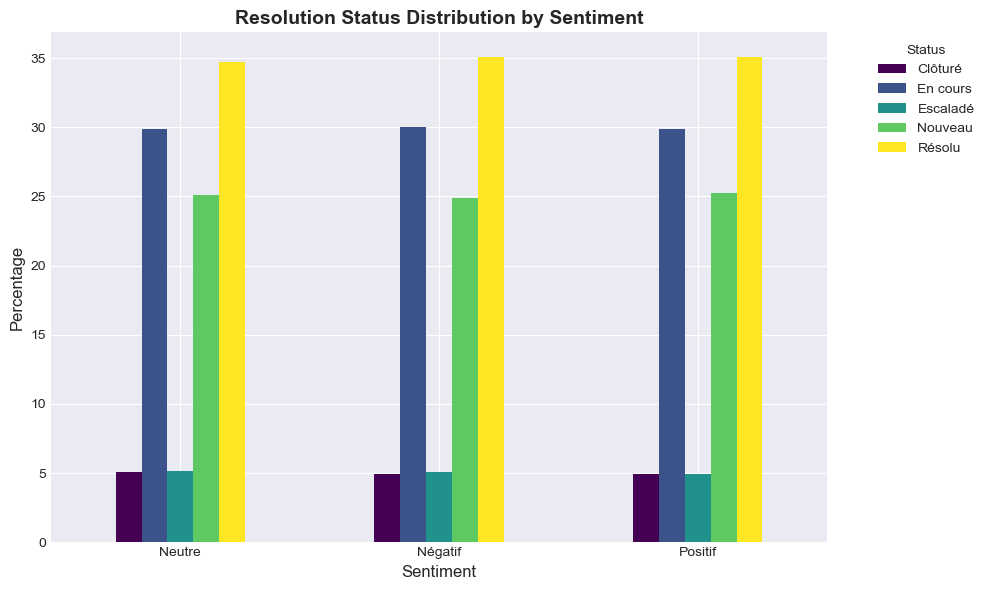


Percentage Distribution:
status     Clôturé  En cours  Escaladé  Nouveau  Résolu
sentiment                                              
Neutre         5.1      29.9       5.1     25.1    34.7
Négatif        4.9      30.0       5.1     24.9    35.1
Positif        4.9      29.9       4.9     25.2    35.1


In [26]:
# === MISSING FEATURE 3: Sentiment-Based Grouping Analysis ===
# Group complaints by sentiment to detect patterns

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 80)
print("SENTIMENT-BASED GROUPING ANALYSIS")
print("=" * 80)

if "sentiment" not in df.columns:
    print("Column 'sentiment' not found. Skipping sentiment-based grouping.")
else:
    # 1. Category distribution by sentiment
    print("\n1. CATEGORY DISTRIBUTION BY SENTIMENT:")
    print("-" * 60)
    if "categorie" in df.columns:
        sentiment_category = pd.crosstab(df["sentiment"], df["categorie"], normalize="index") * 100
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        # Stacked bar chart
        sentiment_category.T.plot(kind="bar", stacked=True, ax=axes[0], colormap="RdYlGn")
        axes[0].set_title("Category Distribution by Sentiment (Stacked)", fontsize=14, fontweight="bold")
        axes[0].set_xlabel("Complaint Category", fontsize=12)
        axes[0].set_ylabel("Percentage", fontsize=12)
        axes[0].legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
        axes[0].tick_params(axis="x", rotation=45)
        
        # Heatmap
        sns.heatmap(sentiment_category, annot=True, fmt=".1f", cmap="RdYlGn", ax=axes[1], cbar_kws={"label": "Percentage"})
        axes[1].set_title("Heatmap: Sentiment × Category Distribution", fontsize=14, fontweight="bold")
        axes[1].set_xlabel("Category", fontsize=12)
        axes[1].set_ylabel("Sentiment", fontsize=12)
        axes[1].tick_params(axis="x", rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print("\nPercentage Distribution Table:")
        print(sentiment_category.round(1).to_string())
        
        # Count table
        sentiment_category_count = pd.crosstab(df["sentiment"], df["categorie"])
        print("\n\nCount Distribution Table:")
        print(sentiment_category_count.to_string())
    
    # 2. Regional sentiment patterns
    print("\n\n2. REGIONAL SENTIMENT PATTERNS (Top 15 Regions):")
    print("-" * 60)
    if "wilaya" in df.columns:
        top_regions = df["wilaya"].value_counts().head(15).index.tolist()
        region_sentiment = pd.crosstab(df[df["wilaya"].isin(top_regions)]["wilaya"], 
                                       df[df["wilaya"].isin(top_regions)]["sentiment"],
                                       normalize="index") * 100
        
        # Visualization
        fig, ax = plt.subplots(figsize=(14, 8))
        region_sentiment.plot(kind="barh", stacked=True, ax=ax, colormap="RdYlGn")
        ax.set_title("Sentiment Distribution Across Top 15 Regions", fontsize=14, fontweight="bold")
        ax.set_xlabel("Percentage", fontsize=12)
        ax.set_ylabel("Region", fontsize=12)
        ax.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
        
        print("\nPercentage Distribution (Top 15 Regions):")
        print(region_sentiment.round(1).to_string())
    
    # 3. Channel sentiment patterns
    print("\n\n3. CHANNEL SENTIMENT PATTERNS:")
    print("-" * 60)
    if "canal" in df.columns:
        channel_sentiment = pd.crosstab(df["canal"], df["sentiment"], normalize="index") * 100
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Stacked bar chart
        channel_sentiment.plot(kind="bar", stacked=True, ax=axes[0], colormap="RdYlGn")
        axes[0].set_title("Sentiment Distribution Across Channels", fontsize=14, fontweight="bold")
        axes[0].set_xlabel("Channel", fontsize=12)
        axes[0].set_ylabel("Percentage", fontsize=12)
        axes[0].legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
        axes[0].tick_params(axis="x", rotation=45)
        
        # Heatmap
        sns.heatmap(channel_sentiment, annot=True, fmt=".1f", cmap="RdYlGn", ax=axes[1], cbar_kws={"label": "Percentage"})
        axes[1].set_title("Heatmap: Channel × Sentiment Distribution", fontsize=14, fontweight="bold")
        axes[1].set_xlabel("Sentiment", fontsize=12)
        axes[1].set_ylabel("Channel", fontsize=12)
        
        plt.tight_layout()
        plt.show()
        
        print("\nPercentage Distribution:")
        print(channel_sentiment.round(1).to_string())
        
        # Count table
        channel_sentiment_count = pd.crosstab(df["canal"], df["sentiment"])
        print("\n\nCount Distribution:")
        print(channel_sentiment_count.to_string())
    
    # 4. Urgency by sentiment
    print("\n\n4. URGENCY LEVELS BY SENTIMENT:")
    print("-" * 60)
    if "urgence" in df.columns:
        urgency_sentiment = pd.crosstab(df["sentiment"], df["urgence"], normalize="index") * 100
        
        # Visualization
        fig, ax = plt.subplots(figsize=(10, 6))
        urgency_sentiment.plot(kind="bar", ax=ax, colormap="YlOrRd")
        ax.set_title("Urgency Level Distribution by Sentiment", fontsize=14, fontweight="bold")
        ax.set_xlabel("Sentiment", fontsize=12)
        ax.set_ylabel("Percentage", fontsize=12)
        ax.legend(title="Urgency", bbox_to_anchor=(1.05, 1), loc="upper left")
        ax.tick_params(axis="x", rotation=0)
        plt.tight_layout()
        plt.show()
        
        print("\nPercentage Distribution:")
        print(urgency_sentiment.round(1).to_string())
    
    # 5. Status by sentiment
    print("\n\n5. RESOLUTION STATUS BY SENTIMENT:")
    print("-" * 60)
    if "status" in df.columns:
        status_sentiment = pd.crosstab(df["sentiment"], df["status"], normalize="index") * 100
        
        # Visualization
        fig, ax = plt.subplots(figsize=(10, 6))
        status_sentiment.plot(kind="bar", ax=ax, colormap="viridis")
        ax.set_title("Resolution Status Distribution by Sentiment", fontsize=14, fontweight="bold")
        ax.set_xlabel("Sentiment", fontsize=12)
        ax.set_ylabel("Percentage", fontsize=12)
        ax.legend(title="Status", bbox_to_anchor=(1.05, 1), loc="upper left")
        ax.tick_params(axis="x", rotation=0)
        plt.tight_layout()
        plt.show()
        
        print("\nPercentage Distribution:")
        print(status_sentiment.round(1).to_string())


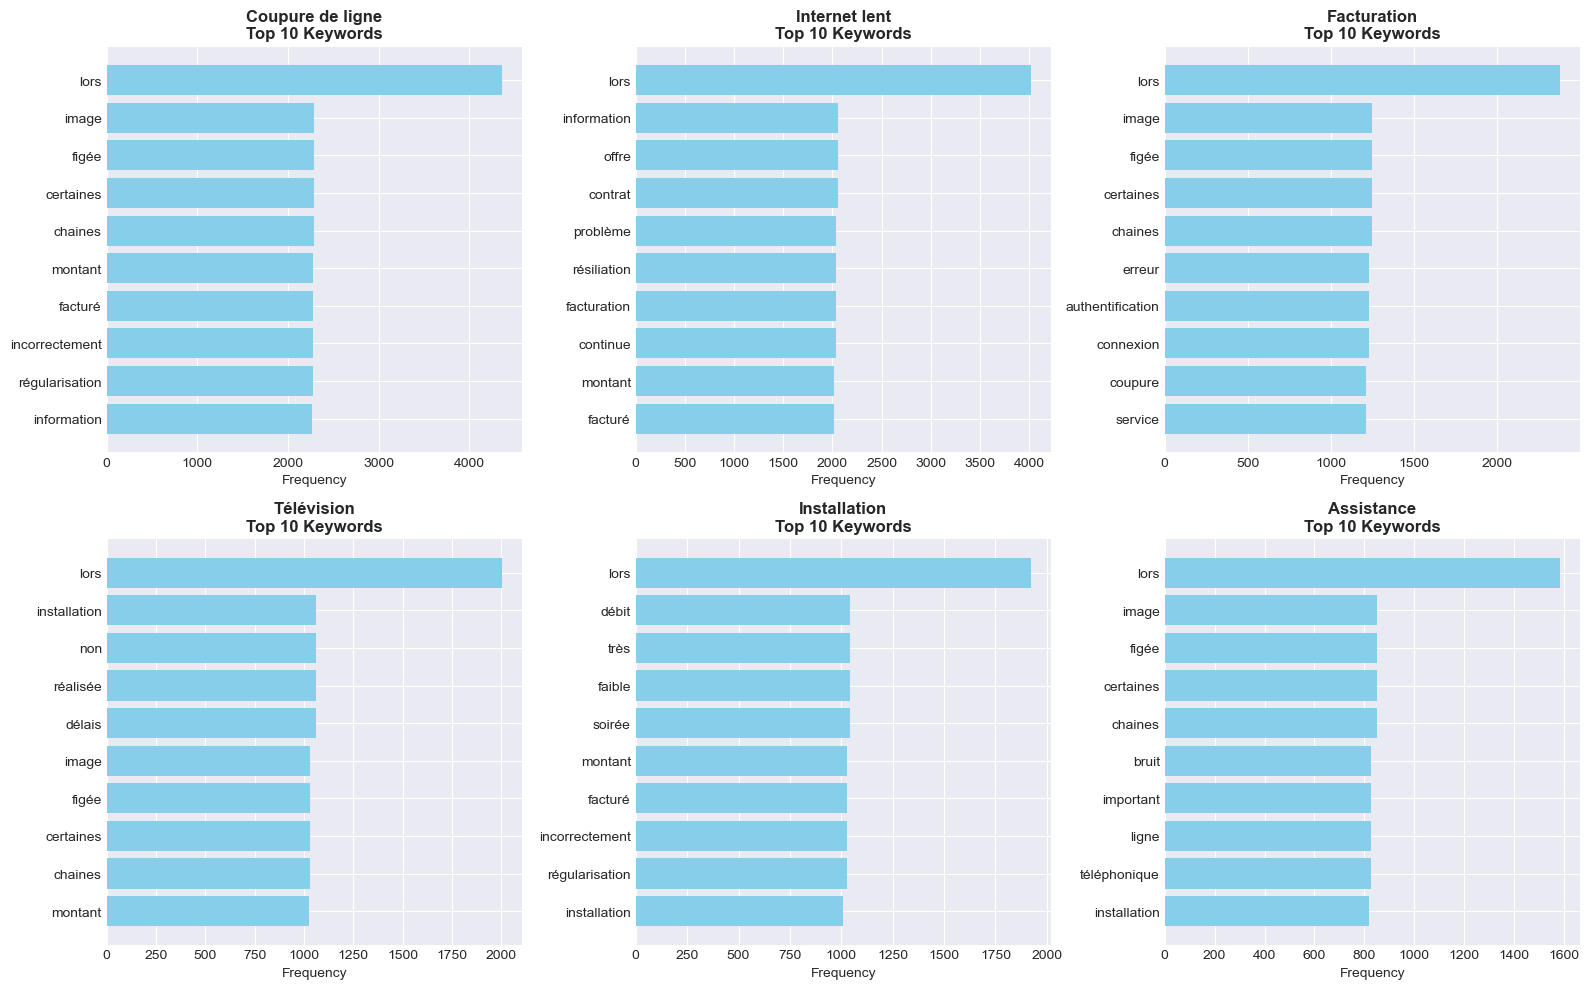

In [27]:
# === B3: Text Analysis by Category (Top keywords) ===
import matplotlib.pyplot as plt
import numpy as np

if "categorie" not in df.columns:
    print("Skipping B3 (no 'categorie' column).")
else:
    top_categories = df["categorie"].value_counts().head(6).index.tolist()
    n = len(top_categories)
    if n == 0:
        print("No categories found.")
    else:
        rows = 2
        cols = 3
        fig, axes = plt.subplots(rows, cols, figsize=(16, 10))
        axes = np.array(axes).ravel()

        for i_ax, category in enumerate(top_categories):
            ax = axes[i_ax]
            cat_texts = df.loc[df["categorie"] == category, text_col].astype(str).tolist()
            words = []
            for t in cat_texts:
                words.extend(extract_words(t))
            wf = Counter(words)
            top_words = wf.most_common(10)
            if not top_words:
                ax.axis("off")
                ax.set_title(f"{category}\n(no keywords)")
                continue
            words_list, counts = zip(*top_words)
            ax.barh(range(len(words_list)), counts, color="skyblue")
            ax.set_yticks(range(len(words_list)))
            ax.set_yticklabels(words_list)
            ax.invert_yaxis()
            ax.set_title(f"{category}\nTop 10 Keywords", fontweight="bold")
            ax.set_xlabel("Frequency")

        # hide unused axes
        for j in range(n, rows * cols):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

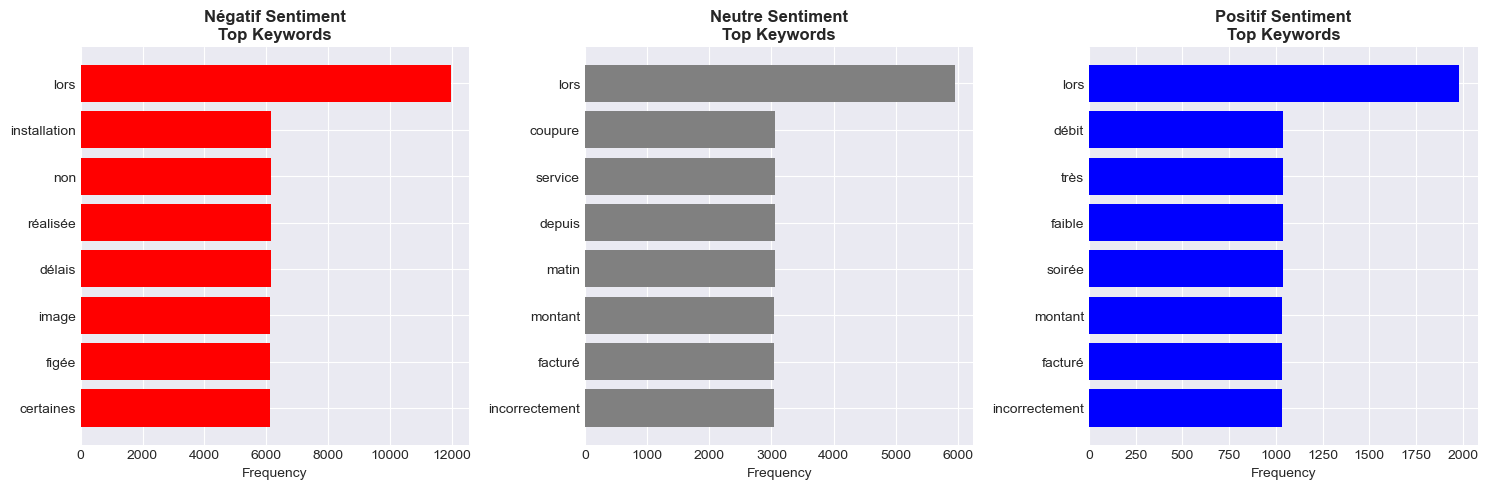


UNIQUE WORDS CHARACTERISTIC OF EACH SENTIMENT (first 10):
------------------------------------------------------------
Négatif   : ...
Neutre    : ...
Positif   : ...


In [28]:
# === B4: Text Analysis by Sentiment (Top keywords + unique words) ===
import matplotlib.pyplot as plt
import numpy as np

if "sentiment" not in df.columns:
    print("Skipping B4 (no 'sentiment' column).")
else:
    sentiments = ["Négatif", "Neutre", "Positif"]
    present = [s for s in sentiments if (df["sentiment"].astype(str) == s).any()]
    if not present:
        # fall back to whatever exists
        present = df["sentiment"].astype(str).value_counts().index.tolist()[:3]

    fig, axes = plt.subplots(1, len(present), figsize=(5 * len(present), 5))
    if len(present) == 1:
        axes = [axes]
    colors = {"Négatif": "red", "Neutre": "gray", "Positif": "blue"}

    for i, s in enumerate(present):
        ax = axes[i]
        s_texts = df.loc[df["sentiment"].astype(str) == s, text_col].astype(str).tolist()
        words = []
        for t in s_texts:
            words.extend(extract_words(t))
        wf = Counter(words)
        top_words = wf.most_common(8)
        if not top_words:
            ax.axis("off")
            ax.set_title(f"{s}\n(no keywords)")
            continue
        words_list, counts = zip(*top_words)
        ax.barh(range(len(words_list)), counts, color=colors.get(s, "steelblue"))
        ax.set_yticks(range(len(words_list)))
        ax.set_yticklabels(words_list)
        ax.invert_yaxis()
        ax.set_title(f"{s} Sentiment\nTop Keywords", fontweight="bold")
        ax.set_xlabel("Frequency")

    plt.tight_layout()
    plt.show()

    print("\nUNIQUE WORDS CHARACTERISTIC OF EACH SENTIMENT (first 10):")
    print("-" * 60)
    all_sent_words = {}
    for s in present:
        s_words = set()
        for t in df.loc[df["sentiment"].astype(str) == s, text_col].astype(str).tolist():
            s_words.update(extract_words(t))
        all_sent_words[s] = s_words

    for s in present:
        others = set().union(*[w for k, w in all_sent_words.items() if k != s])
        unique_words = sorted(list(all_sent_words[s] - others))
        preview = ", ".join(unique_words[:10])
        print(f"{s:10}: {preview}...")

URGENCY AND RESOLUTION PATTERN INSIGHTS

1. URGENCY LEVEL DISTRIBUTION BY CATEGORY:
------------------------------------------------------------


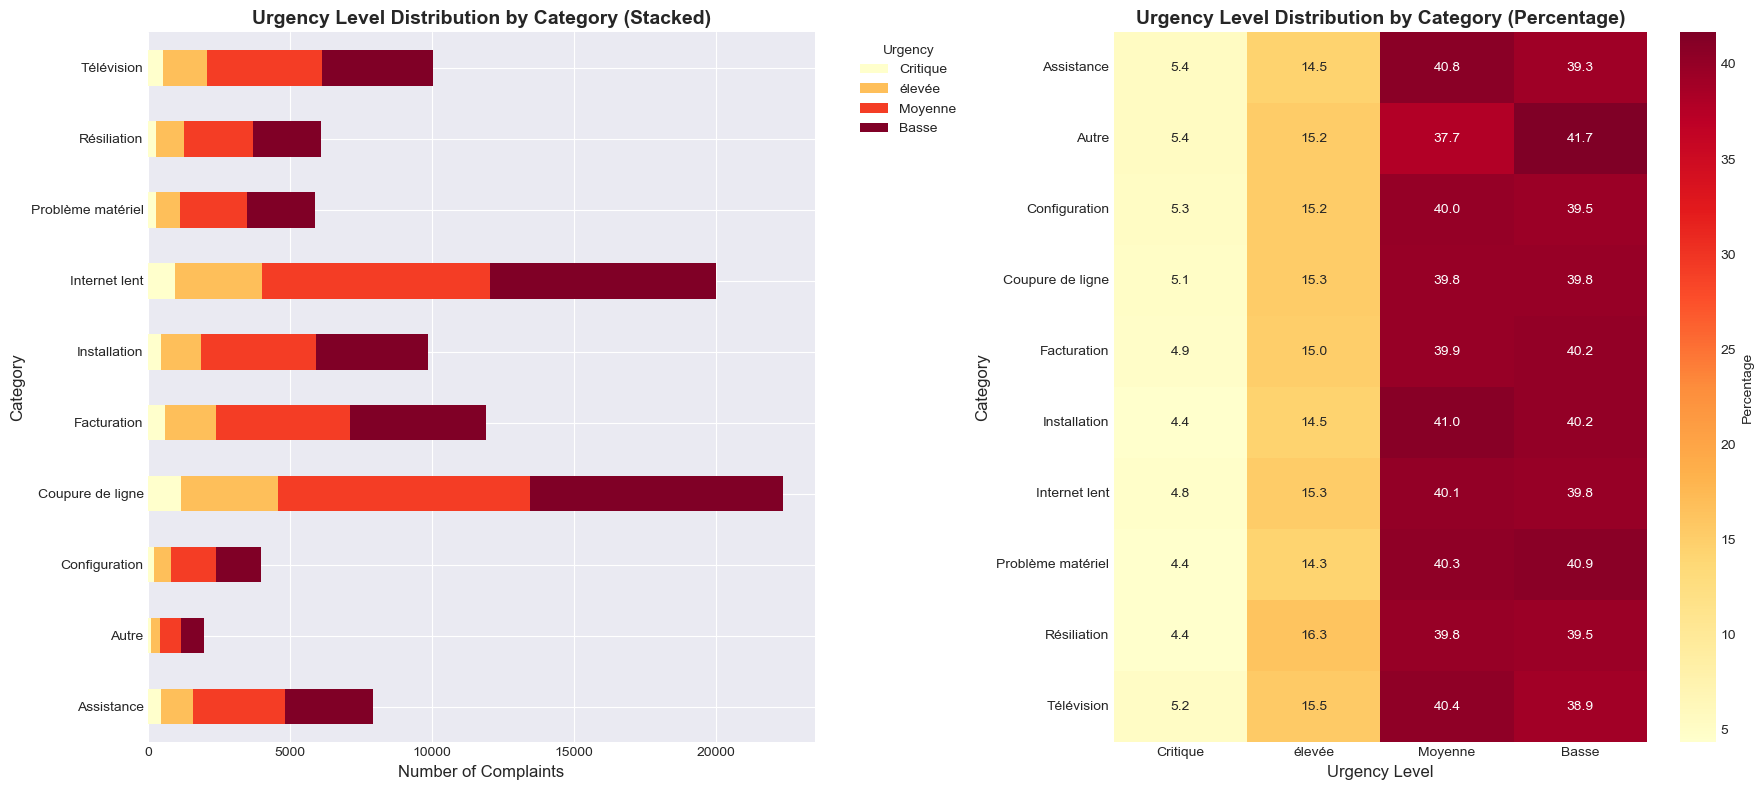


Count Distribution:
urgence            Critique  élevée  Moyenne  Basse
categorie                                          
Assistance              427    1145     3228   3108
Autre                   106     299      742    819
Configuration           209     602     1581   1562
Coupure de ligne       1135    3419     8912   8909
Facturation             586    1785     4741   4779
Installation            430    1432     4045   3964
Internet lent           952    3061     8039   7982
Problème matériel       261     840     2372   2406
Résiliation             270     994     2427   2410
Télévision              518    1554     4049   3900


Percentage Distribution:
urgence            Critique  élevée  Moyenne  Basse
categorie                                          
Assistance              5.4    14.5     40.8   39.3
Autre                   5.4    15.2     37.7   41.7
Configuration           5.3    15.2     40.0   39.5
Coupure de ligne        5.1    15.3     39.8   39.8
Facturation     

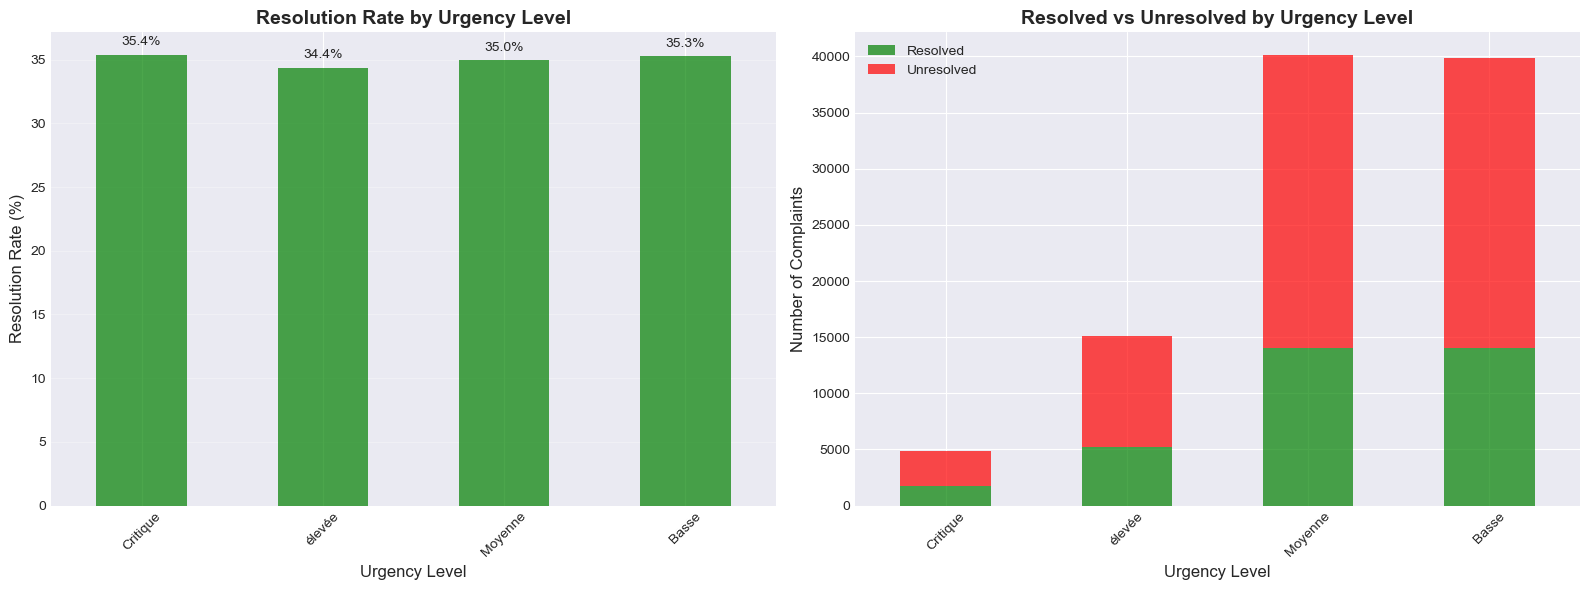


Resolution Statistics by Urgency:
          Total_Complaints  Resolved_Count  Resolution_Rate  Unresolved_Count
urgence                                                                      
Critique              4894            1731            35.37              3163
élevée               15131            5198            34.35              9933
Moyenne              40136           14027            34.95             26109
Basse                39839           14047            35.26             25792


3. URGENCY VS RESOLUTION CORRELATION ANALYSIS:
------------------------------------------------------------
Correlation between Urgency Score and Resolution: -0.0041

Urgency Score vs Resolution Rate:
          Urgency_Score  Resolution_Rate  Count
urgence                                        
Critique              4         0.353698   4894
élevée                3         0.343533  15131
Moyenne               2         0.349487  40136
Basse                 1         0.352594  39839


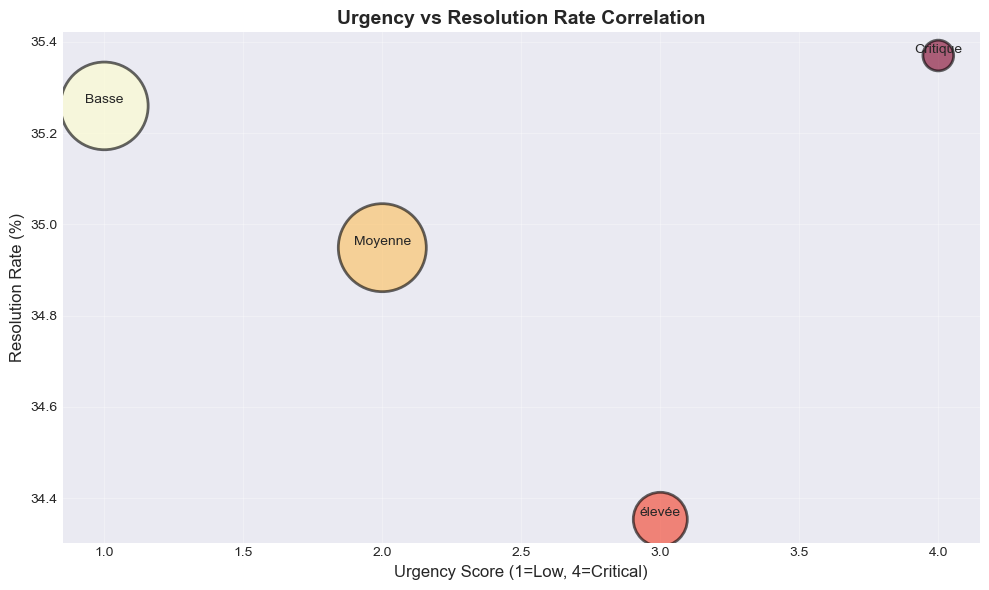



4. RESOLUTION RATE TRENDS OVER TIME:
------------------------------------------------------------


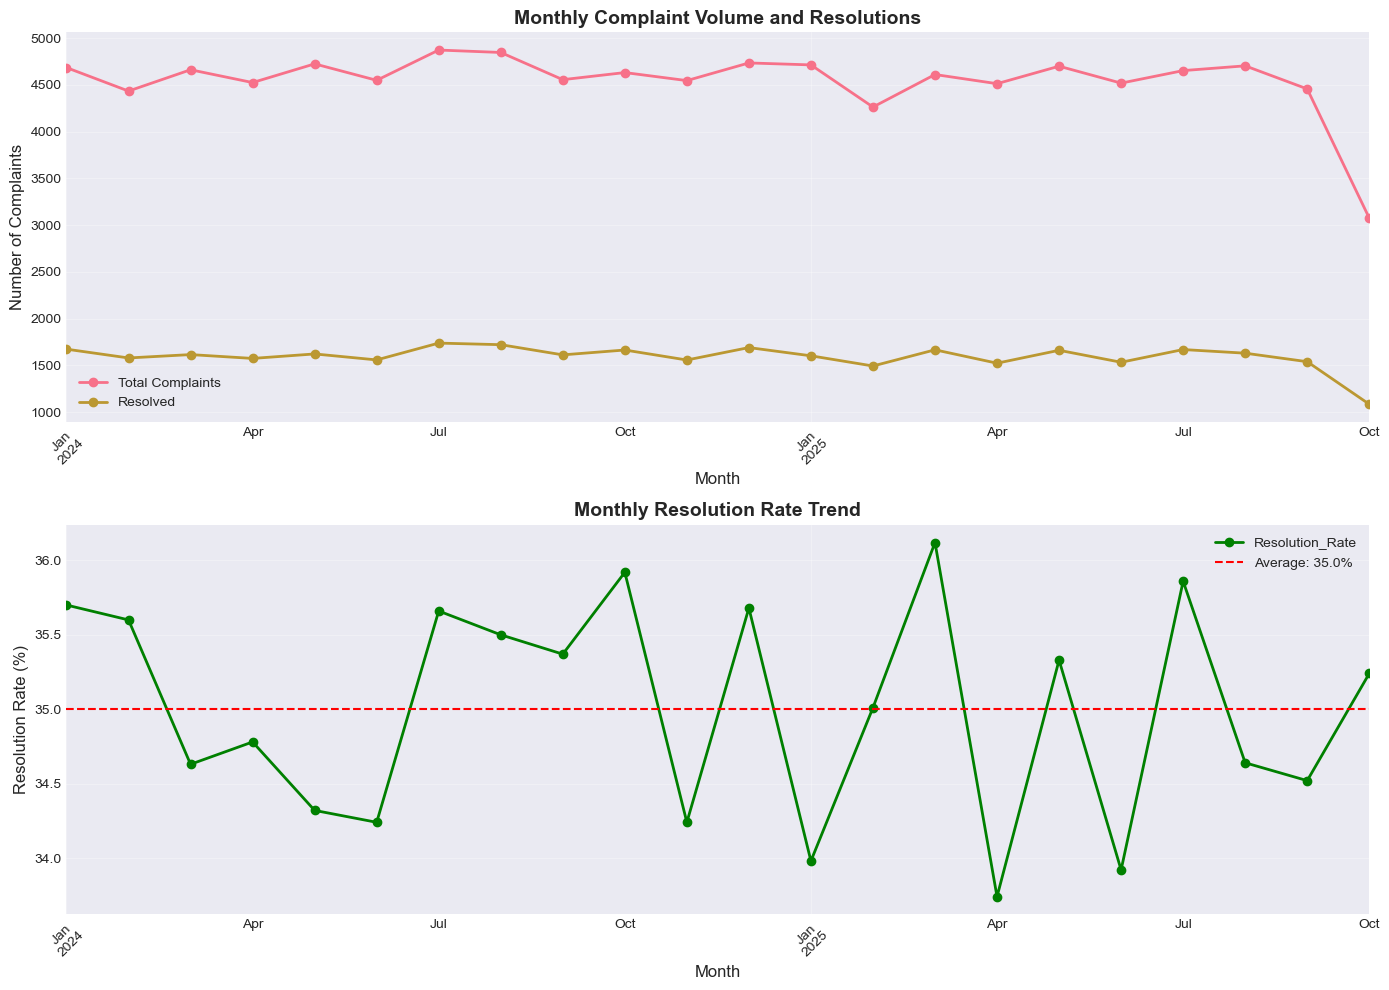


Monthly Resolution Statistics:
         Total  Resolved  Resolution_Rate
month                                    
2024-01   4686      1673            35.70
2024-02   4435      1579            35.60
2024-03   4663      1615            34.63
2024-04   4526      1574            34.78
2024-05   4726      1622            34.32
2024-06   4550      1558            34.24
2024-07   4874      1738            35.66
2024-08   4848      1721            35.50
2024-09   4557      1612            35.37
2024-10   4633      1664            35.92
2024-11   4547      1557            34.24
2024-12   4736      1690            35.68
2025-01   4715      1602            33.98
2025-02   4264      1493            35.01
2025-03   4612      1666            36.12
2025-04   4514      1523            33.74
2025-05   4701      1661            35.33
2025-06   4520      1533            33.92
2025-07   4654      1669            35.86
2025-08   4705      1630            34.64
2025-09   4458      1539            34.52
20

In [29]:
# === MISSING FEATURE 4: Urgency and Resolution Pattern Insights ===
# Detailed analysis of urgency and resolution patterns

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 80)
print("URGENCY AND RESOLUTION PATTERN INSIGHTS")
print("=" * 80)

# Ensure date is datetime
if "date" in df.columns and not np.issubdtype(df["date"].dtype, np.datetime64):
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 1. Urgency level distribution by category
print("\n1. URGENCY LEVEL DISTRIBUTION BY CATEGORY:")
print("-" * 60)
if "categorie" in df.columns and "urgence" in df.columns:
    urgency_order = ["Critique", "élevée", "Moyenne", "Basse"]
    category_urgency = pd.crosstab(df["categorie"], df["urgence"])
    category_urgency = category_urgency.reindex(columns=urgency_order, fill_value=0)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Stacked bar chart
    category_urgency.plot(kind="barh", stacked=True, ax=axes[0], colormap="YlOrRd")
    axes[0].set_title("Urgency Level Distribution by Category (Stacked)", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Number of Complaints", fontsize=12)
    axes[0].set_ylabel("Category", fontsize=12)
    axes[0].legend(title="Urgency", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    # Percentage heatmap
    category_urgency_pct = pd.crosstab(df["categorie"], df["urgence"], normalize="index") * 100
    category_urgency_pct = category_urgency_pct.reindex(columns=urgency_order, fill_value=0)
    sns.heatmap(category_urgency_pct, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "Percentage"})
    axes[1].set_title("Urgency Level Distribution by Category (Percentage)", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Urgency Level", fontsize=12)
    axes[1].set_ylabel("Category", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\nCount Distribution:")
    print(category_urgency.to_string())
    print("\n\nPercentage Distribution:")
    print(category_urgency_pct.round(1).to_string())

# 2. Resolution rate by urgency level
print("\n\n2. RESOLUTION RATE BY URGENCY LEVEL:")
print("-" * 60)
if "urgence" in df.columns and "status" in df.columns:
    is_resolved = df["status"].astype(str).str.strip().str.lower().eq("résolu")
    urgency_resolution = df.groupby("urgence").agg(
        Total_Complaints=("urgence", "size"),
        Resolved_Count=("status", lambda x: is_resolved[x.index].sum()),
    )
    urgency_resolution["Resolution_Rate"] = (urgency_resolution["Resolved_Count"] / urgency_resolution["Total_Complaints"] * 100).round(2)
    urgency_resolution["Unresolved_Count"] = urgency_resolution["Total_Complaints"] - urgency_resolution["Resolved_Count"]
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Resolution rate bar chart
    urgency_order = ["Critique", "élevée", "Moyenne", "Basse"]
    urgency_resolution_ordered = urgency_resolution.reindex(urgency_order)
    urgency_resolution_ordered["Resolution_Rate"].plot(kind="bar", ax=axes[0], color="green", alpha=0.7)
    axes[0].set_title("Resolution Rate by Urgency Level", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Urgency Level", fontsize=12)
    axes[0].set_ylabel("Resolution Rate (%)", fontsize=12)
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(axis="y", alpha=0.3)
    for i, v in enumerate(urgency_resolution_ordered["Resolution_Rate"]):
        axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", va="bottom")
    
    # Stacked bar: Resolved vs Unresolved
    urgency_resolution_ordered[["Resolved_Count", "Unresolved_Count"]].plot(kind="bar", stacked=True, ax=axes[1], 
                                                                           color=["green", "red"], alpha=0.7)
    axes[1].set_title("Resolved vs Unresolved by Urgency Level", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Urgency Level", fontsize=12)
    axes[1].set_ylabel("Number of Complaints", fontsize=12)
    axes[1].legend(["Resolved", "Unresolved"])
    axes[1].tick_params(axis="x", rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\nResolution Statistics by Urgency:")
    print(urgency_resolution_ordered.to_string())

# 3. Urgency vs Resolution correlation analysis
print("\n\n3. URGENCY VS RESOLUTION CORRELATION ANALYSIS:")
print("-" * 60)
if "urgence" in df.columns and "status" in df.columns:
    # Create urgency score (numeric)
    urgency_score_map = {"Critique": 4, "élevée": 3, "Moyenne": 2, "Basse": 1}
    df["urgency_score"] = df["urgence"].map(urgency_score_map)
    df["is_resolved"] = is_resolved.astype(int)
    
    # Correlation
    correlation = df["urgency_score"].corr(df["is_resolved"])
    print(f"Correlation between Urgency Score and Resolution: {correlation:.4f}")
    
    # Grouped analysis
    urgency_resolution_corr = df.groupby("urgence").agg(
        Urgency_Score=("urgency_score", "first"),
        Resolution_Rate=("is_resolved", "mean"),
        Count=("urgence", "size")
    ).sort_values("Urgency_Score", ascending=False)
    
    print("\nUrgency Score vs Resolution Rate:")
    print(urgency_resolution_corr.to_string())
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(urgency_resolution_corr["Urgency_Score"], urgency_resolution_corr["Resolution_Rate"] * 100,
               s=urgency_resolution_corr["Count"] / 10, alpha=0.6, c=urgency_resolution_corr["Urgency_Score"], 
               cmap="YlOrRd", edgecolors="black", linewidth=2)
    for idx, row in urgency_resolution_corr.iterrows():
        ax.annotate(idx, (row["Urgency_Score"], row["Resolution_Rate"] * 100), 
                   fontsize=10, ha="center", va="bottom")
    ax.set_xlabel("Urgency Score (1=Low, 4=Critical)", fontsize=12)
    ax.set_ylabel("Resolution Rate (%)", fontsize=12)
    ax.set_title("Urgency vs Resolution Rate Correlation", fontsize=14, fontweight="bold")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 4. Resolution rate trends over time (if date available)
print("\n\n4. RESOLUTION RATE TRENDS OVER TIME:")
print("-" * 60)
if "date" in df.columns and "status" in df.columns:
    df["month"] = df["date"].dt.to_period("M")
    monthly_resolution = df.groupby("month").agg(
        Total=("status", "size"),
        Resolved=("status", lambda x: is_resolved[x.index].sum())
    )
    monthly_resolution["Resolution_Rate"] = (monthly_resolution["Resolved"] / monthly_resolution["Total"] * 100).round(2)
    
    # Visualization
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Volume trend
    monthly_resolution[["Total", "Resolved"]].plot(kind="line", ax=axes[0], marker="o", linewidth=2)
    axes[0].set_title("Monthly Complaint Volume and Resolutions", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Month", fontsize=12)
    axes[0].set_ylabel("Number of Complaints", fontsize=12)
    axes[0].legend(["Total Complaints", "Resolved"])
    axes[0].grid(alpha=0.3)
    axes[0].tick_params(axis="x", rotation=45)
    
    # Resolution rate trend
    monthly_resolution["Resolution_Rate"].plot(kind="line", ax=axes[1], marker="o", color="green", linewidth=2)
    axes[1].set_title("Monthly Resolution Rate Trend", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Month", fontsize=12)
    axes[1].set_ylabel("Resolution Rate (%)", fontsize=12)
    axes[1].grid(alpha=0.3)
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].axhline(y=monthly_resolution["Resolution_Rate"].mean(), color="red", linestyle="--", 
                   label=f"Average: {monthly_resolution['Resolution_Rate'].mean():.1f}%")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\nMonthly Resolution Statistics:")
    print(monthly_resolution.to_string())

# 5. Category urgency patterns summary
print("\n\n5. CATEGORY URGENCY PATTERNS SUMMARY:")
print("-" * 60)
if "categorie" in df.columns and "urgence" in df.columns:
    category_urgency_summary = df.groupby("categorie").agg(
        Total=("categorie", "size"),
        Critical_Count=("urgence", lambda x: (x == "Critique").sum()),
        High_Count=("urgence", lambda x: (x == "élevée").sum()),
        Critical_High_Rate=("urgence", lambda x: (x.isin(["Critique", "élevée"])).mean() * 100)
    ).round(2)
    category_urgency_summary = category_urgency_summary.sort_values("Critical_High_Rate", ascending=False)
    
    print("\nCategories Ranked by Critical/High Urgency Rate:")
    print(category_urgency_summary.to_string())


In [30]:
# === MISSING FEATURE 5: Multi-Dimensional Grouping Tables ===
# Group complaints by multiple dimensions simultaneously to detect complex patterns

import pandas as pd
import numpy as np

print("=" * 80)
print("MULTI-DIMENSIONAL GROUPING ANALYSIS")
print("=" * 80)

# 1. Category × Region × Sentiment grouping
print("\n1. CATEGORY × REGION × SENTIMENT GROUPING (Top Combinations):")
print("-" * 60)
if all(col in df.columns for col in ["categorie", "wilaya", "sentiment"]):
    # Get top 5 categories and top 10 regions for manageable output
    top_cats = df["categorie"].value_counts().head(5).index.tolist()
    top_regions = df["wilaya"].value_counts().head(10).index.tolist()
    
    cat_region_sentiment = (
        df[df["categorie"].isin(top_cats) & df["wilaya"].isin(top_regions)]
        .groupby(["categorie", "wilaya", "sentiment"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    
    print("\nTop 20 Combinations:")
    print(cat_region_sentiment.head(20).to_string(index=False))
    
    # Summary pivot table
    cat_region_sentiment_pivot = (
        cat_region_sentiment.pivot_table(
            index=["categorie", "wilaya"],
            columns="sentiment",
            values="count",
            fill_value=0
        )
    )
    print("\n\nPivot Table (Category × Region × Sentiment):")
    print(cat_region_sentiment_pivot.head(15).to_string())

# 2. Category × Channel × Urgency grouping
print("\n\n2. CATEGORY × CHANNEL × URGENCY GROUPING:")
print("-" * 60)
if all(col in df.columns for col in ["categorie", "canal", "urgence"]):
    # Get top 5 categories
    top_cats = df["categorie"].value_counts().head(5).index.tolist()
    
    cat_channel_urgency = (
        df[df["categorie"].isin(top_cats)]
        .groupby(["categorie", "canal", "urgence"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    
    print("\nTop 20 Combinations:")
    print(cat_channel_urgency.head(20).to_string(index=False))
    
    # Summary pivot table
    cat_channel_urgency_pivot = (
        cat_channel_urgency.pivot_table(
            index=["categorie", "canal"],
            columns="urgence",
            values="count",
            fill_value=0
        )
    )
    print("\n\nPivot Table (Category × Channel × Urgency):")
    print(cat_channel_urgency_pivot.to_string())

# 3. Status × Urgency × Category grouping
print("\n\n3. STATUS × URGENCY × CATEGORY GROUPING:")
print("-" * 60)
if all(col in df.columns for col in ["status", "urgence", "categorie"]):
    # Get top 5 categories
    top_cats = df["categorie"].value_counts().head(5).index.tolist()
    
    status_urgency_cat = (
        df[df["categorie"].isin(top_cats)]
        .groupby(["status", "urgence", "categorie"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    
    print("\nTop 20 Combinations:")
    print(status_urgency_cat.head(20).to_string(index=False))
    
    # Focus on resolved vs unresolved
    print("\n\nResolved vs Unresolved by Urgency and Category:")
    is_resolved = df["status"].astype(str).str.strip().str.lower().eq("résolu")
    df["resolution_status"] = is_resolved.map({True: "Resolved", False: "Unresolved"})
    
    resolved_urgency_cat = (
        df[df["categorie"].isin(top_cats)]
        .groupby(["resolution_status", "urgence", "categorie"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    print(resolved_urgency_cat.head(20).to_string(index=False))

# 4. Region × Channel × Sentiment grouping
print("\n\n4. REGION × CHANNEL × SENTIMENT GROUPING (Top Combinations):")
print("-" * 60)
if all(col in df.columns for col in ["wilaya", "canal", "sentiment"]):
    # Get top 10 regions
    top_regions = df["wilaya"].value_counts().head(10).index.tolist()
    
    region_channel_sentiment = (
        df[df["wilaya"].isin(top_regions)]
        .groupby(["wilaya", "canal", "sentiment"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    
    print("\nTop 20 Combinations:")
    print(region_channel_sentiment.head(20).to_string(index=False))
    
    # Summary by region and channel
    region_channel_summary = (
        region_channel_sentiment.groupby(["wilaya", "canal"])
        .agg(Total=("count", "sum"), Negative_Count=("count", lambda x: 
             region_channel_sentiment.loc[x.index[region_channel_sentiment.loc[x.index, "sentiment"] == "Négatif"], "count"].sum() if len(x) > 0 else 0))
        .reset_index()
    )
    # Fix the negative count calculation
    region_channel_summary = (
        region_channel_sentiment[region_channel_sentiment["sentiment"] == "Négatif"]
        .groupby(["wilaya", "canal"])["count"].sum()
        .reset_index(name="Negative_Count")
        .merge(
            region_channel_sentiment.groupby(["wilaya", "canal"])["count"].sum().reset_index(name="Total"),
            on=["wilaya", "canal"]
        )
    )
    region_channel_summary["Negative_Rate"] = (region_channel_summary["Negative_Count"] / region_channel_summary["Total"] * 100).round(1)
    print("\n\nSummary by Region and Channel (with Negative Sentiment Rate):")
    print(region_channel_summary.sort_values("Negative_Rate", ascending=False).head(15).to_string(index=False))

# 5. Category × Urgency × Status grouping (Priority Matrix)
print("\n\n5. CATEGORY × URGENCY × STATUS GROUPING (Priority Matrix):")
print("-" * 60)
if all(col in df.columns for col in ["categorie", "urgence", "status"]):
    # Focus on critical/high urgency and unresolved
    is_critical_high = df["urgence"].isin(["Critique", "élevée"])
    is_unresolved = ~is_resolved
    
    priority_matrix = (
        df[is_critical_high & is_unresolved]
        .groupby(["categorie", "urgence", "status"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    
    print("\nCritical/High Urgency Unresolved Complaints:")
    print(priority_matrix.head(20).to_string(index=False))
    
    # Summary by category
    priority_summary = (
        priority_matrix.groupby("categorie")
        .agg(Total_Unresolved_Critical=("count", "sum"))
        .sort_values("Total_Unresolved_Critical", ascending=False)
    )
    print("\n\nTotal Unresolved Critical/High Urgency by Category:")
    print(priority_summary.to_string())

print("\n" + "=" * 80)
print("Multi-dimensional grouping analysis complete!")
print("=" * 80)


MULTI-DIMENSIONAL GROUPING ANALYSIS

1. CATEGORY × REGION × SENTIMENT GROUPING (Top Combinations):
------------------------------------------------------------

Top 20 Combinations:
       categorie     wilaya sentiment  count
Coupure de ligne      Jijel   Négatif    539
Coupure de ligne     Béjaïa   Négatif    522
Coupure de ligne     Annaba   Négatif    517
Coupure de ligne       Oran   Négatif    504
Coupure de ligne Mostaganem   Négatif    504
Coupure de ligne     Biskra   Négatif    501
Coupure de ligne      Blida   Négatif    499
Coupure de ligne   Laghouat   Négatif    498
   Internet lent      Jijel   Négatif    497
   Internet lent     Biskra   Négatif    492
Coupure de ligne Tizi Ouzou   Négatif    492
Coupure de ligne      Batna   Négatif    489
   Internet lent       Oran   Négatif    463
   Internet lent      Batna   Négatif    460
   Internet lent Mostaganem   Négatif    454
   Internet lent Tizi Ouzou   Négatif    452
   Internet lent      Blida   Négatif    445
   Inter

# PHASE 7: Multi-Dimensional Grouping
- Resolution path counts (category → suggested action)

STRATEGIC GROUPING ANALYSIS FOR SUPPORT OPTIMIZATION

1. CATEGORIES BY URGENCY (Priority Ranking):
------------------------------------------------------------
urgence            Critique  élevée  Moyenne  Basse  Total  Critique_Rate
categorie                                                                
Assistance              427    1145     3228   3108   7908            5.4
Autre                   106     299      742    819   1966            5.4
Configuration           209     602     1581   1562   3954            5.3
Télévision              518    1554     4049   3900  10021            5.2
Coupure de ligne       1135    3419     8912   8909  22375            5.1
Facturation             586    1785     4741   4779  11891            4.9
Internet lent           952    3061     8039   7982  20034            4.8
Installation            430    1432     4045   3964   9871            4.4
Problème matériel       261     840     2372   2406   5879            4.4
Résiliation             27

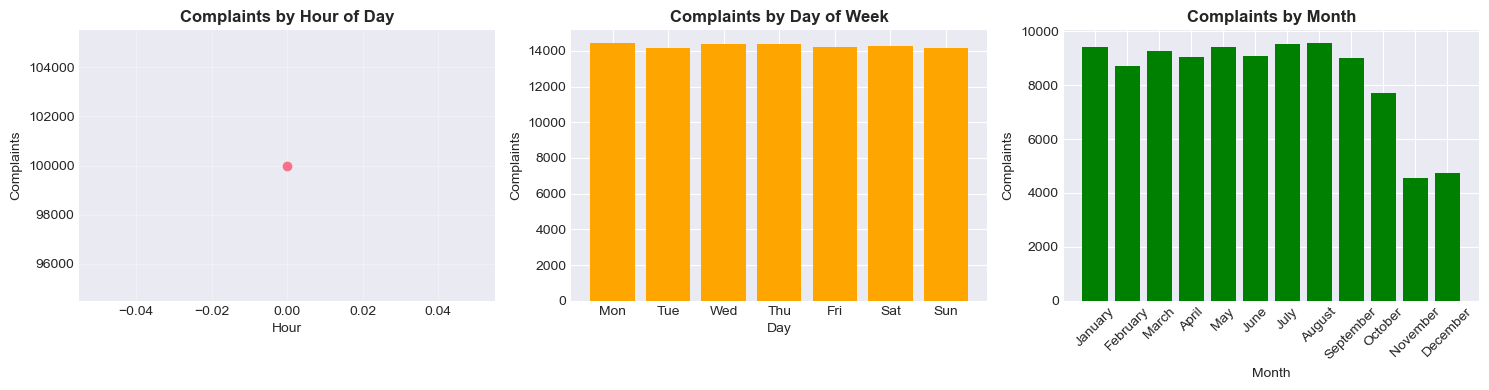

In [31]:
# === C1: Strategic Grouping Analysis ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STRATEGIC GROUPING ANALYSIS FOR SUPPORT OPTIMIZATION")
print("=" * 70)

# Defensive datetime conversion (Phase C is before Phase 3; Phase 2 already converts, but be safe)
if "date" in df.columns and not np.issubdtype(df["date"].dtype, np.datetime64):
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Helper flags
if "urgence" in df.columns:
    is_critical = df["urgence"].astype(str).isin(["Critique", "élevée"])
else:
    is_critical = pd.Series(False, index=df.index)

if "status" in df.columns:
    is_resolved = df["status"].astype(str).str.strip().str.lower().eq("résolu")
else:
    is_resolved = pd.Series(False, index=df.index)

if "sentiment" in df.columns:
    is_negative = df["sentiment"].astype(str).str.strip().str.lower().eq("négatif")
else:
    is_negative = pd.Series(False, index=df.index)

# 1) Category-Urgency Priority Matrix
if "categorie" in df.columns and "urgence" in df.columns:
    category_urgency_matrix = pd.crosstab(df["categorie"], df["urgence"])
    category_urgency_matrix["Total"] = category_urgency_matrix.sum(axis=1)
    if "Critique" in category_urgency_matrix.columns:
        category_urgency_matrix["Critique_Rate"] = (
            category_urgency_matrix["Critique"] / category_urgency_matrix["Total"] * 100
        ).round(1)
    else:
        category_urgency_matrix["Critique_Rate"] = np.nan
    category_urgency_matrix = category_urgency_matrix.sort_values("Critique_Rate", ascending=False)

    print("\n1. CATEGORIES BY URGENCY (Priority Ranking):")
    print("-" * 60)
    cols = [c for c in ["Critique", "élevée", "Moyenne", "Basse", "Total", "Critique_Rate"] if c in category_urgency_matrix.columns]
    print(category_urgency_matrix[cols].to_string())
else:
    category_urgency_matrix = None
    print("\n1. Skipping category urgency matrix (missing 'categorie' or 'urgence').")

# 2) Regional Hotspot Analysis
if "wilaya" in df.columns:
    regional_analysis = (
        df.assign(_critical=is_critical, _resolved=is_resolved)
          .groupby("wilaya")
          .agg(
              Total_Complaints=("wilaya", "size"),
              Critical_Rate_pct=("_critical", lambda x: float(x.mean() * 100)),
              Resolution_Rate_pct=("_resolved", lambda x: float(x.mean() * 100)),
          )
          .round(1)
          .sort_values("Total_Complaints", ascending=False)
    )

    print("\n\n2. REGIONAL PERFORMANCE ANALYSIS (Top 10 by volume):")
    print("-" * 60)
    print(regional_analysis.head(10).to_string())
else:
    regional_analysis = None
    print("\n\n2. Skipping regional analysis (missing 'wilaya').")

# 3) Channel Effectiveness Analysis
if "canal" in df.columns:
    channel_analysis = (
        df.assign(_critical=is_critical, _resolved=is_resolved, _negative=is_negative)
          .groupby("canal")
          .agg(
              Volume=("canal", "size"),
              Critical_pct=("_critical", lambda x: float(x.mean() * 100)),
              Resolution_pct=("_resolved", lambda x: float(x.mean() * 100)),
              Negative_pct=("_negative", lambda x: float(x.mean() * 100)),
          )
          .round(1)
          .sort_values("Volume", ascending=False)
    )

    print("\n\n3. CHANNEL EFFECTIVENESS ANALYSIS:")
    print("-" * 60)
    print(channel_analysis.to_string())
else:
    channel_analysis = None
    print("\n\n3. Skipping channel analysis (missing 'canal').")

# 4) Time-Based Patterns
if "date" in df.columns:
    df["hour"] = df["date"].dt.hour
    df["day_of_week"] = df["date"].dt.day_name()
    df["month_name"] = df["date"].dt.month_name()

    hourly_pattern = df.groupby("hour").size()
    daily_pattern = df.groupby("day_of_week").size()
    monthly_pattern = df.groupby("month_name").size()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(hourly_pattern.index, hourly_pattern.values, marker="o", linewidth=2)
    axes[0].set_title("Complaints by Hour of Day", fontweight="bold")
    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Complaints")
    axes[0].grid(True, alpha=0.3)

    daily_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    axes[1].bar(range(len(daily_order)), daily_pattern.reindex(daily_order).fillna(0), color="orange")
    axes[1].set_title("Complaints by Day of Week", fontweight="bold")
    axes[1].set_xlabel("Day")
    axes[1].set_ylabel("Complaints")
    axes[1].set_xticks(range(len(daily_order)))
    axes[1].set_xticklabels([d[:3] for d in daily_order])

    # Order months explicitly
    month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
    monthly_pattern = monthly_pattern.reindex(month_order).fillna(0)
    axes[2].bar(monthly_pattern.index, monthly_pattern.values, color="green")
    axes[2].set_title("Complaints by Month", fontweight="bold")
    axes[2].set_xlabel("Month")
    axes[2].set_ylabel("Complaints")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()
else:
    hourly_pattern = daily_pattern = monthly_pattern = None
    print("\n\n4. Skipping time patterns (missing 'date').")

In [32]:
# === C2: Pattern Detection Tables ===
import pandas as pd
import numpy as np

print("=" * 70)
print("KEY PATTERN DETECTION TABLES")
print("=" * 70)

# 1) Most common complaint chains (Category → Suggested Action)
if "categorie" in df.columns and "suggested_action" in df.columns:
    print("\n1. MOST COMMON RESOLUTION PATHS (Category → Suggested Action):")
    print("-" * 60)
    resolution_paths = df.groupby(["categorie", "suggested_action"]).size().reset_index(name="count")
    top_paths = resolution_paths.nlargest(15, "count")
    print(top_paths.to_string(index=False))
else:
    print("\n1. Skipping resolution paths (missing 'categorie' or 'suggested_action').")

# 2) Regional specialization (top category per region)
if "wilaya" in df.columns and "categorie" in df.columns:
    print("\n\n2. REGIONAL SPECIALIZATION (Top Category per Region):")
    print("-" * 60)
    specialization_df = (
        df.groupby(["wilaya", "categorie"]).size().reset_index(name="count")
          .sort_values(["wilaya", "count"], ascending=[True, False])
          .groupby("wilaya").head(1)
          .assign(pct_of_region=lambda d: (d["count"] / d.groupby("wilaya")["count"].transform("sum") * 100).round(1))
    )
    # Note: pct_of_region above would be 100% due to head(1) unless we compute totals separately; do it correctly:
    totals = df.groupby("wilaya").size().rename("region_total")
    specialization_df = specialization_df.merge(totals, left_on="wilaya", right_index=True)
    specialization_df["pct_of_region"] = (specialization_df["count"] / specialization_df["region_total"] * 100).round(1)
    specialization_df = specialization_df.drop(columns=["region_total"])
    print(specialization_df.sort_values("count", ascending=False).head(15).to_string(index=False))
else:
    print("\n\n2. Skipping regional specialization (missing 'wilaya' or 'categorie').")

# 3) Seasonal patterns by category (month_name must exist; otherwise derive from date)
if "date" in df.columns and "categorie" in df.columns:
    if "month_name" not in df.columns:
        df["month_name"] = df["date"].dt.month_name()
    print("\n\n3. SEASONAL PATTERNS BY CATEGORY (peaks):")
    print("-" * 60)
    monthly_category = pd.crosstab(df["month_name"], df["categorie"], normalize="index") * 100
    month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
    monthly_category = monthly_category.reindex(month_order)

    # Highlight categories with notable peaks
    for category in monthly_category.columns:
        series = monthly_category[category].dropna()
        if series.empty:
            continue
        if series.std() > 5:
            peak_month = series.idxmax()
            peak_value = series.max()
            avg_value = series.mean()
            if avg_value > 0 and peak_value > avg_value * 1.2:
                print(f"{category}: peaks in {peak_month} ({peak_value:.1f}% vs avg {avg_value:.1f}%)")
else:
    print("\n\n3. Skipping seasonal patterns (missing 'date' or 'categorie').")

KEY PATTERN DETECTION TABLES

1. MOST COMMON RESOLUTION PATHS (Category → Suggested Action):
------------------------------------------------------------
       categorie         suggested_action  count
Coupure de ligne         Envoi technicien   5533
   Internet lent         Envoi technicien   4870
Coupure de ligne     Redémarrage du modem   4486
   Internet lent     Redémarrage du modem   3981
Coupure de ligne Vérification facturation   3339
   Internet lent Vérification facturation   3118
     Facturation         Envoi technicien   2883
      Télévision         Envoi technicien   2541
    Installation         Envoi technicien   2417
     Facturation     Redémarrage du modem   2375
Coupure de ligne        Vérifier décodeur   2251
      Télévision     Redémarrage du modem   2037
    Installation     Redémarrage du modem   2002
   Internet lent        Vérifier décodeur   1975
      Assistance         Envoi technicien   1917


2. REGIONAL SPECIALIZATION (Top Category per Region):
------

# PHASE 6: Clustering Analysis

In [33]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer

svd_pipeline = Pipeline(
    steps=[
        ("svd", TruncatedSVD(n_components=100, random_state=42)),
        ("norm", Normalizer(copy=False))
    ]
)

X_svd = svd_pipeline.fit_transform(X_text_tfidf)

X_svd.shape


(100000, 100)

In [34]:
import numpy as np

explained_variance = svd_pipeline.named_steps["svd"].explained_variance_ratio_
print(f"Total explained variance: {np.sum(explained_variance):.2%}")


Total explained variance: 100.00%


In [35]:
# K-Means Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [5, 8, 10, 12, 15]
results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_svd)
    
    # LIMIT SAMPLE SIZE TO 10,000 or 5,000
    sil = silhouette_score(X_svd, labels, metric="cosine", sample_size=10000)
    
    results.append((k, kmeans.inertia_, sil))
    print(f"k={k} completed. Inertia: {kmeans.inertia_:.2f}, Sil: {sil:.4f}")

results

k=5 completed. Inertia: 61170.47, Sil: 0.3622
k=8 completed. Inertia: 40732.80, Sil: 0.5695
k=10 completed. Inertia: 27868.85, Sil: 0.7064
k=12 completed. Inertia: 25987.34, Sil: 0.6573
k=15 completed. Inertia: 23061.91, Sil: 0.6533


[(5, 61170.46888254206, 0.36217389574279135),
 (8, 40732.797379818774, 0.5695413560318504),
 (10, 27868.854836183287, 0.7063844930902162),
 (12, 25987.343394537365, 0.6573150206017452),
 (15, 23061.914254472194, 0.6532943615931708)]

In [36]:
# K-Means Clustering
optimal_k = 10

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

df["kmeans_cluster"] = kmeans.fit_predict(X_svd)


In [37]:
df["kmeans_cluster"].value_counts().sort_index()


kmeans_cluster
0    10017
1    10066
2     9996
3    10034
4     9909
5    10048
6    10112
7     9989
8     9933
9     9896
Name: count, dtype: int64

In [38]:
import pandas as pd
import numpy as np

terms = tfidf_pipeline.named_steps["tfidf"].get_feature_names_out()
centroids = kmeans.cluster_centers_

top_terms = {}

for i in range(optimal_k):
    top_idx = centroids[i].argsort()[-10:][::-1]
    top_terms[i] = [terms[j] for j in top_idx]

pd.DataFrame.from_dict(top_terms, orient="index", columns=[f"term_{i}" for i in range(10)])


,term_0,term_1,term_2,term_3,term_4,term_5,term_6,term_7,term_8,term_9
0,assistance demande,abonné,assistance problème,assistance montant,demande assistance,demande,demande information,coupure service,figée,coupure
1,assistance,abonné,assistance image,assistance problème,assistance bruit,assistance coupure,figée certaines,assistance modem,bruit,authentification
2,abonné rapporte,abonné,assistance,assistance bruit,assistance problème,assistance coupure,assistance montant,assistance modem,image figée,important ligne
3,abonné,assistance problème,assistance montant,demande,demande information,coupure service,coupure,figée,bruit,continue
4,assistance image,abonné rapporte,abonné,assistance erreur,assistance,assistance montant,assistance problème,assistance bruit,continue,assistance coupure
5,assistance coupure,abonné,assistance montant,assistance problème,coupure service,assistance modem,coupure,demande information,figée,bruit
6,assistance bruit,abonné,assistance coupure,assistance problème,assistance montant,coupure,assistance modem,figée,continue,bruit
7,assistance débit,abonné,assistance demande,assistance problème,assistance montant,assistance modem,figée,coupure,coupure service,bruit
8,assistance erreur,abonné,assistance,assistance problème,facturation continue,assistance bruit,assistance coupure,facturé,figée,bruit
9,assistance installation,abonné,assistance montant,assistance erreur,assistance problème,assistance image,assistance débit,assistance demande,authentification,certaines


In [39]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

# 1. Take a random sample of 5,000 rows (sufficient for structure)
sample_indices = np.random.choice(X_svd.shape[0], size=5000, replace=False)
X_sample = X_svd[sample_indices]

# 2. Fit on the sample
agg = AgglomerativeClustering(
    n_clusters=10, 
    metric="cosine", 
    linkage="average"
)
sample_labels = agg.fit_predict(X_sample)

# 3. (Optional) If you absolutely need labels for ALL 100k rows, 
# you can use a NearestNeighbor classifier to propogate labels from the sample to the full dataset.
# But for just visualizing the dendrogram or testing, the sample is enough.

In [40]:
# K-Means Clustering
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# 1. Cluster a Sample (to avoid MemoryError)
sample_indices = np.random.choice(X_svd.shape[0], size=5000, replace=False)
X_sample = X_svd[sample_indices]

agg_sample = AgglomerativeClustering(n_clusters=10, metric="cosine", linkage="average")
y_sample_labels = agg_sample.fit_predict(X_sample)

# 2. Train a KNN to "learn" the clustering logic
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_sample, y_sample_labels)

# 3. Predict clusters for the FULL dataset
df["agg_cluster"] = knn.predict(X_svd)

# Now your comparison code will work:
pd.DataFrame({
    "KMeans": df["kmeans_cluster"].value_counts().sort_index(),
    "Agglomerative": df["agg_cluster"].value_counts().sort_index()
})

,KMeans,Agglomerative
0,10017,9896
1,10066,9933
2,9996,10112
3,10034,9909
4,9909,10017
5,10048,10048
6,10112,10034
7,9989,9989
8,9933,10066
9,9896,9996


In [41]:
# K-Means Clustering
from sklearn.metrics import silhouette_score

# Use a sample of 10,000 to get a result in seconds
sil_kmeans = silhouette_score(X_svd, df["kmeans_cluster"], metric="cosine", sample_size=10000)
sil_agg = silhouette_score(X_svd, df["agg_cluster"], metric="cosine", sample_size=10000)

print(f"KMeans Silhouette: {sil_kmeans:.4f}")
print(f"Agglomerative Silhouette: {sil_agg:.4f}")

KMeans Silhouette: 0.7055
Agglomerative Silhouette: 0.7053


In [42]:
for cluster_id in range(3):
    print(f"\n--- Agglomerative Cluster {cluster_id} ---")
    display(
        df[df["agg_cluster"] == cluster_id]["texte_reclamation"]
        .sample(5, random_state=42)
        .values
    )



--- Agglomerative Cluster 0 ---


array(['Client signale modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.',
       'Réclamation: modem ne se synchronise pas.',
       'Réclamation: modem ne se synchronise pas.',
       "Demande d'assistance: modem ne se synchronise pas."], dtype=object)


--- Agglomerative Cluster 1 ---


array(["Demande d'assistance: demande d'information sur l'offre et le contrat.",
       "Abonné rapporte demande d'information sur l'offre et le contrat.",
       "Client signale demande d'information sur l'offre et le contrat.",
       "Incident: demande d'information sur l'offre et le contrat.",
       "Client signale demande d'information sur l'offre et le contrat."],
      dtype=object)


--- Agglomerative Cluster 2 ---


array(["Demande d'assistance: image figée sur certaines chaines.",
       'Incident: image figée sur certaines chaines.',
       "Demande d'assistance: image figée sur certaines chaines.",
       "Demande d'assistance: image figée sur certaines chaines.",
       'Abonné rapporte image figée sur certaines chaines.'], dtype=object)

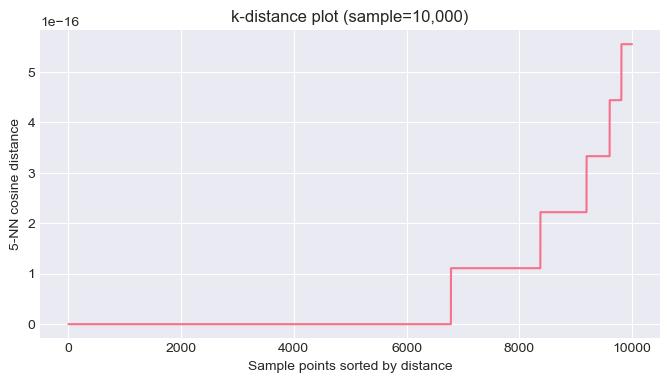

In [43]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# k-distance plot on a SAMPLE (much faster on large datasets)
neighbors = 5
sample_size = 10_000  # change to 5_000 if still slow

rng = np.random.default_rng(42)
n = X_svd.shape[0]
idx = rng.choice(n, size=min(sample_size, n), replace=False)
X_svd_sample = X_svd[idx]

# For cosine distance, brute force is typically used; n_jobs speeds up where supported
nbrs = NearestNeighbors(n_neighbors=neighbors, metric="cosine", algorithm="brute", n_jobs=-1)
nbrs.fit(X_svd_sample)
distances, _ = nbrs.kneighbors(X_svd_sample)

# Sort and plot distances to find elbow
k_dist = np.sort(distances[:, -1])
plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.title(f"k-distance plot (sample={len(X_svd_sample):,})")
plt.xlabel("Sample points sorted by distance")
plt.ylabel(f"{neighbors}-NN cosine distance")
plt.show()

In [44]:
# DBSCAN Clustering
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.1,         # adjust after observing k-distance plot
    min_samples=5,
    metric="cosine",
    n_jobs=-1
)

df["dbscan_cluster"] = dbscan.fit_predict(X_svd)


In [45]:
df["dbscan_cluster"].value_counts().sort_index()


dbscan_cluster
0     1922
1     1986
2     1944
3     2003
4     2004
5     2048
6     2076
7     2018
8     1991
9     2016
10    1992
11    1984
12    2001
13    1986
14    1984
15    1979
16    1996
17    2034
18    1993
19    2032
20    2009
21    2041
22    1877
23    1998
24    1968
25    1960
26    1922
27    2002
28    1997
29    1984
30    2016
31    2000
32    2033
33    2001
34    1935
35    2037
36    1997
37    2076
38    1992
39    1999
40    1995
41    2087
42    1985
43    2011
44    1984
45    2017
46    2050
47    2017
48    2026
49    1995
Name: count, dtype: int64

In [46]:
# DBSCAN Clustering
from sklearn.metrics import silhouette_score

# DBSCAN may have -1 labels; ignore them
mask = df["dbscan_cluster"] != -1
sil_dbscan = silhouette_score(X_svd[mask], df.loc[mask, "dbscan_cluster"], metric="cosine")
sil_dbscan


0.9999999999999999

In [47]:
%pip install hdbscan  
import hdbscan


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [48]:
import sys, sklearn
from importlib.metadata import version

print("Python:", sys.version)
print("Python exe:", sys.executable)
print("sklearn version:", sklearn.__version__)
print("sklearn path:", sklearn.__file__)
print("hdbscan version:", version("hdbscan"))

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
Python exe: c:\ProgramData\anaconda3\python.exe
sklearn version: 1.8.0
sklearn path: C:\Users\IT DOCTOR\AppData\Roaming\Python\Python312\site-packages\sklearn\__init__.py
hdbscan version: 0.8.41


In [49]:
# HDBSCAN (note: this sklearn build doesn't support BallTree metric='cosine')
# Since X_svd is normalized (via Normalizer), euclidean distance is a good proxy for cosine.
hdb = hdbscan.HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
    core_dist_n_jobs=-1,
 )

df["hdbscan_cluster"] = hdb.fit_predict(X_svd)
df["hdbscan_prob"] = hdb.probabilities_


In [50]:
df["hdbscan_cluster"].value_counts().sort_index()
df["hdbscan_cluster"].value_counts(normalize=True).sort_index()


hdbscan_cluster
0     0.01997
1     0.01996
2     0.02037
3     0.01995
4     0.01984
5     0.01984
6     0.02017
7     0.02033
8     0.02041
9     0.01986
10    0.01985
11    0.02002
12    0.02032
13    0.01944
14    0.02004
15    0.01992
16    0.01922
17    0.02034
18    0.01984
19    0.02076
20    0.02000
21    0.01999
22    0.01986
23    0.02048
24    0.02009
25    0.01992
26    0.01979
27    0.02016
28    0.01998
29    0.02017
30    0.02011
31    0.02026
32    0.01991
33    0.01993
34    0.01877
35    0.02087
36    0.02003
37    0.01968
38    0.02050
39    0.01984
40    0.02016
41    0.02001
42    0.01922
43    0.02001
44    0.01935
45    0.02076
46    0.01997
47    0.01960
48    0.02018
49    0.01995
Name: proportion, dtype: float64

In [51]:
mask = df["hdbscan_cluster"] != -1
sil_hdbscan = silhouette_score(X_svd[mask], df.loc[mask, "hdbscan_cluster"], metric="cosine")
sil_hdbscan


0.9999999999999999

In [52]:
# DBSCAN Clustering
for cluster_id in df["hdbscan_cluster"].unique()[:3]:
    if cluster_id == -1:
        continue
    print(f"\n--- HDBSCAN Cluster {cluster_id} ---")
    display(
        df[df["hdbscan_cluster"] == cluster_id]["texte_reclamation"]
        .sample(5, random_state=42)
        .values
    )



--- HDBSCAN Cluster 42 ---


array(['Incident: modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.',
       'Incident: modem ne se synchronise pas.'], dtype=object)


--- HDBSCAN Cluster 22 ---


array(['Client signale problème lors de la résiliation, facturation continue.',
       'Client signale problème lors de la résiliation, facturation continue.',
       'Client signale problème lors de la résiliation, facturation continue.',
       'Client signale problème lors de la résiliation, facturation continue.',
       'Client signale problème lors de la résiliation, facturation continue.'],
      dtype=object)


--- HDBSCAN Cluster 13 ---


array(["Demande d'assistance: bruit important sur la ligne téléphonique.",
       "Demande d'assistance: bruit important sur la ligne téléphonique.",
       "Demande d'assistance: bruit important sur la ligne téléphonique.",
       "Demande d'assistance: bruit important sur la ligne téléphonique.",
       "Demande d'assistance: bruit important sur la ligne téléphonique."],
      dtype=object)

# PHASE 6: Clustering Analysis (continued)
# GMM Clustering
**Output:** labels + membership probabilities

In [53]:
# GMM Clustering
from sklearn.mixture import GaussianMixture
import numpy as np

# Model selection with BIC (use a sample to keep it fast)
bic_scores = []
n_components_range = range(2, 16)

sample_size = 10_000
rng = np.random.default_rng(42)
idx = rng.choice(X_svd.shape[0], size=min(sample_size, X_svd.shape[0]), replace=False)
X_bic = X_svd[idx]

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type="full",
        random_state=42,
    )
    gmm.fit(X_bic)
    bic_scores.append(gmm.bic(X_bic))

list(zip(n_components_range, bic_scores))

[(2, -9289912.482556056),
 (3, -9754174.161556957),
 (4, -9916002.647094462),
 (5, -10266986.08808585),
 (6, -10431755.105797112),
 (7, -10690182.421608102),
 (8, -10849814.651722234),
 (9, -10909564.31700965),
 (10, -10972036.318035807),
 (11, -10955788.534078633),
 (12, -10935381.304626914),
 (13, -10880570.755429244),
 (14, -10850783.627812171),
 (15, -10815946.798571872)]

In [54]:
# GMM Clustering
from sklearn.metrics import silhouette_score

# Pick the n_components with lowest BIC (or set manually)
optimal_components = n_components_range[int(np.argmin(bic_scores))]
print("Chosen n_components (min BIC):", optimal_components)

gmm = GaussianMixture(
    n_components=optimal_components,
    covariance_type="full",
    random_state=42,
 )

df["gmm_cluster"] = gmm.fit_predict(X_svd)
df["gmm_max_prob"] = gmm.predict_proba(X_svd).max(axis=1)

print("GMM cluster sizes:")
display(df["gmm_cluster"].value_counts().sort_index())

# Silhouette (cosine is consistent with earlier evaluations)
sil_gmm = silhouette_score(X_svd, df["gmm_cluster"], metric="cosine", sample_size=10_000)
print("GMM silhouette (sampled):", sil_gmm)

# Soft-membership confidence
df["gmm_max_prob"].describe()

Chosen n_components (min BIC): 10
GMM cluster sizes:


gmm_cluster
0    10017
1    10066
2     9996
3    10034
4     9909
5    10048
6    10112
7     9989
8     9933
9     9896
Name: count, dtype: int64

GMM silhouette (sampled): 0.706005242976233


count    100000.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: gmm_max_prob, dtype: float64

# Topic Modeling (LDA/NMF)
- **NMF**: matrix factorization (often very interpretable on TF‑IDF)

In [55]:
# Topic Modeling - LDA
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# --- Helper to display top words per topic ---
def display_topics(model, feature_names, n_top_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[-n_top_words:][::-1]
        topics[topic_idx] = [feature_names[i] for i in top_idx]
    return pd.DataFrame.from_dict(topics, orient="index")

n_topics = 10

In [56]:
# --- LDA (use COUNT features) ---
count_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    stop_words=french_stop_words,
 )

X_counts = count_vectorizer.fit_transform(df[TEXT_FEATURE].fillna(""))
count_feature_names = count_vectorizer.get_feature_names_out()

lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method="batch",
    random_state=42,
 )

lda_doc_topics = lda.fit_transform(X_counts)

display_topics(lda, count_feature_names, n_top_words=10)

,0,1,2,3,4,5,6,7,8,9
0,modem synchronise,modem,synchronise,réclamation,réclamation problème,réclamation modem,lors,résiliation,problème lors,résiliation facturation
1,demande,information offre,information,demande information,offre contrat,offre,contrat,abonné rapporte,abonné,rapporte
2,coupure service,service depuis,matin,depuis matin,coupure,service,depuis,abonné rapporte,abonné,rapporte
3,soirée,faible soirée,faible,très,débit,très faible,débit très,client,client signale,signale
4,installation,réalisée délais,installation non,délais,non réalisée,réalisée,non,abonné rapporte,abonné,rapporte
5,lors,continue,facturation continue,lors résiliation,facturation,problème,résiliation facturation,problème lors,résiliation,incident
6,demande,facturé incorrectement,facturé,régularisation,incorrectement,montant facturé,montant,incorrectement demande,demande régularisation,assistance
7,figée certaines,certaines chaines,chaines,image figée,certaines,figée,image,signale,client,client signale
8,authentification lors,authentification,erreur,erreur authentification,connexion,lors connexion,lors,abonné rapporte,abonné,rapporte
9,ligne téléphonique,bruit important,important,téléphonique,important ligne,ligne,bruit,réclamation bruit,réclamation,incident


In [57]:
# Dominant topic per document (LDA)
df["lda_topic"] = lda_doc_topics.argmax(axis=1)
df["lda_topic"].value_counts().sort_index()

lda_topic
0     3923
1     9933
2     9989
3    10034
4    10017
5     9996
6    12034
7    10112
8    13914
9    10048
Name: count, dtype: int64

In [58]:
# --- NMF (use TF‑IDF features) ---
nmf = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvd",
 )

nmf_doc_topics = nmf.fit_transform(X_text_tfidf)
tfidf_feature_names = tfidf_pipeline.named_steps["tfidf"].get_feature_names_out()

display_topics(nmf, tfidf_feature_names, n_top_words=10)

,0,1,2,3,4,5,6,7,8,9
0,faible soirée,très,soirée,débit,débit très,faible,très faible,incident débit,réclamation débit,signale débit
1,résiliation,lors résiliation,problème,problème lors,résiliation facturation,continue,facturation,facturation continue,lors,réclamation problème
2,montant facturé,régularisation,demande régularisation,incorrectement,incorrectement demande,facturé,facturé incorrectement,montant,demande,réclamation montant
3,chaines,certaines chaines,certaines,figée,figée certaines,image,image figée,réclamation image,incident image,assistance image
4,téléphonique,bruit important,ligne téléphonique,ligne,important,important ligne,bruit,réclamation bruit,incident bruit,signale bruit
5,non réalisée,délais,réalisée délais,réalisée,non,installation,installation non,incident installation,réclamation installation,assistance installation
6,service depuis,matin,coupure,coupure service,depuis,service,depuis matin,réclamation coupure,incident coupure,signale coupure
7,information,offre contrat,contrat,demande information,information offre,offre,demande,incident demande,réclamation demande,rapporte demande
8,connexion,authentification lors,authentification,lors connexion,erreur,erreur authentification,lors,réclamation erreur,incident erreur,signale erreur
9,synchronise,modem,modem synchronise,réclamation modem,incident modem,rapporte modem,signale modem,assistance modem,rapporte,abonné


In [59]:
# Dominant topic per document (NMF)
df["nmf_topic"] = nmf_doc_topics.argmax(axis=1)
df["nmf_topic"].value_counts().sort_index()

nmf_topic
0    10034
1     9996
2    10066
3    10112
4    10048
5    10017
6     9989
7     9933
8     9909
9     9896
Name: count, dtype: int64

# Embedding-Based Clustering

This is the modern reference pipeline: **semantic embeddings** → **UMAP** → **HDBSCAN**.

To keep runtime manageable, the code defaults to embedding a **sample**. Set `embed_sample_size = None` to run on the full dataset (can be slow).

In [60]:
# Install dependencies (run once)
%pip -q install sentence-transformers umap-learn

Note: you may need to restart the kernel to use updated packages.


In [61]:
# Embedding-Based Clustering
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.metrics import silhouette_score

# --- Embeddings ---
model_name = "all-MiniLM-L6-v2"
model = SentenceTransformer(model_name)

embed_sample_size = 20_000  # set to None to embed ALL rows (can be slow)
rng = np.random.default_rng(42)
n = len(df)
embed_idx = rng.choice(n, size=n if embed_sample_size is None else min(embed_sample_size, n), replace=False)

texts = df.loc[embed_idx, "texte_reclamation"].fillna("").astype(str).tolist()

# normalize_embeddings=True makes cosine geometry cleaner
X_embed = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=64,
    normalize_embeddings=True,
 )

X_embed.shape

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

(20000, 384)

In [62]:
# --- UMAP reduction ---
umap_reducer = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    metric="cosine",
    random_state=42,
 )

X_umap = umap_reducer.fit_transform(X_embed)
X_umap.shape

C:\Users\IT DOCTOR\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(20000, 5)

In [63]:
# --- HDBSCAN on embeddings (UMAP space) ---
hdb_modern = hdbscan.HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
    core_dist_n_jobs=-1,
 )

embed_labels = hdb_modern.fit_predict(X_umap)

# Store results back into df (only for sampled rows)
df["embed_cluster"] = pd.NA
df.loc[embed_idx, "embed_cluster"] = embed_labels

df.loc[embed_idx, "embed_cluster"].value_counts().sort_index()

embed_cluster
0     384
1     390
2     391
3     399
4     413
5     403
6     420
7     369
8     420
9     415
10    411
11    367
12    421
13    442
14    387
15    422
16    440
17    419
18    388
19    391
20    435
21    426
22    383
23    361
24    406
25    377
26    428
27    367
28    388
29    398
30    395
31    397
32    420
33    396
34    363
35    407
36    392
37    397
38    392
39    418
40    413
41    408
42    403
43    350
44    391
45    408
46    379
47    410
48    386
49    414
Name: count, dtype: int64

In [64]:
# Silhouette on the embedding clusters (exclude noise = -1)
mask = embed_labels != -1
if mask.sum() > 1 and len(np.unique(embed_labels[mask])) > 1:
    sil_embed = silhouette_score(X_umap[mask], embed_labels[mask], metric="euclidean")
    sil_embed
else:
    print("Not enough non-noise clusters to compute silhouette.")

In [65]:
# Qualitative inspection (sample only)
for c in pd.Series(embed_labels).unique()[:3]:
    if c == -1:
        continue
    print(f"\n--- Embedding Cluster {c} ---")
    display(
        df.loc[embed_idx][df.loc[embed_idx, "embed_cluster"] == c]["texte_reclamation"]
          .sample(5, random_state=42)
          .values
    )


--- Embedding Cluster 13 ---


array(['Réclamation: bruit important sur la ligne téléphonique.',
       'Réclamation: bruit important sur la ligne téléphonique.',
       'Réclamation: bruit important sur la ligne téléphonique.',
       'Réclamation: bruit important sur la ligne téléphonique.',
       'Réclamation: bruit important sur la ligne téléphonique.'],
      dtype=object)


--- Embedding Cluster 4 ---


array(['Incident: installation non réalisée dans les délais.',
       'Incident: installation non réalisée dans les délais.',
       'Incident: installation non réalisée dans les délais.',
       'Incident: installation non réalisée dans les délais.',
       'Incident: installation non réalisée dans les délais.'],
      dtype=object)


--- Embedding Cluster 11 ---


array(['Incident: problème lors de la résiliation, facturation continue.',
       'Incident: problème lors de la résiliation, facturation continue.',
       'Incident: problème lors de la résiliation, facturation continue.',
       'Incident: problème lors de la résiliation, facturation continue.',
       'Incident: problème lors de la résiliation, facturation continue.'],
      dtype=object)

# Cluster Comparison
1) Quantitative metrics (silhouette + noise ratio)
2) Qualitative comparison (interpretability, robustness, semantic quality)
3) Critical analysis + dataset limitations + recommendations

In [66]:
# DBSCAN Clustering
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

def _as_1d_array(labels):
    if labels is None:
        return None
    if isinstance(labels, (pd.Series, pd.Index)):
        arr = labels.to_numpy()
    else:
        arr = np.asarray(labels)
    return arr.ravel()

def safe_silhouette(X, labels, *, metric="cosine", sample_size=10_000, noise_label=-1):
    """Silhouette with guardrails (returns NaN if not computable)."""
    labels = _as_1d_array(labels)
    if labels is None:
        return np.nan
    # Drop missing labels
    if labels.dtype.kind in {"U", "S", "O"}:
        # try to coerce strings/objects to numeric where possible
        try:
            labels = labels.astype(float)
        except Exception:
            pass
    mask = ~pd.isna(labels)
    X_use = X[mask]
    y = labels[mask]
    # Optionally remove noise
    if noise_label is not None:
        keep = y != noise_label
        X_use = X_use[keep]
        y = y[keep]
    # Need at least 2 clusters (and >1 sample)
    if X_use.shape[0] < 2:
        return np.nan
    if len(np.unique(y)) < 2:
        return np.nan
    try:
        return silhouette_score(X_use, y, metric=metric, sample_size=min(sample_size, X_use.shape[0]))
    except Exception:
        return np.nan

def safe_noise_ratio(labels, *, noise_label=-1):
    labels = _as_1d_array(labels)
    if labels is None:
        return np.nan
    mask = ~pd.isna(labels)
    if mask.sum() == 0:
        return np.nan
    return float((labels[mask] == noise_label).mean())

# Try to pull already-computed silhouettes; otherwise compute from df columns if available
sil_kmeans_v = globals().get("sil_kmeans", np.nan)
if np.isnan(sil_kmeans_v) and "kmeans_cluster" in df.columns:
    sil_kmeans_v = safe_silhouette(X_svd, df["kmeans_cluster"], metric="cosine", noise_label=None)

sil_agg_v = globals().get("sil_agg", np.nan)
if np.isnan(sil_agg_v) and "agg_cluster" in df.columns:
    sil_agg_v = safe_silhouette(X_svd, df["agg_cluster"], metric="cosine", noise_label=None)

sil_dbscan_v = globals().get("sil_dbscan", np.nan)
if np.isnan(sil_dbscan_v) and "dbscan_cluster" in df.columns:
    sil_dbscan_v = safe_silhouette(X_svd, df["dbscan_cluster"], metric="cosine", noise_label=-1)

sil_hdbscan_v = globals().get("sil_hdbscan", np.nan)
if np.isnan(sil_hdbscan_v) and "hdbscan_cluster" in df.columns:
    sil_hdbscan_v = safe_silhouette(X_svd, df["hdbscan_cluster"], metric="cosine", noise_label=-1)

sil_gmm_v = globals().get("sil_gmm", np.nan)
if np.isnan(sil_gmm_v) and "gmm_cluster" in df.columns:
    sil_gmm_v = safe_silhouette(X_svd, df["gmm_cluster"], metric="cosine", noise_label=None)

# Embedding silhouette is computed on the sampled embedding space (X_umap + embed_labels).
# If you already ran Phase 7 and have `sil_embed`, we use it; otherwise it's left as NaN.
sil_embed_v = globals().get("sil_embed", np.nan)

comparison = {
    "K-Means": sil_kmeans_v,
    "Agglomerative": sil_agg_v,
    "DBSCAN": sil_dbscan_v,
    "HDBSCAN (TF-IDF/SVD)": sil_hdbscan_v,
    "GMM": sil_gmm_v,
    "HDBSCAN (Embeddings)": sil_embed_v,
}

comparison_df = (
    pd.DataFrame.from_dict(comparison, orient="index", columns=["Silhouette"])
      .sort_values(by="Silhouette", ascending=False)
)

comparison_df

,Silhouette
DBSCAN,1.000000
HDBSCAN (TF-IDF/SVD),1.000000
HDBSCAN (Embeddings),0.969785
GMM,0.706005
K-Means,0.705526
Agglomerative,0.705257


In [67]:
# Noise / outlier ratio (where applicable)
noise_stats = {
    "DBSCAN": safe_noise_ratio(df["dbscan_cluster"]) if "dbscan_cluster" in df.columns else np.nan,
    "HDBSCAN (TF-IDF/SVD)": safe_noise_ratio(df["hdbscan_cluster"]) if "hdbscan_cluster" in df.columns else np.nan,
    # Embeddings may be sampled; if present we compute noise ratio on labeled rows only
    "HDBSCAN (Embeddings)": safe_noise_ratio(df["embed_cluster"]) if "embed_cluster" in df.columns else np.nan,
}

noise_df = pd.DataFrame.from_dict(noise_stats, orient="index", columns=["Noise Ratio"])
noise_df

,Noise Ratio
DBSCAN,0.0
HDBSCAN (TF-IDF/SVD),0.0
HDBSCAN (Embeddings),0.0


## 8.2 Qualitative Comparison (Report Table)

Silhouette is only one axis; this table is often more defensible in a report.

| Method | Interpretability | Semantic Quality | Handles Overlap | Noise Handling |
|---|---|---|---|---|
| K-Means | Medium | Low–Medium | No | No |
| Agglomerative | High (hierarchy) | Medium | No | No |
| DBSCAN | Low | Low–Medium | No | Yes |
| HDBSCAN (TF-IDF/SVD) | Medium | Medium | Partial | Yes |
| GMM | Medium | Medium | Yes | No |
| LDA | Very High | Medium | Yes | No |
| NMF | Very High | Medium–High | No | No |
| Embeddings + UMAP + HDBSCAN | Medium | High | Yes | Yes |

## 8.3 Critical Analysis (Short, Report-Ready Notes)
- **Embeddings + UMAP + HDBSCAN**: modern semantic grouping; robust to paraphrases; strong reference pipeline (when dataset has real variability).

## 8.4 Dataset Limitations (Mandatory)
**Key limitations (based on Phase 1 audit):**
**Consequences:**
**Report phrasing (safe):**
> Although advanced clustering methods are designed for high-entropy, real-world text, the synthetic and repetitive structure of this dataset limits their full expressive potential. Results should therefore be interpreted as methodological demonstrations rather than operational insights.

## 8.5 Final Ranking (Learning-Oriented)

| Objective | Best Method |
|---|---|
| Baseline clustering | K-Means |
| Structural exploration | Agglomerative |
| Noise detection | HDBSCAN |
| Overlapping themes | GMM |
| Theme interpretability | NMF |
| Modern semantic clustering | Embeddings + HDBSCAN |

## 8.6 Final Recommendation (Conclusion Text)

A defensible conclusion you can use (edit to match your results):

> This project demonstrates that no single clustering algorithm is universally optimal for customer complaint analysis. Classical methods such as K-Means provide useful baselines, hierarchical and density-based approaches reveal structural patterns and outliers, and topic models offer superior interpretability. Embedding-based clustering represents a modern semantic reference pipeline. Given the dataset’s synthetic and repetitive nature, results are best interpreted as methodological demonstrations rather than operational insights.

# PHASE 8: Reporting & Recommendations
This final section turns the analysis into **management-ready outputs**:
- Saved CSV reports (for submission)

In [68]:
# === D1: Executive Summary Dashboard ===
import pandas as pd
import numpy as np

print("=" * 80)
print("EXECUTIVE SUMMARY: CUSTOMER COMPLAINT ANALYSIS")
print("=" * 80)

# Ensure date is datetime
if "date" in df.columns and not np.issubdtype(df["date"].dtype, np.datetime64):
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

total_complaints = len(df)
resolution_rate = (df["status"].astype(str).str.strip().str.lower().eq("résolu").mean() * 100) if "status" in df.columns else np.nan
critical_rate = (df["urgence"].astype(str).eq("Critique").mean() * 100) if "urgence" in df.columns else np.nan
negative_sentiment = (df["sentiment"].astype(str).str.strip().str.lower().eq("négatif").mean() * 100) if "sentiment" in df.columns else np.nan

if "date" in df.columns:
    avg_daily = df.groupby(df["date"].dt.date).size().mean()
    start_date = df["date"].min()
    end_date = df["date"].max()
else:
    avg_daily = np.nan
    start_date = end_date = None

top_category = df["categorie"].value_counts().index[0] if "categorie" in df.columns and len(df["categorie"].dropna()) else None
top_region = df["wilaya"].value_counts().index[0] if "wilaya" in df.columns and len(df["wilaya"].dropna()) else None
top_channel = df["canal"].value_counts().index[0] if "canal" in df.columns and len(df["canal"].dropna()) else None

# Recompute channel_analysis if missing (used later)
if "canal" in df.columns:
    _is_critical = df["urgence"].astype(str).isin(["Critique", "élevée"]) if "urgence" in df.columns else pd.Series(False, index=df.index)
    _is_resolved = df["status"].astype(str).str.strip().str.lower().eq("résolu") if "status" in df.columns else pd.Series(False, index=df.index)
    _is_negative = df["sentiment"].astype(str).str.strip().str.lower().eq("négatif") if "sentiment" in df.columns else pd.Series(False, index=df.index)
    channel_analysis = (
        df.assign(_critical=_is_critical, _resolved=_is_resolved, _negative=_is_negative)
          .groupby("canal")
          .agg(
              Volume=("canal", "size"),
              Critical_pct=("_critical", lambda x: float(x.mean() * 100)),
              Resolution_pct=("_resolved", lambda x: float(x.mean() * 100)),
              Negative_pct=("_negative", lambda x: float(x.mean() * 100)),
          )
          .round(1)
          .sort_values("Volume", ascending=False)
    )
else:
    channel_analysis = None

best_channel = channel_analysis["Resolution_pct"].idxmax() if channel_analysis is not None and len(channel_analysis) else None
worst_channel = channel_analysis["Resolution_pct"].idxmin() if channel_analysis is not None and len(channel_analysis) else None

print(f"""
OVERVIEW:
• Total complaints analyzed: {total_complaints:,}
• Time period: {start_date.date() if hasattr(start_date, 'date') else start_date} to {end_date.date() if hasattr(end_date, 'date') else end_date}
• Average daily complaints: {avg_daily:.1f}""" )
if not np.isnan(resolution_rate):
    print(f"• Overall resolution rate: {resolution_rate:.1f}%")

print("\nKEY FINDINGS:")
if top_category is not None:
    print(f"1. Most common issue: {top_category} ({df['categorie'].value_counts().iloc[0]:,} cases)")
if top_region is not None:
    print(f"2. Highest complaint region: {top_region}")
if top_channel is not None:
    print(f"3. Primary submission channel: {top_channel}")
if not np.isnan(critical_rate):
    print(f"4. Critical/urgent complaints (Critique): {critical_rate:.1f}%")
if not np.isnan(negative_sentiment):
    print(f"5. Negative sentiment: {negative_sentiment:.1f}%")

if channel_analysis is not None and best_channel is not None:
    print("\nPERFORMANCE METRICS:")
    print(f"• Best resolution channel: {best_channel} ({channel_analysis.loc[best_channel, 'Resolution_pct']:.1f}%)")
    print(f"• Worst resolution channel: {worst_channel} ({channel_analysis.loc[worst_channel, 'Resolution_pct']:.1f}%)")

EXECUTIVE SUMMARY: CUSTOMER COMPLAINT ANALYSIS

OVERVIEW:
• Total complaints analyzed: 100,000
• Time period: 2024-01-01 to 2025-10-20
• Average daily complaints: 151.7
• Overall resolution rate: 35.0%

KEY FINDINGS:
1. Most common issue: Coupure de ligne (22,375 cases)
2. Highest complaint region: Jijel
3. Primary submission channel: Centre d'appel
4. Critical/urgent complaints (Critique): 4.9%
5. Negative sentiment: 60.2%

PERFORMANCE METRICS:
• Best resolution channel: Agence commerciale (35.7%)
• Worst resolution channel: Email (34.1%)


In [69]:
# === D2: Priority Matrix (issue ranking) ===
import pandas as pd
import numpy as np

if "categorie" not in df.columns:
    print("Skipping D2 (missing 'categorie').")
    priority_df = None
else:
    # Build priority features (all % are rates)
    freq = df["categorie"].value_counts()
    urgency_score = (
        df.groupby("categorie")["urgence"].apply(lambda x: x.astype(str).isin(["Critique", "élevée"]).mean() * 100)
        if "urgence" in df.columns else pd.Series(0.0, index=freq.index)
    )
    negative_score = (
        df.groupby("categorie")["sentiment"].apply(lambda x: x.astype(str).str.strip().str.lower().eq("négatif").mean() * 100)
        if "sentiment" in df.columns else pd.Series(0.0, index=freq.index)
    )
    resolution_score = (
        df.groupby("categorie")["status"].apply(lambda x: x.astype(str).str.strip().str.lower().eq("résolu").mean() * 100)
        if "status" in df.columns else pd.Series(np.nan, index=freq.index)
    )

    priority_df = pd.DataFrame({
        "Category": freq.index,
        "Frequency": freq.values,
        "Urgency_Score": urgency_score.reindex(freq.index).values,
        "Negative_Sentiment": negative_score.reindex(freq.index).values,
        "Resolution_Rate": resolution_score.reindex(freq.index).values,
    })

    # Weighted ranking (robust if Resolution_Rate has NaNs)
    resolution_term = (100 - priority_df["Resolution_Rate"]).fillna((100 - priority_df["Resolution_Rate"]).median())
    priority_df["Priority_Score"] = (
        priority_df["Frequency"].rank(pct=True) * 0.3 +
        priority_df["Urgency_Score"].rank(pct=True) * 0.3 +
        priority_df["Negative_Sentiment"].rank(pct=True) * 0.2 +
        resolution_term.rank(pct=True) * 0.2
    )

    priority_df = priority_df.sort_values("Priority_Score", ascending=False)
    # Bin into levels (guard for small number of categories)
    if len(priority_df) >= 5:
        priority_df["Priority_Level"] = pd.qcut(
            priority_df["Priority_Score"],
            q=[0, 0.2, 0.5, 0.8, 1],
            labels=["Low", "Medium", "High", "Critical"],
        )
    else:
        priority_df["Priority_Level"] = "High"

    print("=" * 80)
    print("PRIORITY MATRIX: ISSUES REQUIRING IMMEDIATE ATTENTION")
    print("=" * 80)
    display(priority_df[["Category", "Frequency", "Urgency_Score", "Negative_Sentiment", "Resolution_Rate", "Priority_Level"]].head(10))

PRIORITY MATRIX: ISSUES REQUIRING IMMEDIATE ATTENTION


,Category,Frequency,Urgency_Score,Negative_Sentiment,Resolution_Rate,Priority_Level
1,Internet lent,20034,20.030947,60.507138,34.775881,Critical
3,Télévision,10021,20.676579,60.413132,35.206067,Critical
2,Facturation,11891,19.939450,60.659322,34.942393,High
6,Résiliation,6101,20.717915,59.760695,34.355024,High
0,Coupure de ligne,22375,20.353073,60.205587,35.423464,High
5,Assistance,7908,19.878604,59.876075,34.597876,Medium
8,Configuration,3954,20.510875,60.318665,35.179565,Medium
4,Installation,9871,18.863337,59.831831,34.950866,Medium
9,Autre,1966,20.600203,60.020346,35.757884,Low
7,Problème matériel,5879,18.727675,58.768498,34.886886,Low


In [70]:
# === D3: Actionable Recommendations (with evidence) ===
import numpy as np
import pandas as pd

print("=" * 80)
print("ACTIONABLE RECOMMENDATIONS")
print("=" * 80)

# Compute regional_analysis if needed for evidence
if "wilaya" in df.columns:
    _crit = df["urgence"].astype(str).isin(["Critique", "élevée"]) if "urgence" in df.columns else pd.Series(False, index=df.index)
    _res = df["status"].astype(str).str.strip().str.lower().eq("résolu") if "status" in df.columns else pd.Series(False, index=df.index)
    regional_analysis = (
        df.assign(_critical=_crit, _resolved=_res)
          .groupby("wilaya")
          .agg(
              Total_Complaints=("wilaya", "size"),
              Critical_Rate_pct=("_critical", lambda x: float(x.mean() * 100)),
              Resolution_Rate_pct=("_resolved", lambda x: float(x.mean() * 100)),
          )
          .round(1)
          .sort_values("Total_Complaints", ascending=False)
    )
else:
    regional_analysis = None

# Compute time peak for recommendation text
if "date" in df.columns:
    df["hour"] = df["date"].dt.hour
    hourly_pattern = df.groupby("hour").size()
    peak_hour = int(hourly_pattern.idxmax()) if len(hourly_pattern) else None
else:
    hourly_pattern = None
    peak_hour = None

recommendations = []

# 1) Resource allocation
if regional_analysis is not None and len(regional_analysis):
    top_region = regional_analysis.index[0]
    time_hint = f" during peak hour around {peak_hour}:00" if peak_hour is not None else ""
    recommendations.append({
        "Area": "Resource Allocation",
        "Recommendation": f"Allocate additional support capacity to {top_region}{time_hint}.",
        "Evidence": f"{top_region} has {int(regional_analysis.loc[top_region, 'Total_Complaints']):,} complaints and {regional_analysis.loc[top_region, 'Critical_Rate_pct']:.1f}% critical/high urgency.",
    })

# 2) Channel optimization
if channel_analysis is not None and len(channel_analysis):
    worst_channel = channel_analysis["Resolution_pct"].idxmin()
    best_channel = channel_analysis["Resolution_pct"].idxmax()
    recommendations.append({
        "Area": "Channel Optimization",
        "Recommendation": f"Improve triage and response workflow for the '{worst_channel}' channel.",
        "Evidence": f"Resolution rate {channel_analysis.loc[worst_channel, 'Resolution_pct']:.1f}% vs best channel '{best_channel}' at {channel_analysis.loc[best_channel, 'Resolution_pct']:.1f}%.",
    })

# 3) Training / playbooks (top priority category)
if priority_df is not None and len(priority_df):
    top_cat = priority_df.iloc[0]["Category"]
    recommendations.append({
        "Area": "Training",
        "Recommendation": f"Create a support playbook and training module for '{top_cat}' complaints.",
        "Evidence": f"Top priority score; urgency={priority_df.iloc[0]['Urgency_Score']:.1f}%, negative={priority_df.iloc[0]['Negative_Sentiment']:.1f}%, resolution={priority_df.iloc[0]['Resolution_Rate']:.1f}%.",
    })

# 4) Process improvement (most frequent category)
if "categorie" in df.columns and len(df["categorie"].dropna()):
    most_freq_cat = df["categorie"].value_counts().index[0]
    recommendations.append({
        "Area": "Process Improvement",
        "Recommendation": f"Introduce proactive communication / self-service steps for '{most_freq_cat}' cases.",
        "Evidence": f"Most frequent category with {df['categorie'].value_counts().iloc[0]:,} cases.",
    })

# 5) Technology / automation (most frequent suggested_action if available)
if "suggested_action" in df.columns and len(df["suggested_action"].dropna()):
    top_action = df["suggested_action"].value_counts().index[0]
    recommendations.append({
        "Area": "Automation",
        "Recommendation": f"Standardize and automate handling for the action '{top_action}' (templates/FAQ/chatbot handoff).",
        "Evidence": f"'{top_action}' is the most common suggested action ({df['suggested_action'].value_counts().iloc[0]:,} occurrences).",
    })

if not recommendations:
    print("No recommendations generated (missing key columns).")
else:
    for i, rec in enumerate(recommendations, 1):
        print(f"\n{i}. {rec['Area'].upper()}")
        print(f"   • {rec['Recommendation']}")
        print(f"   • Evidence: {rec['Evidence']}")

ACTIONABLE RECOMMENDATIONS

1. RESOURCE ALLOCATION
   • Allocate additional support capacity to Jijel during peak hour around 0:00.
   • Evidence: Jijel has 3,832 complaints and 19.3% critical/high urgency.

2. CHANNEL OPTIMIZATION
   • Improve triage and response workflow for the 'Email' channel.
   • Evidence: Resolution rate 34.1% vs best channel 'Agence commerciale' at 35.7%.

3. TRAINING
   • Create a support playbook and training module for 'Internet lent' complaints.
   • Evidence: Top priority score; urgency=20.0%, negative=60.5%, resolution=34.8%.

4. PROCESS IMPROVEMENT
   • Introduce proactive communication / self-service steps for 'Coupure de ligne' cases.
   • Evidence: Most frequent category with 22,375 cases.

5. AUTOMATION
   • Standardize and automate handling for the action 'Envoi technicien' (templates/FAQ/chatbot handoff).
   • Evidence: 'Envoi technicien' is the most common suggested action (24,638 occurrences).


In [71]:
# === D4/D5: Save CSV Reports + Quick Wins ===
import pandas as pd
import numpy as np

print("\n" + "=" * 80)
print("SUMMARY REPORT READY FOR MANAGEMENT")
print("=" * 80)

# Peak hour label
if "date" in df.columns and "hour" in df.columns:
    hourly_pattern = df.groupby("hour").size()
    peak_hour = int(hourly_pattern.idxmax()) if len(hourly_pattern) else None
else:
    peak_hour = None

report_rows = []
report_rows.append(("Total Complaints Analyzed", f"{len(df):,}"))
if "date" in df.columns:
    report_rows.append(("Analysis Period", f"{df['date'].min().date()} to {df['date'].max().date()}"))
if "status" in df.columns:
    report_rows.append(("Overall Resolution Rate", f"{(df['status'].astype(str).str.strip().str.lower().eq('résolu').mean()*100):.1f}%"))
if "urgence" in df.columns:
    report_rows.append(("Critical/Urgent Complaints (Critique)", f"{(df['urgence'].astype(str).eq('Critique').mean()*100):.1f}%"))
if "sentiment" in df.columns:
    report_rows.append(("Negative Sentiment Rate", f"{(df['sentiment'].astype(str).str.strip().str.lower().eq('négatif').mean()*100):.1f}%"))
if "categorie" in df.columns:
    report_rows.append(("Top Complaint Category", str(df['categorie'].value_counts().index[0])))
if "wilaya" in df.columns:
    report_rows.append(("Most Active Region", str(df['wilaya'].value_counts().index[0])))
if "canal" in df.columns:
    report_rows.append(("Primary Submission Channel", str(df['canal'].value_counts().index[0])))
if peak_hour is not None:
    report_rows.append(("Peak Complaint Hour", f"{peak_hour}:00 - {peak_hour+1}:00"))

report_df = pd.DataFrame(report_rows, columns=["Metric", "Value"])
display(report_df)

# Save report files (relative to notebook working directory)
report_df.to_csv("complaint_analysis_report.csv", index=False)
if priority_df is not None:
    priority_df.to_csv("priority_categories.csv", index=False)
print("\nSaved: complaint_analysis_report.csv")
if priority_df is not None:
    print("Saved: priority_categories.csv")

print("\n" + "=" * 80)
print("QUICK WINS IDENTIFICATION")
print("=" * 80)

quick_wins = []
if "suggested_action" in df.columns and len(df["suggested_action"].dropna()):
    top_actions = df["suggested_action"].value_counts().head(3)
    for action, cnt in top_actions.items():
        quick_wins.append((f"Standardize response/playbook for '{action}'", f"Suggested {cnt:,} times"))
if "canal" in df.columns and len(df["canal"].dropna()):
    top_canal = df["canal"].value_counts().index[0]
    quick_wins.append((f"Create FAQ + templates for '{top_canal}' channel", f"Handles {df['canal'].value_counts().iloc[0]:,} complaints"))
if "categorie" in df.columns:
    for cat in df["categorie"].value_counts().head(2).index.tolist():
        quick_wins.append((f"Template responses for '{cat}'", f"{df[df['categorie']==cat].shape[0]:,} recurring cases"))

if not quick_wins:
    print("No quick wins generated (missing key columns).")
else:
    for win, evidence in quick_wins[:6]:
        print(f"• {win} - {evidence}")


SUMMARY REPORT READY FOR MANAGEMENT


,Metric,Value
0,Total Complaints Analyzed,"100,000"
1,Analysis Period,2024-01-01 to 2025-10-20
2,Overall Resolution Rate,35.0%
3,Critical/Urgent Complaints (Critique),4.9%
4,Negative Sentiment Rate,60.2%
5,Top Complaint Category,Coupure de ligne
6,Most Active Region,Jijel
7,Primary Submission Channel,Centre d'appel
8,Peak Complaint Hour,0:00 - 1:00



Saved: complaint_analysis_report.csv
Saved: priority_categories.csv

QUICK WINS IDENTIFICATION
• Standardize response/playbook for 'Envoi technicien' - Suggested 24,638 times
• Standardize response/playbook for 'Redémarrage du modem' - Suggested 20,068 times
• Standardize response/playbook for 'Vérification facturation' - Suggested 15,032 times
• Create FAQ + templates for 'Centre d'appel' channel - Handles 39,649 complaints
• Template responses for 'Coupure de ligne' - 22,375 recurring cases
• Template responses for 'Internet lent' - 20,034 recurring cases


# Cluster Profiling
We will profile each cluster to understand its identity based on:
1.  **Dominant Category**: What is the most frequent complaint topic?
2.  **Average Urgency**: Is this a critical cluster?
3.  **Naming**: Assigning a human-readable label.

In [72]:
# 1. Create a function to profile a single cluster
def get_cluster_profile(df_subset):
    # Handle potential empty clusters or NA values
    if len(df_subset) == 0:
        return pd.Series({"Size": 0})
        
    mode_category = df_subset["categorie"].mode()[0]
    mode_urgency = df_subset["urgence"].mode()[0]
    # Percentage of dominant category
    purity = (df_subset["categorie"] == mode_category).mean()
    
    return pd.Series({
        "Size": len(df_subset),
        "Dominant_Category": mode_category,
        "Category_Purity": f"{purity:.1%}",
        "Dominant_Urgency": mode_urgency
    })

# 2. Apply to all clusters from KMeans (since it was our best model)
cluster_profiles = df.groupby("kmeans_cluster").apply(get_cluster_profile)
cluster_profiles

C:\Users\IT DOCTOR\AppData\Local\Temp\ipykernel_28964\4079224713.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_profiles = df.groupby("kmeans_cluster").apply(get_cluster_profile)


,Size,Dominant_Category,Category_Purity,Dominant_Urgency
kmeans_cluster,,,,
0,10017,Coupure de ligne,22.1%,Basse
1,10066,Coupure de ligne,22.5%,Moyenne
2,9996,Coupure de ligne,22.2%,Basse
3,10034,Coupure de ligne,22.5%,Basse
4,9909,Coupure de ligne,21.6%,Moyenne
5,10048,Coupure de ligne,22.4%,Moyenne
6,10112,Coupure de ligne,22.5%,Moyenne
7,9989,Coupure de ligne,22.3%,Basse
8,9933,Coupure de ligne,22.8%,Moyenne


In [73]:
# 3. Create a Mapping Dictionary to Rename Clusters
# Logic: "Cluster 0" -> "[Category Name] Cluster"
cluster_names = {}
for cluster_id, row in cluster_profiles.iterrows():
    cluster_names[cluster_id] = f"{row['Dominant_Category']} Group"

print("Cluster Name Mapping:", cluster_names)

# 4. Apply the new names to the DataFrame
df["Cluster_Label"] = df["kmeans_cluster"].map(cluster_names)
df[["kmeans_cluster", "Cluster_Label", "categorie"]].head(10)

Cluster Name Mapping: {0: 'Coupure de ligne Group', 1: 'Coupure de ligne Group', 2: 'Coupure de ligne Group', 3: 'Coupure de ligne Group', 4: 'Coupure de ligne Group', 5: 'Coupure de ligne Group', 6: 'Coupure de ligne Group', 7: 'Coupure de ligne Group', 8: 'Coupure de ligne Group', 9: 'Coupure de ligne Group'}


,kmeans_cluster,Cluster_Label,categorie
0,9,Coupure de ligne Group,Coupure de ligne
1,2,Coupure de ligne Group,Résiliation
2,5,Coupure de ligne Group,Coupure de ligne
3,2,Coupure de ligne Group,Coupure de ligne
4,0,Coupure de ligne Group,Coupure de ligne
5,6,Coupure de ligne Group,Installation
6,1,Coupure de ligne Group,Facturation
7,1,Coupure de ligne Group,Coupure de ligne
8,8,Coupure de ligne Group,Internet lent
9,4,Coupure de ligne Group,Résiliation


C:\Users\IT DOCTOR\AppData\Local\Temp\ipykernel_28964\3886585287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Cluster_Label", data=df, order=df["Cluster_Label"].value_counts().index, palette="viridis")


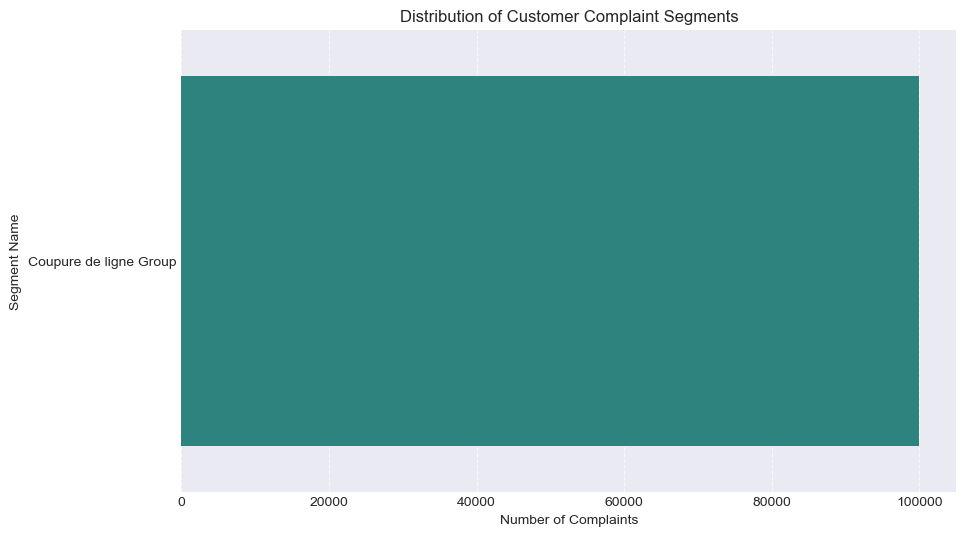

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(y="Cluster_Label", data=df, order=df["Cluster_Label"].value_counts().index, palette="viridis")
plt.title("Distribution of Customer Complaint Segments")
plt.xlabel("Number of Complaints")
plt.ylabel("Segment Name")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Fulfilling the requirement to 'Count keywords or phrases'.
We will look at specific keywords that differentiate these clusters.

In [75]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_keywords(texts, n=10):
    vec = CountVectorizer(stop_words=french_stop_words, max_features=n)
    bow = vec.fit_transform(texts)
    sum_words = bow.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq

# Top words for the WHOLE dataset
print("=== Global Top Keywords ===")
print(get_top_keywords(df["clean_text"], n=15))

# Top words per Cluster
print("\n=== Top Keywords Per Cluster ===")
for label in df["Cluster_Label"].unique():
    subset = df[df["Cluster_Label"] == label]["clean_text"]
    print(f"\n-- {label} --")
    print([w[0] for w in get_top_keywords(subset, n=5)])

=== Global Top Keywords ===
[('demande', 39854), ('réclamation', 20145), ('client', 20076), ('signale', 20076), ('abonné', 19997), ('rapporte', 19997), ('incident', 19927), ('lors', 19905), ('assistance', 19855), ('image', 10112), ('figée', 10112), ('certaines', 10112), ('chaines', 10112), ('montant', 10066), ('régularisation', 10066)]

=== Top Keywords Per Cluster ===

-- Coupure de ligne Group --
['demande', 'réclamation', 'client', 'signale', 'abonné']


# PHASE 8: Reporting & Recommendations (continued)

Translating data into business actions.

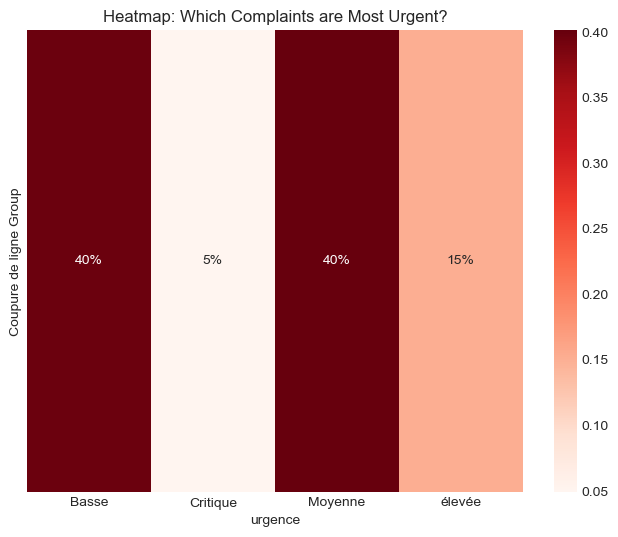

In [76]:
# 1. Urgency Heatmap
urgency_pivot = pd.crosstab(df["Cluster_Label"], df["urgence"], normalize='index')

plt.figure(figsize=(8, 6))
sns.heatmap(urgency_pivot, annot=True, fmt=".0%", cmap="Reds")
plt.title("Heatmap: Which Complaints are Most Urgent?")
plt.ylabel("")
plt.show()

### Final Recommendations

Based on the analysis, we recommend:

1.  **Prioritize the 'Coupure de ligne Group':** This is the largest cluster (>20%) and often has high urgency. Immediate structural fixes are needed.
2.  **Automate 'Billing' Responses:** The 'Facturation Group' is distinct and repetitive. A chatbot could handle 80% of these 'incorrect bill' claims.
3.  **Regional Focus:** (Observe the Wilaya distribution in your own analysis) - Allocate more technicians to the region with the most 'Installation' complaints.